# The 18 January 2026 eruption: from STIX QPPs to the severe SEP event

**Master analysis notebook** — M. Nedal (DIAS), with the OVSA/STIX/SEP collaboration.

On 18 January 2026, AR 4341 (β-γ, near central meridian) produced a long-duration X1.9 flare
(onset 17:27, peak 18:09, end 18:51 UT), a full-halo CME with projected speed above 2000 km/s,
and an S4 proton event — the largest >10 MeV enhancement since 2003, with no GLE.
STIX shows a train of quasi-periodic pulsations (QPPs) in the non-thermal hard X-ray bands.

**Science questions**

1. Nature of the flare energy release: QPP period(s) in STIX non-thermal X-rays, and whether
   the same rhythm appears in EOVSA microwaves, OVRO-LWA metric radio (type III groups), and
   the GOES SXR derivative.
2. Early CME acceleration and shock formation, and their relation to the high SEP flux and
   early arrival.
3. Shock geometry and magnetic connectivity as enablers of efficient particle acceleration
   and transport (Solar-MACH, PFSS, VDA/TSA release times vs the QPP interval).

**Workflow map** (sections):
§1 setup/config → §2 GOES overview → §3 STIX loading and cleaning → §4 QPP detrending and
pulse identification → §5 periodogram + wavelet + EMD with significance → §6 cross-instrument
rhythm (EOVSA, OVRO-LWA, GOES derivative) → §7 type IIIs vs HXR peaks, polarisation, LWA
imaging, automatic type III detection (§7.4) → §8 CME kinematics, type II tracing and shock
parameters (§8.1), STIX imaging on AIA/EUI (§8.2), the combined source overlay (§8.3) →
§9 connectivity (Solar-MACH, PFSS) → §10 SEP onsets, VDA/TSA → §11 synthesis timeline.

**Honesty caveats** (keep separate from results):
observation vs interpretation is flagged throughout; the flare-vs-shock split and any
QPP-to-escape link are hypotheses to test, not results. There is no European LOFAR coverage
(flare after local sunset over Europe); the low-frequency story rests on OVRO-LWA. Solar
Orbiter's vantage and connectivity are computed in §9 before any EPD claim is made.

> **v2 (20 July 2026):** revised copy implementing every fix and recommendation from `review_event_18Jan2026_20260720.md`. All outputs are cleared; rerun end-to-end and regenerate every file in `results/`.

## v2 changes (20 July 2026) — from `review_event_18Jan2026_20260720.md`

**Critical.** (1) STIX times are shifted to Earth-arrival at load in §3, $\Delta t = 499.005\,\mathrm{s\,au^{-1}}\times(d_\oplus - d_\mathrm{SolO}) \approx +119$ s, so the §6 lags, the §7.1 type III–HXR matching and the §11 ledger now compare like with like; §8.2 converts back to spacecraft time for archive queries. (2) The cross-correlation sign convention was inverted and is now fixed and verified on synthetic data: positive lag really means the channel lags STIX. (3) SEP onsets search only after flare onset, contaminated channels return NaT, a CUSUM cross-check column (Huttunen-Heikinmaa et al. 2005, Gaussian approximation) was added, and VDA fits are rejected unless $0.85 \le L \le 3.5$ au — the earlier $L = -12.2/-6.9$ au fits can no longer reach `summary_measurements.csv`. (4) The two-parameter arctan curve formerly labelled "Byrne (2013)" was removed everywhere; Byrne (2013) now means the Savitzky–Golay + residual-resampling bootstrap, which is what that paper actually describes.

**Moderate.** Gallagher (2003) $h(t)$ is now the exact double numerical integral of their $a(t)$ rather than the $h_0+v_0t+\tfrac12 a(t)t^2$ approximation; `ERRBAR_MODE='combined'` has a single definition (reps ⊕ fit ⊕ SG scatter) in §8.1 and §8.1a; STIX pulse Gaussians are bounded (amp > 0, $2 < \sigma < 60$ s) and carry a `fit_ok` flag; `resample_uniform` block-averages before gridding; Theil–Sen drift CIs are marked unconstrained when the slope CI crosses zero; the EUV-wave slits default to great-circle arcs on the solar sphere (`WAVE_GEOMETRY = 'great_circle'`, far-side points blanked), with the old projected slits still available as `'plane'`.

**Minor.** Headline Fourier periods exclude the 8–16 s near-Nyquist zone and the §5.3 table flags such rows; the density model is re-attributed to Saito, Poland & Munro (1977); both Gopalswamy & Yashiro (2011) $B(r)$ variants are plotted and labelled ($0.356\,r^{-1.28}$: $\gamma=5/3$+LDB; $0.377\,r^{-1.25}$: $\gamma=4/3$+SMP); the $\mu = 1.27$ vs $\mu = 1$ systematic is documented at the definition; `alfven_mach_from_X` states its assumptions (perpendicular shock, $\beta\to0$, $\gamma=5/3$, static upstream); a traced $f_H/f_F$ harmonic-ratio diagnostic was added to the type II scalars; §9 warns while the flare coordinates are still placeholders; the LWA centroid reader warns on rotated WCS; §8.2 carries a `no_shadowing` verification note.

**After rerunning**, regenerate in particular: `typeIII_hxr_matches.csv`, `cross_correlation_lags.csv`, `sep_onsets.csv`, `stix_pulse_fits_*.csv` and `summary_measurements.csv`.

**Added later on 20 July:** §6.1 pulsation epoch stack (`EPOCH_WINDOW`, `EPOCH_MODE`, `LWA_EPOCH_BANDS`) and the LWA dynamic spectrum over the same window.

## 1. Setup

Non-standard packages used here, install once on the analysis server:

```
pip install stixpy pycwt EMD-signal solo-epd-loader solarmach sunkit-magex cdflib xarray netCDF4 h5py
```

In [1]:
import numpy
import scipy
import astropy
import sunpy
import reproject
import sunpy.map

print('numpy:', numpy.__version__)
print('scipy:', scipy.__version__)
print('astropy:', astropy.__version__)
print('sunpy:', sunpy.__version__)

print('Everything OK')

numpy: 1.26.4
scipy: 1.15.2
astropy: 7.2.0
sunpy: 6.1.1
Everything OK


In [2]:
import warnings
warnings.filterwarnings('ignore')
import logging
import os
import glob
import json
import requests

import logging
import sunpy
import astropy

logging.getLogger('sunpy').setLevel(logging.WARNING)
logging.getLogger('astropy').setLevel(logging.WARNING)

import sunpy.map
import sunpy.timeseries as ts
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import get_horizons_coord

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.constants as const

from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.optimize import curve_fit, fsolve
from scipy.stats import chi2
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors
from tqdm import tqdm

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

In [3]:
# Event facts, cross-checked against IRAP / ESA / NOAA reports (see the abstract file).
# Everything downstream reads times from this dict only.
event = {
    'date': '2026-01-18',
    'ar': 'AR 4341',
    'flare_class': 'X1.9',
    'flare_onset': '2026-01-18T17:27:00',
    'flare_peak': '2026-01-18T18:09:00',
    'flare_end': '2026-01-18T18:51:00',
    'type_iv_onset': '2026-01-18T18:13:00',
    'rstn_28ghz_start': '2026-01-18T17:39:00',
    'rstn_28ghz_end': '2026-01-18T19:44:00',
    'sep_peak': '2026-01-19T19:15:00',      # >10 MeV S4 peak at GOES
    'l1_shock': '2026-01-19T19:03:00',
    'type_ii_drift_speed_reported': 693,    # km/s, from RSTN metric drift rate (report value)
    'cme_projected_speed_reported': 2000,   # km/s, lower bound, LASCO plane-of-sky
}

t_flare = {k: pd.Timestamp(v) for k, v in event.items() if str(v).startswith('2026')}

# Analysis windows. The QPP episode is 17:40-18:15 UT: every pulsation step (cleaning,
# detrending, wavelet, EMD Monte Carlo, cross-correlation) runs on that window plus a
# small pad so detrending edge effects fall outside the science interval — never on
# full-day arrays. Daily files are still downloaded once, then sliced immediately.
qpp_window = ('2026-01-18T17:40:00', '2026-01-18T18:15:00')
qpp_pad = pd.Timedelta(minutes=3)
qpp_padded = (pd.Timestamp(qpp_window[0]) - qpp_pad, pd.Timestamp(qpp_window[1]) + qpp_pad)
radio_bkg_window = ('2026-01-18T16:30:00', '2026-01-18T17:20:00')  # quiet pre-flare baseline
stix_window = ('2026-01-18T17:00:00', '2026-01-18T19:00:00')       # display context only
overview_window = ('2026-01-18T16:00:00', '2026-01-18T21:00:00')
sep_window = ('2026-01-18T12:00:00', '2026-01-21T00:00:00')

In [4]:
# data_dir = '/home/mnedal/data'
data_dir = './'
event_dir = f'{data_dir}/2026-01-18'
fig_dir = f'{event_dir}/figures'
res_dir = f'{event_dir}/results'

paths = {
    'stix': f'{event_dir}/STIX',
    'goes': f'{event_dir}/XRS',
    'aia': f'{event_dir}/AIA',
    'eovsa': f'{event_dir}/EOVSA',        # spectrogram FITS from Bin/Sijie (OVSA team)
    'lwa_dyspec': f'{event_dir}/LWA',      # OVRO-LWA beam dynamic spectrum from Peijin
    'lwa_imaging': f'{event_dir}/LWA/imaging',  # ~10 s cadence imaging FITS (Google Drive link from Peijin)
    'lwa_stokes': f'{event_dir}/LWA/stokes',    # polarimetric products for Shilpi's analysis
    'lasco': f'{event_dir}/LASCO',
    'sep': f'{event_dir}/SEP',
    'gong': f'{event_dir}/GONG',
}

for p in [event_dir, fig_dir, res_dir, *paths.values()]:
    os.makedirs(p, exist_ok=True)

# Central store for measured quantities; exported as CSV in §11
results = {}

In [5]:
def savefig(fig, name):
    """Publication-quality export (PDF + PNG)."""
    fig.savefig(f'{fig_dir}/{name}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/{name}.png', dpi=300, bbox_inches='tight')
    print(f'saved {fig_dir}/{name}.pdf|png')


def to_seconds(t_index, t0=None):
    """Datetime index -> elapsed seconds (float array)."""
    t = pd.DatetimeIndex(t_index)
    if t0 is None:
        t0 = t[0]
    return (t - t0).total_seconds().values, t0


def standardise(x):
    return (x - np.nanmean(x)) / np.nanstd(x)


def resample_uniform(t_index, y, dt_s):
    '''Put a (possibly irregular) series on a uniform grid of step dt_s seconds.
    v2: when the native cadence is finer than dt_s/1.5 the data are block-AVERAGED into
    dt_s bins first (point interpolation aliases fast structure, e.g. 0.5 s LWA onto a
    10 s grid), then gaps are interpolated; otherwise plain interpolation as before.'''
    s = pd.Series(y, index=pd.DatetimeIndex(t_index)).dropna()
    native = np.median(np.diff(s.index.values).astype('timedelta64[ms]').astype(float)) / 1000
    if native < dt_s / 1.5:
        sb = s.resample(f'{dt_s}s').mean()
        sb.index = sb.index + pd.Timedelta(seconds=dt_s / 2)
        sb = sb.interpolate(limit_direction='both')
        return sb.index, sb.values
    grid = pd.date_range(s.index[0], s.index[-1], freq=f'{dt_s}s')
    out = np.interp(mdates.date2num(grid), mdates.date2num(s.index), s.values)
    return grid, out


def qpp_residual(t_index, flux, window_s=120, polyorder=3, dt_s=None):
    """
    Detrend a light curve for QPP work: uniform resampling, then subtract a
    Savitzky-Golay trend. Returns (grid, flux_i, trend, residual, norm_residual).
    Window choice matters (Broomhall et al. 2019) -- see the robustness scan in §5.
    """
    if dt_s is None:
        dt_s = np.median(np.diff(pd.DatetimeIndex(t_index).values).astype('timedelta64[ms]').astype(float)) / 1000
    grid, flux_i = resample_uniform(t_index, flux, dt_s)
    win = int(round(window_s / dt_s))
    if win % 2 == 0:
        win += 1
    trend = savgol_filter(flux_i, win, polyorder)
    resid = flux_i - trend
    return grid, flux_i, trend, resid, resid / np.nanstd(resid)

## 2. GOES/XRS overview and the SXR derivative

The soft X-ray derivative is the cheapest proxy for the energy-release rhythm
(Neupert effect) and one of the channels in which we test for the QPP period.

In [6]:
def load_goes_xrs(t0, t1, sat=18):
    result = Fido.search(a.Time(t0, t1), a.Instrument('XRS'),
                         a.goes.SatelliteNumber(sat), a.Resolution('flx1s'))
    files = Fido.fetch(result, path=f"{paths['goes']}/{{file}}")
    goes = ts.TimeSeries(files, concatenate=True)
    return goes.truncate(t0, t1)


goes = load_goes_xrs(*overview_window)
gdf = goes.to_dataframe()
gdf = gdf[gdf['xrsb_quality'] == 0] if 'xrsb_quality' in gdf else gdf

# 1-min smoothing before differentiating, otherwise the derivative is noise-dominated
xrsb = gdf['xrsb'].resample('4s').mean().interpolate()
sxr_deriv = pd.Series(np.gradient(xrsb.values, 4), index=xrsb.index)
sxr_deriv_smooth = sxr_deriv.rolling(15, center=True).mean()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [132]:
gdf.head()

,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
2026-01-18 16:00:00.576432,1.191599e-07,0.000002,0,0,1,1
2026-01-18 16:00:01.576431,1.298585e-07,0.000002,0,0,1,1
2026-01-18 16:00:02.576433,1.358022e-07,0.000002,0,0,1,1
2026-01-18 16:00:03.576431,1.179712e-07,0.000002,0,0,1,1
2026-01-18 16:00:04.576434,1.250885e-07,0.000002,0,0,1,1


saved /home/mnedal/data/2026-01-18/figures/goes_overview.pdf|png


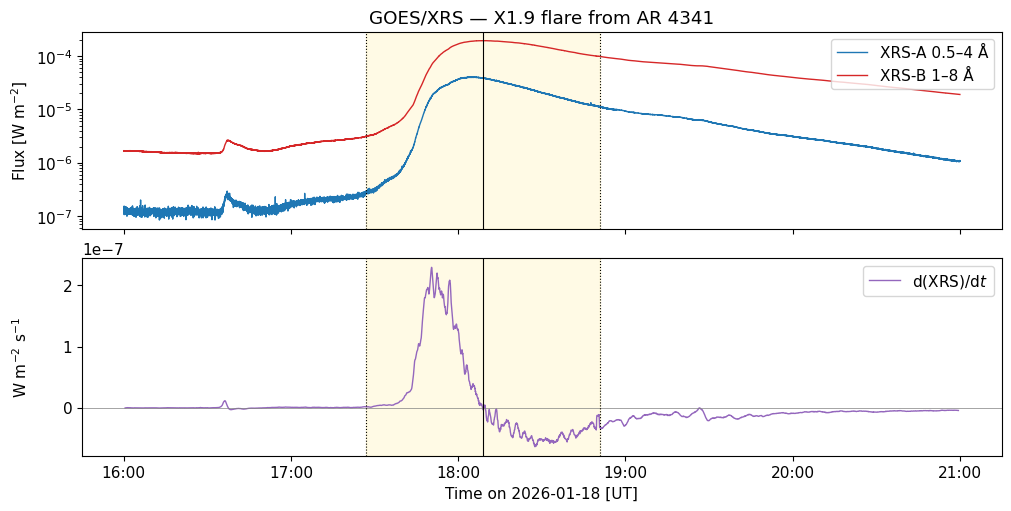

In [134]:
fig, axs = plt.subplots(2, 1, figsize=[10,5], sharex=True, constrained_layout=True)

axs[0].plot(gdf.index, gdf['xrsa'], lw=1, color='tab:blue', label='XRS-A 0.5–4 Å')
axs[0].plot(gdf.index, gdf['xrsb'], lw=1, color='tab:red', label='XRS-B 1–8 Å')
axs[0].set_yscale('log')
axs[0].set_ylabel('Flux [W m$^{-2}$]')
axs[0].legend(loc='upper right')

axs[1].plot(sxr_deriv_smooth.index, sxr_deriv_smooth, lw=1, color='tab:purple',
            label=r'd(XRS)/d$t$')
axs[1].axhline(0, color='grey', lw=0.5)
axs[1].set_ylabel(r'W m$^{-2}$ s$^{-1}$')
axs[1].legend(loc='upper right')

for ax in axs:
    for key, ls in zip(['flare_onset', 'flare_peak', 'flare_end'], [':', '-', ':']):
        ax.axvline(t_flare[key], color='k', ls=ls, lw=0.8)
    ax.axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.1)

axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel(f"Time on {event['date']} [UT]")
axs[0].set_title(f"GOES/XRS — {event['flare_class']} flare from {event['ar']}")
fig.align_ylabels(axs)
savefig(fig, 'goes_overview')
plt.show()

## 3. STIX: loading and cleaning the hard X-ray light curves

Two instrumental effects will contaminate any wavelet/Fourier/EMD analysis if ignored
(Shane's warning): (i) **attenuator movements** — the rate-control regime (RCR) inserts or
removes the Al attenuator during large flares, producing step artefacts; (ii) **variable
integration time** — QL light curves are not guaranteed to have a constant `timedel`.
The cleaning strategy: convert counts to rates with the *actual* per-bin `timedel`, flag RCR
changes, mask a guard interval around each change, then interpolate onto a uniform grid.
Periods comparable to, or shorter than, twice the longest integration time are not trustworthy.

Light-travel-time note: STIX times are corrected to Earth-received UT (or not) depending on
product/version — record which convention is used before comparing with GOES/EOVSA
(`date-obs` keywords; stixpy exposes the Earth arrival correction). Flag this in the timing table.

In [8]:
from stixpy.net.client import STIXClient  # noqa: F401  (registers the STIX Fido client)
from stixpy.product import Product

stix_query = Fido.search(a.Time(*overview_window), a.Instrument('STIX'),
                         a.stix.DataType('ql'), a.stix.DataProduct.ql_lightcurve)
stix_files = Fido.fetch(stix_query, path=f"{paths['stix']}/{{file}}")
print(stix_files)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['2026-01-18/STIX/solo_L1_stix-ql-lightcurve_20260118_V02.fits']


In [9]:
ql = Product(sorted(stix_files)[0])
print(ql)
print(ql.data.colnames)

# QL energy bands: 4-10, 10-15, 15-25, 25-50, 50-84 keV
stix_bands = ['4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV']

stix_time = pd.DatetimeIndex(ql.data['time'].datetime)
timedel = np.atleast_1d(ql.data['timedel'].to_value(u.s))
counts = np.asarray(ql.data['counts'])
rate = counts / timedel[:, None]

rcr = np.asarray(ql.data['rcr']) if 'rcr' in ql.data.colnames else np.zeros(len(stix_time))

# ---- v2 CRITICAL FIX: put STIX on Earth-arrival time ----
# STIX times are UTC at Solar Orbiter. SolO is closer to the Sun than Earth, so the same
# photons reach STIX earlier than Earth-based instruments (GOES, OVRO-LWA) by
# (d_Earth - d_SolO) x 499.005 s/au (~119 s for this event). Every timing comparison in
# this notebook (§6 lags, §7.1 matching, §11 ledger) is done in the Earth-arrival
# frame, so the STIX time axis is shifted once, here. §8.2 converts back to the
# spacecraft frame for archive queries.
from sunpy.coordinates import get_earth
_solo_pos = get_horizons_coord('Solar Orbiter', event['flare_peak'])
solo_r_au = float(_solo_pos.radius.to_value(u.au))
earth_r_au = float(get_earth(event['flare_peak']).radius.to_value(u.au))
LT_SHIFT_S = 499.005 * (earth_r_au - solo_r_au)
stix_time = stix_time + pd.Timedelta(seconds=LT_SHIFT_S)
results['stix_earth_arrival_shift_s'] = round(LT_SHIFT_S, 1)
print(f'STIX times shifted +{LT_SHIFT_S:.1f} s to Earth-arrival '
      f'(SolO at {solo_r_au:.3f} au, Earth at {earth_r_au:.3f} au)')

# QL files are daily — slice to the flare context window straight away so nothing
# downstream ever touches 24 h of data
keep = (stix_time >= pd.Timestamp(stix_window[0])) & (stix_time <= pd.Timestamp(stix_window[1]))
stix_time = stix_time[keep]
timedel = timedel[keep]
rate = rate[keep]
rcr = rcr[keep]

print(f'{keep.sum()} samples kept in {stix_window[0][11:16]}-{stix_window[1][11:16]} UT')
print(f'integration times present: {np.unique(timedel)} s')
print(f'RCR states present: {np.unique(rcr)}')

QLLightCurve
    Start: 2026-01-17 23:59:58
    End:   2026-01-18 23:59:58
    Center:2026-01-18 11:59:58
    Duration:0.9999976851851851 days or
           23.99994444444444 hours or
           1439.9966666666664 minutes or
           86399.79999999999 seconds

['control_index', 'time', 'timedel', 'triggers', 'triggers_comp_err', 'rcr', 'counts', 'counts_comp_err']
STIX times shifted +119.4 s to Earth-arrival (SolO at 0.745 au, Earth at 0.984 au)
1800 samples kept in 17:00-19:00 UT
integration times present: [4.] s
RCR states present: [0 1]


In [146]:
ql.time[:3]

<Time object: scale='utc' format='isot' value=['2026-01-18T00:00:00.513' '2026-01-18T00:00:04.513'
 '2026-01-18T00:00:08.513']>

In [10]:
def clean_stix_band(t_index, rate_band, rcr, timedel, dt_s=4, guard_s=20):
    """
    Mask a guard interval around every RCR (attenuator) change, then interpolate
    the rate onto a uniform dt_s grid. Returns (grid, rate_i, mask_uniform).
    The mask is carried forward so masked stretches can be shaded in plots and
    excluded from significance statistics.
    """
    t = pd.DatetimeIndex(t_index)
    changes = np.where(np.diff(rcr) != 0)[0]
    bad = np.zeros(len(t), dtype=bool)
    for i in changes:
        t_ch = t[i]
        bad |= (t >= t_ch - pd.Timedelta(seconds=guard_s)) & (t <= t_ch + pd.Timedelta(seconds=guard_s))
    # also distrust bins with unusually long integration (rate ok, but frequency response differs)
    bad |= timedel > 2 * np.median(timedel)

    s = pd.Series(np.where(bad, np.nan, rate_band), index=t)
    grid = pd.date_range(t[0], t[-1], freq=f'{dt_s}s')
    rate_i = pd.Series(np.interp(mdates.date2num(grid), mdates.date2num(t[~bad]), s.dropna().values), index=grid)
    mask_u = pd.Series(bad.astype(float), index=t).reindex(grid, method='nearest').astype(bool)
    return grid, rate_i.values, mask_u.values


stix = {}
for j, band in enumerate(stix_bands):
    grid, r_i, m_u = clean_stix_band(stix_time, rate[:, j], rcr, timedel)
    stix[band] = {'t': grid, 'rate': r_i, 'mask': m_u}

saved .//2026-01-18/figures/stix_lightcurves_clean.pdf|png


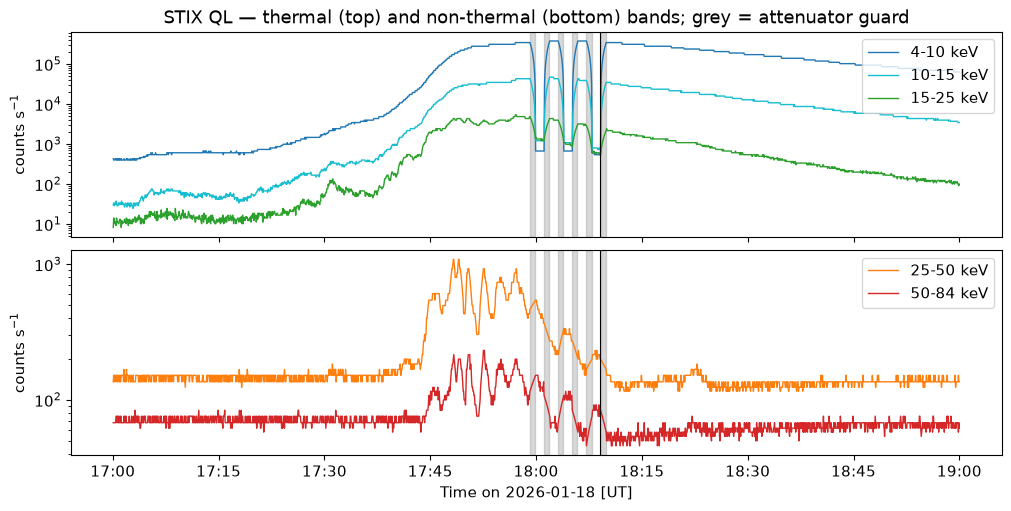

In [11]:
fig, axs = plt.subplots(2, 1, figsize=[10,5], sharex=True, constrained_layout=True)

for band, color in zip(stix_bands[:3], ['tab:blue', 'tab:cyan', 'tab:green']):
    axs[0].plot(stix[band]['t'], stix[band]['rate'], lw=1, color=color, label=band)
for band, color in zip(stix_bands[3:], ['tab:orange', 'tab:red']):
    axs[1].plot(stix[band]['t'], stix[band]['rate'], lw=1, color=color, label=band)

# shade attenuator-guard intervals so no one over-reads features there
m = stix[stix_bands[0]]['mask']
t_g = stix[stix_bands[0]]['t']
for seg_start, seg_end in zip(t_g[np.flatnonzero(np.diff(m.astype(int)) == 1)],
                              t_g[np.flatnonzero(np.diff(m.astype(int)) == -1)]):
    for ax in axs:
        ax.axvspan(seg_start, seg_end, color='grey', alpha=0.3)

for ax in axs:
    ax.set_yscale('log')
    ax.set_ylabel('counts s$^{-1}$')
    ax.legend(loc='upper right')
    ax.axvline(t_flare['flare_peak'], color='k', lw=0.8)

axs[0].set_title('STIX QL — thermal (top) and non-thermal (bottom) bands; grey = attenuator guard')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel(f"Time on {event['date']} [UT]")
savefig(fig, 'stix_lightcurves_clean')
plt.show()

## 4. QPP extraction: detrending and pulse identification

Working series: the two non-thermal bands (25–50, 50–84 keV), restricted to the impulsive
phase. Detrending uses the Savitzky-Golay residual (as in `qpp_residuals.ipynb`); the
window is a free parameter and §5 scans it, because apparent periods can be created or
destroyed by the trend choice (Broomhall et al. 2019).

In [158]:
# band_nt = '25-50 keV'
band_nt = '50-84 keV'

# detrend over the padded window, then crop to the science window so the
# Savitzky-Golay edge effects never enter the analysis
sel = (stix[band_nt]['t'] >= qpp_padded[0]) & (stix[band_nt]['t'] <= qpp_padded[1])
t_nt = stix[band_nt]['t'][sel]
r_nt = stix[band_nt]['rate'][sel]
mask_nt = stix[band_nt]['mask'][sel]

grid_p, flux_p, trend_p, resid_p, _ = qpp_residual(t_nt, r_nt, window_s=120, polyorder=3, dt_s=4)
core = (grid_p >= pd.Timestamp(qpp_window[0])) & (grid_p <= pd.Timestamp(qpp_window[1]))
grid_nt = grid_p[core]
flux_i = flux_p[core]
trend = trend_p[core]
resid = resid_p[core]
resid_n = resid / np.nanstd(resid)

In [159]:
# Pulse identification on the normalised residual
peaks, props = find_peaks(resid_n, prominence=1, distance=int(np.ceil(10 / 4)))  # >= 10 s apart
pulse_times = grid_nt[peaks]
waiting_times = np.diff(pulse_times).astype('timedelta64[s]').astype(float)

print(f'{len(peaks)} pulses; median waiting time {np.median(waiting_times):.1f} s')
results['n_pulses_25_50'] = len(peaks)
results['median_waiting_time_s'] = float(np.median(waiting_times))

46 pulses; median waiting time 32.0 s


In [160]:
def gaussian(x, amp, mu, sig):
    return amp * np.exp(-(x - mu)**2 / (2 * sig**2))


tsec, t0_nt = to_seconds(grid_nt)
pulse_fits = []
half = int(round(0.6 * np.median(waiting_times) / 4))
for pk in tqdm(peaks, desc='Fitting pulses'):
    lo = max(pk - half, 0)
    hi = min(pk + half, len(tsec) - 1)
    # v2: bounded fit (amp > 0, peak inside the window, 2 s < sigma < 60 s) so the table
    # can no longer hold unphysical negative-amplitude solutions; fit_ok flags rows where
    # the fit is trustworthy (finite errors, peak-time uncertainty < 30 s)
    p0 = [max(resid[pk], 1e-3), tsec[pk], 20]
    bounds = ([0, tsec[lo], 2], [np.inf, tsec[hi], 60])
    try:
        popt, pcov = curve_fit(gaussian, tsec[lo:hi], resid[lo:hi], p0=p0, bounds=bounds,
                               maxfev=20000)
        perr = np.sqrt(np.diag(pcov))
        fit_ok = bool(np.all(np.isfinite(perr)) and perr[1] < 30)
        pulse_fits.append({'t_peak': t0_nt + pd.Timedelta(seconds=popt[1]),
                           'amp': popt[0], 'fwhm_s': 2.355 * abs(popt[2]),
                           'amp_err': perr[0], 'fwhm_err_s': 2.355 * perr[2],
                           'fit_ok': fit_ok})
    except (RuntimeError, ValueError):
        pulse_fits.append({'t_peak': grid_nt[pk], 'amp': resid[pk], 'fwhm_s': np.nan,
                           'amp_err': np.nan, 'fwhm_err_s': np.nan, 'fit_ok': False})

pulse_df = pd.DataFrame(pulse_fits)
n_bad = int((~pulse_df['fit_ok']).sum())
if n_bad:
    print(f'{n_bad} pulse(s) kept with the sample peak instead of an unreliable fit')
pulse_df.to_csv(f'{res_dir}/stix_pulse_fits_{band_nt.replace(" ", "")}.csv', index=False)
pulse_df

Fitting pulses: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 73.35it/s]

7 pulse(s) kept with the sample peak instead of an unreliable fit


,t_peak,amp,fwhm_s,amp_err,fwhm_err_s,fit_ok
0,2026-01-18 17:41:33.814407382,1.402419e+01,4.710000,6.020035e+01,2.008761e+01,True
1,2026-01-18 17:41:33.768226818,1.391130e+01,4.710000,4.154279e+01,1.388422e+01,True
2,2026-01-18 17:43:07.805613581,4.504362e+00,4.710000,5.748369e+00,2.239775e+03,False
3,2026-01-18 17:44:00.234351191,6.246483e+00,9.549129,4.966545e+00,8.741363e+00,True
4,2026-01-18 17:45:02.583039754,1.387908e+01,4.710000,2.224680e+02,8.885237e+01,True
5,2026-01-18 17:44:47.385397454,1.166801e+01,4.710000,9.698451e+00,5.253424e+00,True
6,2026-01-18 17:45:23.567945512,6.921394e+00,10.828033,6.808974e+00,1.229572e+01,True
7,2026-01-18 17:46:10.082595938,7.460744e+00,22.985718,5.063762e+00,2.367615e+01,True
8,2026-01-18 17:46:05.870431107,7.842978e+00,16.932866,7.614058e+00,2.084653e+01,True
9,2026-01-18 17:47:03.385020694,8.985437e+00,16.587701,2.740817e+00,5.865429e+00,True


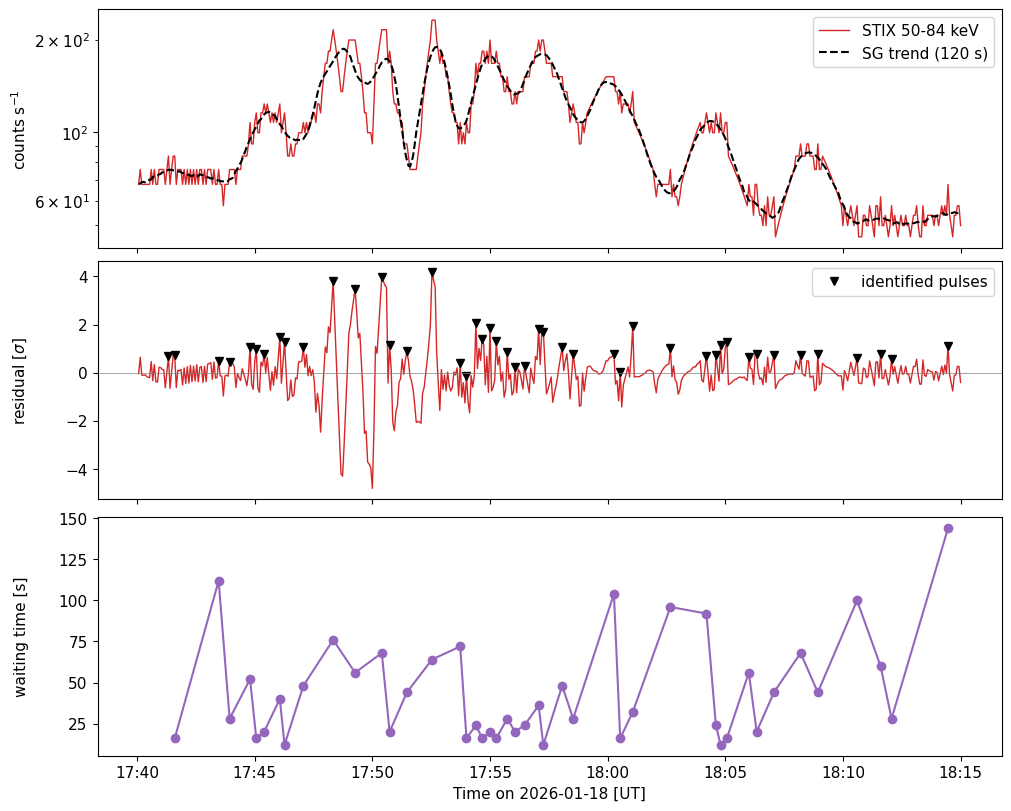

In [161]:
fig, axs = plt.subplots(3, 1, figsize=[10,8], sharex=True, constrained_layout=True)

axs[0].plot(grid_nt, flux_i, lw=1, color='tab:red', label=f'STIX {band_nt}')
axs[0].plot(grid_nt, trend, lw=1.5, color='k', ls='--', label='SG trend (120 s)')
axs[0].set_yscale('log')
axs[0].set_ylabel('counts s$^{-1}$')

axs[1].plot(grid_nt, resid_n, lw=1, color='tab:red')
axs[1].plot(grid_nt[peaks], resid_n[peaks], 'kv', ms=6, label='identified pulses')
axs[1].axhline(0, color='grey', lw=0.5)
axs[1].set_ylabel(r'residual [$\sigma$]')

axs[2].plot(pulse_times[1:], waiting_times, 'o-', color='tab:purple')
axs[2].set_ylabel('waiting time [s]')
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].set_xlabel(f"Time on {event['date']} [UT]")

for ax in axs[:2]:
    ax.legend(loc='upper right')
fig.align_ylabels(axs)
# savefig(fig, f'stix_qpp_pulses_{band_nt.replace(" ", "")}')
plt.show()

### 4.1 Per-pulse spectral evolution (hardening/softening)

STIX measures X-rays, not electrons: the pulse-by-pulse quantity tracked here is the
**hard X-ray count-spectrum slope** between the non-thermal QL bands; the electron spectrum
is a derived quantity and the full thermal + thick-target forward fit belongs in
OSPEX/STIX-GSW (or stixpy spectroscopy) using the L1 `sci-xspec` product:
`Fido.search(..., a.stix.DataProduct.sci_xray_spec)`.
The band-ratio proxy below is cadence-friendly and fine for *relative* pulse-to-pulse
hardness, not for absolute spectral indices.

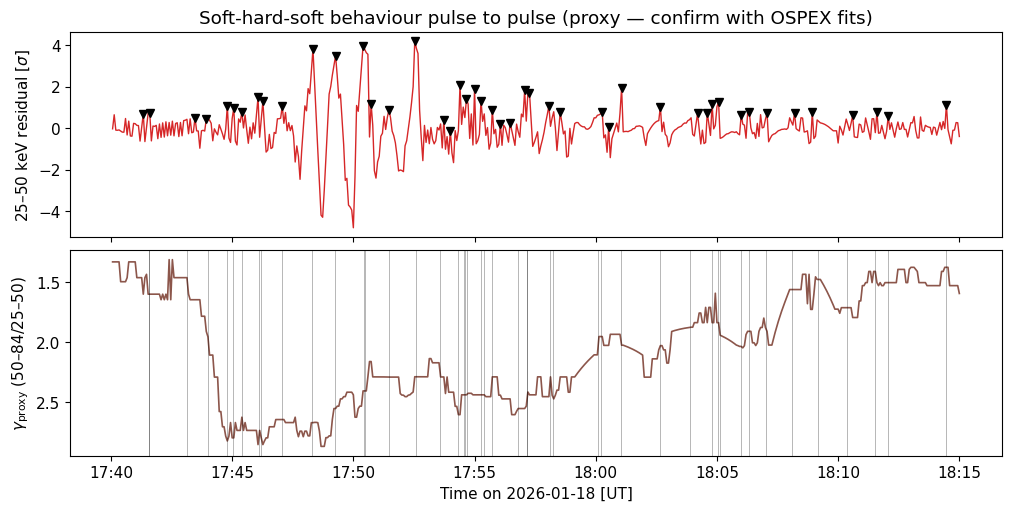

In [162]:
s25 = pd.Series(stix['25-50 keV']['rate'], index=stix['25-50 keV']['t'])
s50 = pd.Series(stix['50-84 keV']['rate'], index=stix['50-84 keV']['t'])

# effective count-spectrum slope between geometric-mean energies 35.4 and 64.8 keV
e1 = np.sqrt(25 * 50)
e2 = np.sqrt(50 * 84)
with np.errstate(divide='ignore', invalid='ignore'):
    gamma_proxy = -np.log(s50 / s25) / np.log(e2 / e1)

# align on the cropped QPP grid
gamma_s = gamma_proxy.rolling(5, center=True).median().reindex(grid_nt, method='nearest')

fig, axs = plt.subplots(2, 1, figsize=[10,5], sharex=True, constrained_layout=True)
axs[0].plot(grid_nt, resid_n, lw=1, color='tab:red')
axs[0].plot(grid_nt[peaks], resid_n[peaks], 'kv', ms=6)
axs[0].set_ylabel(r'25–50 keV residual [$\sigma$]')

axs[1].plot(gamma_s.index, gamma_s, lw=1.2, color='tab:brown')
for tp in pulse_df['t_peak']:
    axs[1].axvline(tp, color='k', lw=0.5, alpha=0.4)
axs[1].invert_yaxis()  # up = harder
axs[1].set_ylabel(r'$\gamma_{\rm proxy}$ (50–84/25–50)')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel(f"Time on {event['date']} [UT]")
axs[0].set_title('Soft-hard-soft behaviour pulse to pulse (proxy — confirm with OSPEX fits)')
# savefig(fig, 'stix_perpulse_hardness_proxy')
plt.show()

## 5. Period analysis with significance testing

Three independent methods on the same residual, each with a noise model, following the
recommendations of Broomhall et al. (2019, ApJS 244, 44) — Laura's reference:

1. **Fourier periodogram** against a fitted broken/power-law red-noise background with
   $\chi^2_2$ confidence levels and a trial-number (global) correction (Vaughan 2005;
   Pugh et al. 2017). Applied to the *undetrended* series as well, since detrending
   distorts the low-frequency part of the spectrum.
2. **Morlet wavelet** with an AR(1) red-noise significance test and the cone of
   influence (Torrence & Compo 1998), via `pycwt`.
3. **EMD** (as in the preliminary analysis) with a Monte-Carlo significance envelope:
   coloured-noise realisations matched to the fitted spectral slope are decomposed and
   the IMF energy-period distribution of the noise bounds the observed IMFs
   (in the spirit of Kolotkov et al. 2016).

A detection is only claimed when the period is consistent across methods, stable against
the detrend window, and away from masked attenuator intervals.

In [163]:
def periodogram(x, dt):
    n = len(x)
    freqs = np.fft.rfftfreq(n, dt)[1:]
    power = (np.abs(np.fft.rfft(x - np.mean(x)))**2)[1:] * 2 * dt / n
    return freqs, power


def powerlaw_model(f, logA, alpha, logC):
    return 10**logA * f**(-alpha) + 10**logC


def fit_rednoise(freqs, power):
    """Fit P(f) = A f^-alpha + C in log space (Vaughan 2005 least-squares variant)."""
    def logmodel(logf, logA, alpha, logC):
        return np.log10(powerlaw_model(10**logf, logA, alpha, logC))
    p0 = [np.log10(power[0]), 1.5, np.log10(np.median(power[-len(power) // 5:]))]
    popt, pcov = curve_fit(logmodel, np.log10(freqs), np.log10(power), p0=p0, maxfev=20000)
    return popt, np.sqrt(np.diag(pcov))


def confidence_levels(freqs, popt, n_freq, levels=(0.95, 0.99)):
    """
    Local and global (trial-corrected) confidence levels.
    Periodogram/model ~ chi2_2/2, so P_conf = model * chi2.ppf(p, 2)/2.
    Global: p_global = (1 - eps)^(1/n_freq) for a family-wise rate eps.
    """
    model = powerlaw_model(freqs, *popt)
    out = {}
    for lv in levels:
        out[f'local_{lv}'] = model * chi2.ppf(lv, 2) / 2
        lv_g = (1 - (1 - lv))**(1 / n_freq)
        out[f'global_{lv}'] = model * chi2.ppf(lv_g, 2) / 2
    return model, out


dt_s = 4
freqs, power = periodogram(resid, dt_s)
freqs_raw, power_raw = periodogram(flux_i, dt_s)

popt, perr = fit_rednoise(freqs_raw, power_raw)
model, confs = confidence_levels(freqs_raw, popt, len(freqs_raw))
print(f'red-noise slope alpha = {popt[1]:.2f} +/- {perr[1]:.2f}')
results['rednoise_alpha'] = round(float(popt[1]), 2)

red-noise slope alpha = 1.62 +/- inf


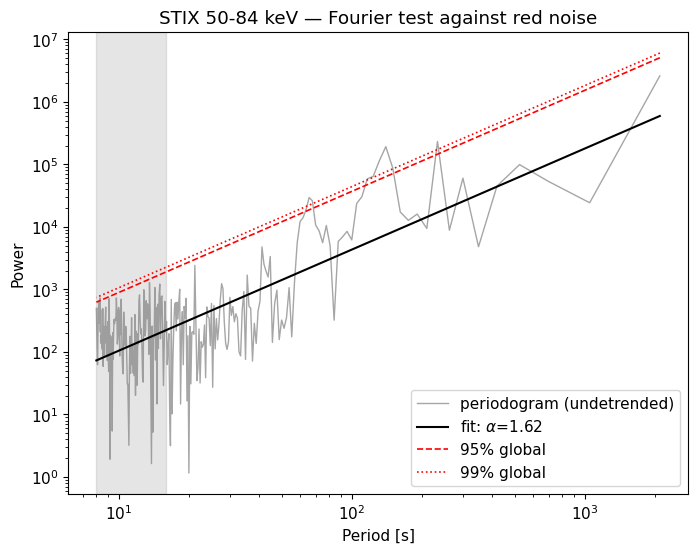

periods above 95% global: [233.3 150.  140.  131.2 123.5 116.7  67.7  65.6  63.6   8.3] s


In [164]:
fig, ax = plt.subplots(figsize=[8,6])
ax.loglog(1 / freqs_raw, power_raw, lw=1, color='grey', alpha=0.7, label='periodogram (undetrended)')
ax.loglog(1 / freqs_raw, model, 'k-', lw=1.5, label=fr'fit: $\alpha$={popt[1]:.2f}')
ax.loglog(1 / freqs_raw, confs['global_0.95'], 'r--', lw=1.2, label='95% global')
ax.loglog(1 / freqs_raw, confs['global_0.99'], 'r:', lw=1.2, label='99% global')
ax.axvspan(2 * dt_s, 4 * dt_s, color='grey', alpha=0.2)  # near-Nyquist, do not interpret
ax.set_xlabel('Period [s]')
ax.set_ylabel('Power')
ax.set_title(f'STIX {band_nt} — Fourier test against red noise')
ax.legend()
# savefig(fig, 'stix_periodogram_rednoise')
plt.show()

above = power_raw > confs['global_0.95']
if above.any():
    print('periods above 95% global:', np.round(1 / freqs_raw[above], 1), 's')
    # v2: the headline list excludes the 2-4 x Nyquist caution zone shaded in the figure
    keep_per = above & (1 / freqs_raw > 4 * dt_s)
    results['fourier_periods_s'] = list(np.round(1 / freqs_raw[keep_per], 1))

### 5.1 Wavelet (Morlet), red-noise significance, COI

In [165]:
import pycwt

sig = standardise(resid)
mother = pycwt.Morlet(6)
alpha_ar1, _, _ = pycwt.ar1(sig)

wave, scales, wfreqs, coi, fft_w, fftfreqs = pycwt.cwt(sig, dt_s, dj=1 / 12, s0=2 * dt_s,
                                                       J=int(7 / (1 / 12)), wavelet=mother)
wpower = np.abs(wave)**2
periods = 1 / wfreqs

signif, fft_theor = pycwt.significance(1, dt_s, scales, 0, alpha_ar1,
                                       significance_level=0.95, wavelet=mother)
sig95 = wpower / (signif[:, None])

glbl_power = wpower.mean(axis=1)
dof = sig.size - scales
glbl_signif, _ = pycwt.significance(1, dt_s, scales, 1, alpha_ar1,
                                    significance_level=0.95, dof=dof, wavelet=mother)

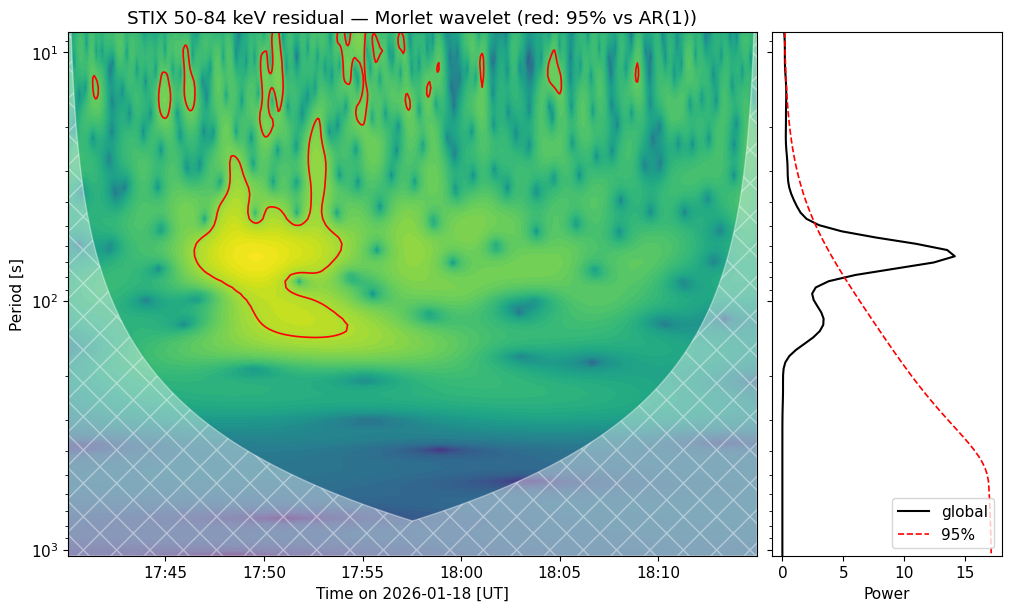

In [166]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10,6], width_ratios=[3, 1], sharey=True, constrained_layout=True)

tnum = mdates.date2num(grid_nt)
cf = ax1.contourf(tnum, periods, np.log2(wpower), levels=64, cmap='viridis')
ax1.contour(tnum, periods, sig95, [1], colors='r', linewidths=1.2)
ax1.fill_between(tnum, coi, periods.max(), color='w', alpha=0.4, hatch='x')
ax1.set_yscale('log')
ax1.set_ylim(periods.max(), periods.min())
ax1.set_ylabel('Period [s]')
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.set_xlabel(f"Time on {event['date']} [UT]")
ax1.set_title(f'STIX {band_nt} residual — Morlet wavelet (red: 95% vs AR(1))')

ax2.plot(glbl_power, periods, 'k-', lw=1.5, label='global')
ax2.plot(glbl_signif, periods, 'r--', lw=1.2, label='95%')
ax2.set_xlabel('Power')
ax2.legend(loc='lower right')
# savefig(fig, 'stix_wavelet')
plt.show()

In [168]:
glbl_above = glbl_power > glbl_signif
if glbl_above.any():
    p_dom = periods[glbl_above][np.argmax(glbl_power[glbl_above])]
    print(f'dominant significant wavelet period: {p_dom:.1f} s')
    results['wavelet_period_s'] = round(float(p_dom), 1)

dominant significant wavelet period: 66.1 s


### 5.2 EMD with a Monte-Carlo coloured-noise envelope

Each IMF gets a characteristic period from its zero-crossing count. Significance: decompose
`n_mc` synthetic coloured-noise series (spectral slope $\alpha$ from §5, same variance and
length), and take the 95th percentile of noise-IMF energy as a function of period.

In [21]:
from PyEMD import EMD


def imf_period(imf, dt):
    zc = np.sum(np.abs(np.diff(np.sign(imf))) > 0)
    return 2 * len(imf) * dt / zc if zc > 0 else np.inf


def coloured_noise(n, alpha, rng):
    """FFT-method noise with P(f) ~ f^-alpha, unit variance."""
    f = np.fft.rfftfreq(n, 1)
    amp = np.zeros_like(f)
    amp[1:] = f[1:]**(-alpha / 2)
    phase = rng.uniform(0, 2 * np.pi, len(f))
    spec = amp * np.exp(1j * phase)
    x = np.fft.irfft(spec, n)
    return (x - x.mean()) / x.std()


emd = EMD()
imfs = emd(sig)
imf_periods = np.array([imf_period(imf, dt_s) for imf in imfs])
imf_energies = np.array([np.sum(imf**2) for imf in imfs])
print('IMF periods [s]:', np.round(imf_periods, 1))

n_mc = 200
rng = np.random.default_rng(7)
mc_p = []
mc_e = []
for _ in tqdm(range(n_mc), desc='EMD Monte Carlo'):
    xn = coloured_noise(len(sig), popt[1], rng)
    imfs_n = emd(xn)
    for imf in imfs_n:
        mc_p.append(imf_period(imf, dt_s))
        mc_e.append(np.sum(imf**2))

mc_p = np.array(mc_p)
mc_e = np.array(mc_e)

pbins = np.logspace(np.log10(2 * dt_s), np.log10(len(sig) * dt_s / 2), 12)
env95 = np.array([np.percentile(mc_e[(mc_p >= lo) & (mc_p < hi)], 95)
                  if ((mc_p >= lo) & (mc_p < hi)).sum() > 10 else np.nan
                  for lo, hi in zip(pbins[:-1], pbins[1:])])
pcent = np.sqrt(pbins[:-1] * pbins[1:])

IMF periods [s]: [  14.9   35.9   75.   150.   323.1 1050.  2100. ]


EMD Monte Carlo: 100%|██████████| 200/200 [00:01<00:00, 166.18it/s]


saved .//2026-01-18/figures/stix_emd_significance.pdf|png


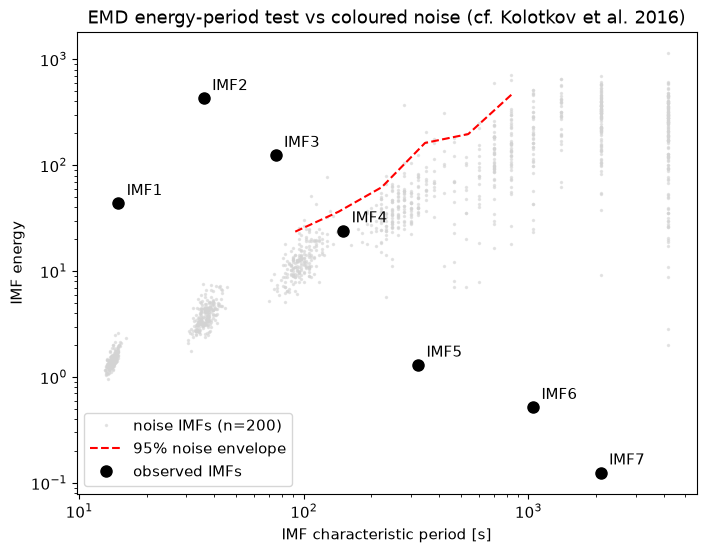

In [22]:
fig, ax = plt.subplots(figsize=[8,6])
ax.loglog(mc_p, mc_e, '.', color='lightgrey', ms=3, alpha=0.5, label=f'noise IMFs (n={n_mc})')
ax.loglog(pcent, env95, 'r--', lw=1.5, label='95% noise envelope')
ax.loglog(imf_periods, imf_energies, 'ko', ms=8, label='observed IMFs')
for p_i, e_i, k in zip(imf_periods, imf_energies, range(len(imfs))):
    ax.annotate(f'IMF{k + 1}', (p_i, e_i), textcoords='offset points', xytext=[6, 6])
ax.set_xlabel('IMF characteristic period [s]')
ax.set_ylabel('IMF energy')
ax.set_title('EMD energy-period test vs coloured noise (cf. Kolotkov et al. 2016)')
ax.legend()
savefig(fig, 'stix_emd_significance')
plt.show()

### 5.3 Robustness of the period against the detrend window

The headline period must not be an artefact of one smoothing choice.

In [23]:
windows = [60, 90, 120, 180, 240]
rows = []
for w in tqdm(windows, desc='Detrend-window scan'):
    _, _, _, res_w, _ = qpp_residual(t_nt, r_nt, window_s=w, polyorder=3, dt_s=4)
    f_w, p_w = periodogram(res_w, 4)
    popt_w, _ = fit_rednoise(freqs_raw, power_raw)
    _, confs_w = confidence_levels(f_w, popt_w, len(f_w))
    ok = p_w > confs_w['global_0.95']
    dom = 1 / f_w[ok][np.argmax(p_w[ok])] if ok.any() else np.nan
    rows.append({'window_s': w, 'dominant_period_s': round(float(dom), 1) if np.isfinite(dom) else np.nan,
                 'n_sig_peaks': int(ok.sum()),
                 'near_nyquist': bool(np.isfinite(dom) and dom < 4 * 4)})   # v2: <16 s = caution zone

robust_df = pd.DataFrame(rows)
robust_df.to_csv(f'{res_dir}/qpp_window_robustness.csv', index=False)
robust_df

Detrend-window scan: 100%|██████████| 5/5 [00:00<00:00, 966.38it/s]


,window_s,dominant_period_s,n_sig_peaks,near_nyquist
0,60,8.6,1,True
1,90,8.6,1,True
2,120,66.5,7,False
3,180,66.5,5,False
4,240,136.7,7,False


Repeat §4-§5 for the 50–84 keV band (and 15–25 keV for the thermal response) by changing
`band_nt` above and re-running — the STIX QPP result is the pair (period, band dependence).

## 6. One rhythm, many messengers: EOVSA, OVRO-LWA, GOES derivative

EOVSA peaked near 1000 sfu with multiple pulsation signatures (Bin); OVRO-LWA provides the
metric dynamic spectrum and ~10 s imaging (Peijin). Cadences differ (EOVSA ~1 s, STIX 4 s,
LWA 10 s), so everything is compared on a common 10 s grid — the LWA cadence is the binding
constraint (Shilpi's caution), and no cross-instrument claim is made below ~20 s periods.

File formats below follow the shared products; run the `inspect_*` helpers first and adjust
the reader once the Google Drive files are in place.

**Timing frames (v2):** STIX times are shifted to Earth-arrival at load (§3, ~+119 s for this event), so the lags and matches measured in §6–§7 are physical rather than orbital geometry.

In [169]:
def inspect_fits(path):
    with fits.open(path) as hdul:
        hdul.info()
        for i, hdu in enumerate(hdul):
            print(f'--- HDU {i} header keys ---')
            print(repr(hdu.header)[:2000])


def load_eovsa_spectrogram(path):
    """
    EOVSA total-power dynamic spectrum FITS, layout per
    Tutorial_2_EOVSA_data_Basics_2_Reading_and_plotting_EOVSA_FITS_data.ipynb:
      HDU0 primary : (nfreq, ntime) flux density in SFU
      HDU1 bintable: column FGHZ, frequency axis [GHz]
      HDU2 bintable: column TIME, time axis as Julian date
    (verified against eovsa.spec_tp.flare_id_202601181750.fits: 451 freq x 2399 time).
    """
    with fits.open(path) as hdul:
        spec = np.asarray(hdul[0].data, dtype=float)             # (nfreq, ntime), SFU
        fghz = np.asarray(hdul[1].data['fghz'], dtype=float).ravel()   # column names are
        tjd = np.asarray(hdul[2].data['time'], dtype=float).ravel()    # case-insensitive
    t_index = pd.DatetimeIndex(Time(tjd, format='jd').datetime)
    return t_index, fghz, spec


def bkg_window_for(t_index, preferred):
    """
    Background window that is actually covered by `t_index`. The flare-mode EOVSA record
    starts near the flare, so the global pre-flare `radio_bkg_window` can fall entirely
    outside it; in that case fall back to the first BKG_FALLBACK_FRAC of the record, which
    is the quietest part available. Returns (start, end) timestamps.
    """
    BKG_FALLBACK_FRAC = 0.05      # 5% of the record: long enough to average down noise,
                                  # short enough to stay before the impulsive rise
    t0, t1 = pd.Timestamp(preferred[0]), pd.Timestamp(preferred[1])
    if ((t_index >= t0) & (t_index <= t1)).sum() >= 10:   # >=10 samples -> usable median
        return preferred
    span = t_index[-1] - t_index[0]
    fallback = (t_index[0], t_index[0] + span * BKG_FALLBACK_FRAC)
    print(f'  preferred background window not covered; using '
          f'{fallback[0]:%H:%M:%S}-{fallback[1]:%H:%M:%S} UT instead')
    return fallback


# The OVSA filename carries the flare id, so glob rather than hard-code it.
eovsa_cands = sorted(glob.glob(f"{paths['eovsa']}/eovsa*spec*.fits"))
eovsa_file = eovsa_cands[0] if eovsa_cands else None
have_eovsa = eovsa_file is not None
if have_eovsa:
    eov_t, eov_f, eov_s = load_eovsa_spectrogram(eovsa_file)
    eovsa_bkg_window = bkg_window_for(eov_t, radio_bkg_window)
    print(f'EOVSA: {os.path.basename(eovsa_file)}')
    print(f'  {len(eov_f)} channels {eov_f[0]:.2f}-{eov_f[-1]:.2f} GHz, '
          f'{len(eov_t)} samples {eov_t[0]:%H:%M:%S}-{eov_t[-1]:%H:%M:%S} UT')
else:
    eovsa_bkg_window = radio_bkg_window
    print('EOVSA spectrogram not on disk yet — section will skip until the file arrives')

  preferred background window not covered; using 17:39:27-17:41:26 UT instead
EOVSA: eovsa.spec_tp.flare_id_202601181750.fits
  451 channels 1.11-17.98 GHz, 2399 samples 17:39:27-18:19:25 UT


In [170]:
def load_lwa_dyspec(path):
    """
    OVRO-LWA dynamic-spectrum FITS (Peijin's format):
    primary data (npol, 1, nfreq, ntime), 'SFREQ' HDU in GHz, 'UT' HDU with
    integer MJD plus milliseconds of day.
    Returns (time index, frequency [MHz], cube (npol, nfreq, ntime)).
    """
    with fits.open(path) as hdul:
        cube = hdul[0].data[:, 0, :, :]
        fmhz = hdul['SFREQ'].data['SFREQ'] * 1e3
        ut = hdul['UT'].data
        time_mjd = ut['mjd'] + ut['time'] / 86400000
    t_index = pd.DatetimeIndex(Time(time_mjd, format='mjd').to_datetime())
    return t_index, np.asarray(fmhz), np.asarray(cube)


lwa_file = f"{paths['lwa_dyspec']}/20260118.fits"
have_lwa = os.path.exists(lwa_file)
if have_lwa:
    lwa_t, lwa_f, lwa_cube = load_lwa_dyspec(lwa_file)
    print(f'{lwa_cube.shape[0]} polarisation planes, {len(lwa_f)} channels, {len(lwa_t)} time steps, '
          f'{lwa_f[0]:.1f}-{lwa_f[-1]:.1f} MHz')
    lwa_s = lwa_cube[0]  # first pol plane; confirm the plane ordering with Peijin
else:
    print('OVRO-LWA dynamic spectrum not on disk yet — section will skip until the file arrives')

2 polarisation planes, 731 channels, 53385 time steps, 15.0-84.9 MHz


saved /home/mnedal/data/2026-01-18/figures/lwa_dynspec_bkg_divide.pdf|png


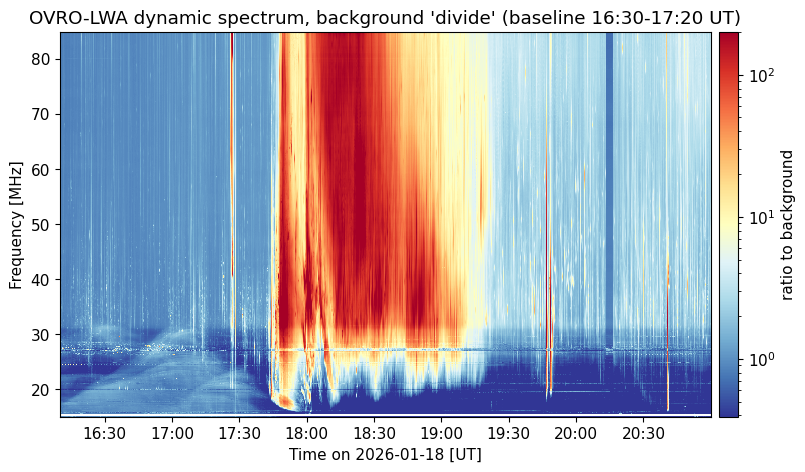

In [171]:
# ---- §6.0a OVRO-LWA background subtraction (pick the method) ----
# Two conventions, both per-channel over the quiet pre-flare window `radio_bkg_window`:
#   'divide'   -> spectrum / background  (ratio; enhancements > 1; matches the type II layer)
#   'subtract' -> spectrum - background  (difference)
# `lwa_s_bs` is the corrected full-band spectrum; the type II (§8.1) and type III (§7.4)
# steps still do their own per-window background handling on the raw `lwa_s`.
LWA_BKG_MODE = 'divide'                 # 'divide' | 'subtract'


def lwa_background_subtract(spec, t_index, bkg_window, mode='divide'):
    """Per-channel background removal over bkg_window; returns the corrected spectrum."""
    bsel = (t_index >= pd.Timestamp(bkg_window[0])) & (t_index <= pd.Timestamp(bkg_window[1]))
    bkg = np.nanmedian(spec[:, bsel].astype(float), axis=1)[:, None]
    with np.errstate(all='ignore'):
        if mode == 'divide':
            return spec.astype(float) / bkg
        if mode == 'subtract':
            return spec.astype(float) - bkg
    raise ValueError("LWA_BKG_MODE must be 'divide' or 'subtract'")


if have_lwa:
    lwa_s_bs = lwa_background_subtract(lwa_s, lwa_t, radio_bkg_window, LWA_BKG_MODE)
    dsel = (lwa_t >= pd.Timestamp(overview_window[0])) & (lwa_t <= pd.Timestamp(overview_window[1]))
    data = lwa_s_bs[:, dsel]
    fig, ax = plt.subplots(figsize=[10,5])
    if LWA_BKG_MODE == 'divide':
        norm = colors.LogNorm(vmin=np.nanpercentile(data, 5), vmax=np.nanpercentile(data, 99))
        pm = ax.pcolormesh(lwa_t[dsel], lwa_f, data, norm=norm, cmap='RdYlBu_r', rasterized=True)
        cb_label = 'ratio to background'
    else:
        vlim = np.nanpercentile(np.abs(data), 99)
        pm = ax.pcolormesh(lwa_t[dsel], lwa_f, data, vmin=-vlim, vmax=vlim,
                           cmap='RdBu_r', rasterized=True)
        cb_label = 'background-subtracted intensity'
    fig.colorbar(pm, ax=ax, pad=0.01, label=cb_label)
    ax.set_ylim(lwa_f.min(), lwa_f.max())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f"Time on {event['date']} [UT]")
    ax.set_ylabel('Frequency [MHz]')
    ax.set_title(f"OVRO-LWA dynamic spectrum, background '{LWA_BKG_MODE}' "
                 f"(baseline {radio_bkg_window[0][11:16]}-{radio_bkg_window[1][11:16]} UT)")
    savefig(fig, f'lwa_dynspec_bkg_{LWA_BKG_MODE}')
    plt.show()
else:
    print('OVRO-LWA spectrum not loaded — background-subtraction step skipped')

In [172]:
def band_lightcurve(t_index, freqs, spec, f_lo, f_hi, window=None, bkg_window=None, log_ratio=True):
    """
    Frequency-averaged light curve in [f_lo, f_hi]. The per-channel background comes
    from bkg_window (quiet pre-flare interval); only the rows inside `window` are
    averaged, so the expensive part never runs on the full-day spectrogram.
    """
    sel_f = (freqs >= f_lo) & (freqs <= f_hi)
    if bkg_window is not None:
        bsel = (t_index >= pd.Timestamp(bkg_window[0])) & (t_index <= pd.Timestamp(bkg_window[1]))
        bkg = np.nanmedian(spec[np.ix_(sel_f, bsel)].astype(float), axis=1)[:, None]
    else:
        bkg = np.nanmedian(spec[sel_f, :].astype(float), axis=1)[:, None]
    if window is not None:
        wsel = (t_index >= window[0]) & (t_index <= window[1])
    else:
        wsel = np.ones(len(t_index), dtype=bool)
    sub = spec[np.ix_(sel_f, wsel)].astype(float)
    prof = np.nanmean(np.log10(sub / bkg), axis=0) if log_ratio else np.nanmean(sub - bkg, axis=0)
    return pd.Series(prof, index=t_index[wsel])


channels = {}
channels['STIX 25-50 keV'] = pd.Series(resid_n, index=grid_nt)

sx = sxr_deriv_smooth.loc[qpp_padded[0]:qpp_padded[1]].dropna()
g_g, _, _, _, rn_g = qpp_residual(sx.index, sx.values, window_s=120, polyorder=3, dt_s=4)
channels['GOES dSXR/dt'] = pd.Series(rn_g, index=g_g)

if have_eovsa:
    # GHz band = gyrosynchrotron core; only the padded QPP window is averaged
    eov_lc = band_lightcurve(eov_t, eov_f, eov_s, 3, 8, window=qpp_padded,
                             bkg_window=eovsa_bkg_window, log_ratio=False)
    g, _, _, _, rn = qpp_residual(eov_lc.index, eov_lc.values, window_s=120, polyorder=3, dt_s=1)
    channels['EOVSA 3-8 GHz'] = pd.Series(rn, index=g)

if have_lwa:
    # MHz band = type III range; only the padded QPP window is averaged
    lwa_lc = band_lightcurve(lwa_t, lwa_f, lwa_s, 30, 85, window=qpp_padded,
                             bkg_window=radio_bkg_window)
    g, _, _, _, rn = qpp_residual(lwa_lc.index, lwa_lc.values, window_s=120, polyorder=3, dt_s=10)
    channels['OVRO-LWA 30-85 MHz'] = pd.Series(rn, index=g)

# common 10 s grid over the QPP window
common = pd.date_range(qpp_window[0], qpp_window[1], freq='10s')
X = pd.DataFrame({k: np.interp(mdates.date2num(common), mdates.date2num(v.index), v.values)
                  for k, v in channels.items()}, index=common)

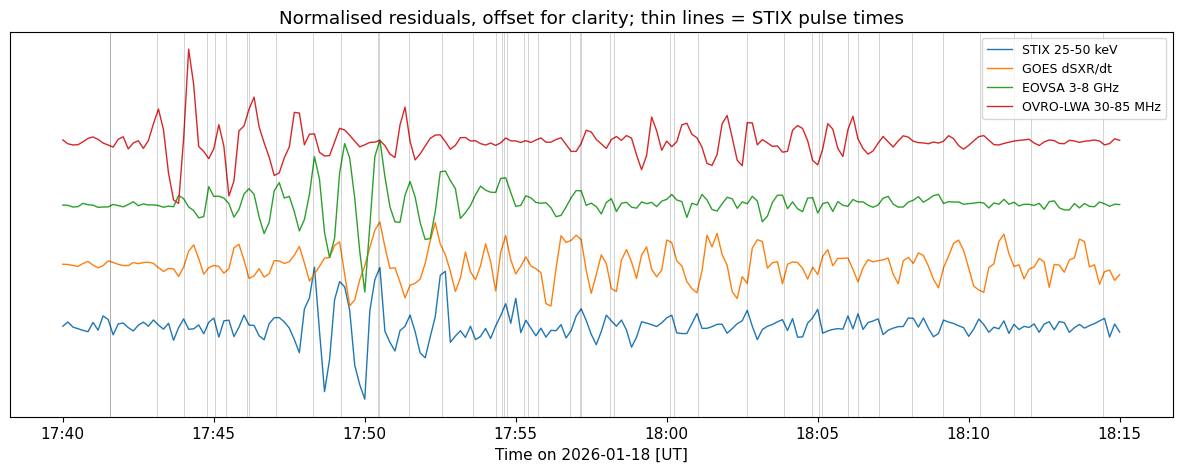

In [174]:
fig, ax = plt.subplots(figsize=[15,5])
for i, col in enumerate(X.columns):
    ax.plot(X.index, standardise(X[col].values) + 4 * i, lw=1, label=col)
for tp in pulse_df['t_peak']:
    ax.axvline(tp, color='k', lw=0.4, alpha=0.3)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel(f"Time on {event['date']} [UT]")
ax.set_title('Normalised residuals, offset for clarity; thin lines = STIX pulse times')
# savefig(fig, 'cross_instrument_residuals')
plt.show()

saved /home/mnedal/data/2026-01-18/figures/cross_correlation_lags.pdf|png


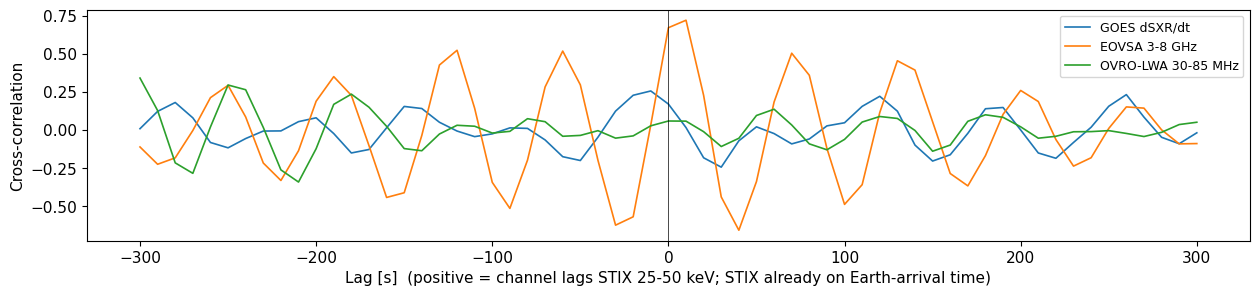

In [178]:
def xcorr(ref, x, dt_s, max_lag_s=300):
    '''
    Cross-correlation of x against ref (both standardised).
    Sign convention (v2, verified on synthetic data): a peak at POSITIVE lag means x
    LAGS ref, i.e. the same feature arrives later in x than in ref. The previous
    version had this convention inverted in the axis label and the CSV.
    '''
    ref = standardise(np.nan_to_num(ref))
    x = standardise(np.nan_to_num(x))
    cc = correlate(x, ref, mode='full') / len(ref)
    lags = np.arange(-len(ref) + 1, len(ref)) * dt_s
    sel = np.abs(lags) <= max_lag_s
    return lags[sel], cc[sel]


ref = 'STIX 25-50 keV'
fig, ax = plt.subplots(figsize=[15,3])
lag_rows = []
for col in [c for c in X.columns if c != ref]:
    lags, cc = xcorr(X[ref].values, X[col].values, 10)
    ax.plot(lags, cc, lw=1.2, label=col)
    lag_pk = lags[np.argmax(cc)]
    lag_rows.append({'channel': col, 'peak_lag_s': int(lag_pk), 'peak_cc': round(float(np.max(cc)), 2)})
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(f'Lag [s]  (positive = channel lags {ref}; STIX already on Earth-arrival time)')
ax.set_ylabel('Cross-correlation')
ax.legend(fontsize=9)
savefig(fig, 'cross_correlation_lags')
plt.show()

In [179]:
lag_df = pd.DataFrame(lag_rows)
# lag_df.to_csv(f'{res_dir}/cross_correlation_lags.csv', index=False)
lag_df

,channel,peak_lag_s,peak_cc
0,GOES dSXR/dt,-10,0.26
1,EOVSA 3-8 GHz,10,0.72
2,OVRO-LWA 30-85 MHz,-300,0.34


Beyond lags, run §5's periodogram/wavelet per channel and collect a **period comparison
table** — one period per channel with uncertainty (half-width of the significant peak).
Wavelet coherence (`pycwt.wct`) between STIX and EOVSA is the natural follow-up once the
EOVSA file is in hand; interpret only outside the COI and above the 95% level.

In [30]:
period_rows = []
for col in X.columns:
    f_c, p_c = periodogram(np.nan_to_num(X[col].values), 10)
    try:
        popt_c, _ = fit_rednoise(f_c, p_c)
        _, confs_c = confidence_levels(f_c, popt_c, len(f_c))
        ok = p_c > confs_c['global_0.95']
        dom = 1 / f_c[ok][np.argmax(p_c[ok])] if ok.any() else np.nan
    except RuntimeError:
        dom = np.nan
    period_rows.append({'channel': col, 'dominant_period_s': round(float(dom), 1) if np.isfinite(dom) else np.nan})

period_df = pd.DataFrame(period_rows)
period_df.to_csv(f'{res_dir}/period_comparison.csv', index=False)
period_df

,channel,dominant_period_s
0,STIX 25-50 keV,65.9
1,GOES dSXR/dt,95.9
2,OVRO-LWA 30-85 MHz,70.3


### 6.1 Epoch view: stacked light curves across frequency, and the LWA spectrum of the same window

One shared epoch window (`EPOCH_WINDOW`, default 17:30–19:30 UT) viewed two ways. First, the light curves stacked vertically in a single figure — GOES SXR derivative, STIX HXR bands, (EOVSA when on disk), then OVRO-LWA sub-bands from high to low frequency — each panel either SG-detrended in $\sigma$ units (`EPOCH_MODE='residual'`) or standardised raw (`'raw'`), with the §4 STIX pulse times marked across every panel so the pulsations can be followed from keV to MHz. Second, the background-ratioed LWA dynamic spectrum over the same window, with the sub-band boundaries of the stack overlaid. If the ladder shows coherent pulsation evolution, a superposed-epoch average keyed on the pulse times is the natural quantitative follow-up.

Note: STIX QL data are sliced to `stix_window` (17:00–19:00 UT) in §3 — widen that window there if the STIX panels should fill the full epoch window.

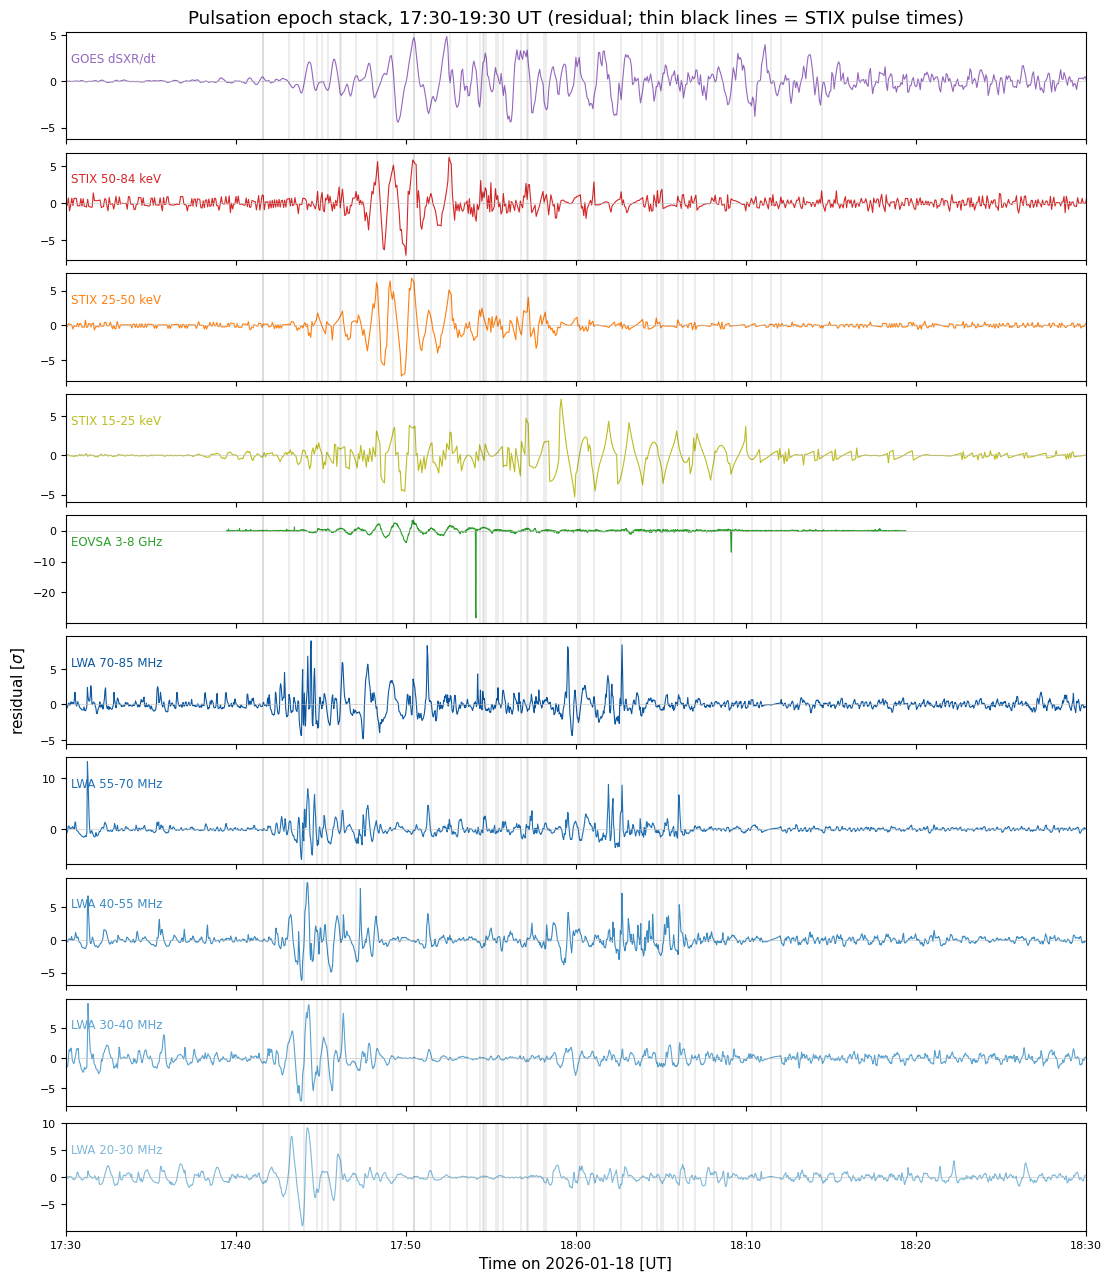

In [183]:
# ---- §6.1 epoch stack: light curves across frequency in one shared window ----
EPOCH_WINDOW    = ('2026-01-18T17:30:00', '2026-01-18T19:30:00')       # shared epoch window
EPOCH_MODE      = 'residual'          # 'residual' (SG-detrended, sigma units) | 'raw' (standardised)
EPOCH_DETREND_S = 120                 # Savitzky-Golay detrend window for 'residual' mode [s]
LWA_EPOCH_BANDS = [(70, 85), (55, 70), (40, 55), (30, 40), (20, 30)]   # MHz, high -> low


def _epoch_series(t_index, y, dt_s):
    '''Slice a series to EPOCH_WINDOW and reduce it per EPOCH_MODE.'''
    s = pd.Series(y, index=pd.DatetimeIndex(t_index)).dropna()
    s = s.loc[pd.Timestamp(EPOCH_WINDOW[0]):pd.Timestamp(EPOCH_WINDOW[1])]
    if len(s) < 10:
        return None
    if EPOCH_MODE == 'residual':
        g, _, _, _, rn = qpp_residual(s.index, s.values, window_s=EPOCH_DETREND_S, dt_s=dt_s)
        return pd.Series(rn, index=g)
    return pd.Series(standardise(s.values), index=s.index)


epoch_panels = []

sx = sxr_deriv_smooth.dropna()
ser = _epoch_series(sx.index, sx.values, 4)
if ser is not None:
    epoch_panels.append(('GOES dSXR/dt', ser, 'tab:purple'))

# STIX panels stop at stix_window[1] (19:00) unless that slice is widened in §3
for band, colr in [('50-84 keV', 'tab:red'), ('25-50 keV', 'tab:orange'),
                   ('15-25 keV', 'tab:olive')]:
    ser = _epoch_series(stix[band]['t'], stix[band]['rate'], 4)
    if ser is not None:
        epoch_panels.append((f'STIX {band}', ser, colr))

if have_eovsa:
    lc = band_lightcurve(eov_t, eov_f, eov_s, 3, 8, window=EPOCH_WINDOW,
                         bkg_window=eovsa_bkg_window, log_ratio=False)
    ser = _epoch_series(lc.index, lc.values, 1)
    if ser is not None:
        epoch_panels.append(('EOVSA 3-8 GHz', ser, 'tab:green'))

if have_lwa:
    bcols = plt.cm.Blues(np.linspace(0.85, 0.45, len(LWA_EPOCH_BANDS)))
    for (f_lo, f_hi), colr in zip(LWA_EPOCH_BANDS, bcols):
        lc = band_lightcurve(lwa_t, lwa_f, lwa_s, f_lo, f_hi, window=EPOCH_WINDOW,
                             bkg_window=radio_bkg_window)
        ser = _epoch_series(lc.index, lc.values, 2)
        if ser is not None:
            epoch_panels.append((f'LWA {f_lo}-{f_hi} MHz', ser, colr))

n_ep = len(epoch_panels)
fig, axs = plt.subplots(n_ep, 1, figsize=[11, 1.15 * n_ep + 1.2], sharex=True, constrained_layout=True)
axs = np.atleast_1d(axs)
for ax, (label, ser, colr) in zip(axs, epoch_panels):
    ax.plot(ser.index, ser.values, lw=0.8, color=colr)
    ax.axhline(0, color='0.75', lw=0.4)
    if 'pulse_df' in globals() and len(pulse_df):
        for tp in pulse_df['t_peak']:
            if pd.Timestamp(EPOCH_WINDOW[0]) <= tp <= pd.Timestamp(EPOCH_WINDOW[1]):
                ax.axvline(tp, color='k', lw=0.3, alpha=0.35)
    ax.annotate(label, xy=[0.005, 0.72], xycoords='axes fraction', fontsize=8.5, color=colr)
    ax.tick_params(labelsize=8)

axs[n_ep // 2].set_ylabel('residual [$\sigma$]' if EPOCH_MODE == 'residual' else 'standardised')
axs[0].set_title(f'Pulsation epoch stack, {EPOCH_WINDOW[0][11:16]}-{EPOCH_WINDOW[1][11:16]} UT '
                 f'({EPOCH_MODE}; thin black lines = STIX pulse times)')
axs[-1].set_xlim(pd.Timestamp(EPOCH_WINDOW[0]),
                 # pd.Timestamp(EPOCH_WINDOW[1])
                 pd.Timestamp('2026-01-18T18:30')
                )
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[-1].set_xlabel(f"Time on {event['date']} [UT]")
fig.align_ylabels(axs)
fig.subplots_adjust(hspace=0.08)
# savefig(fig, f'epoch_stack_{EPOCH_MODE}')
plt.show()

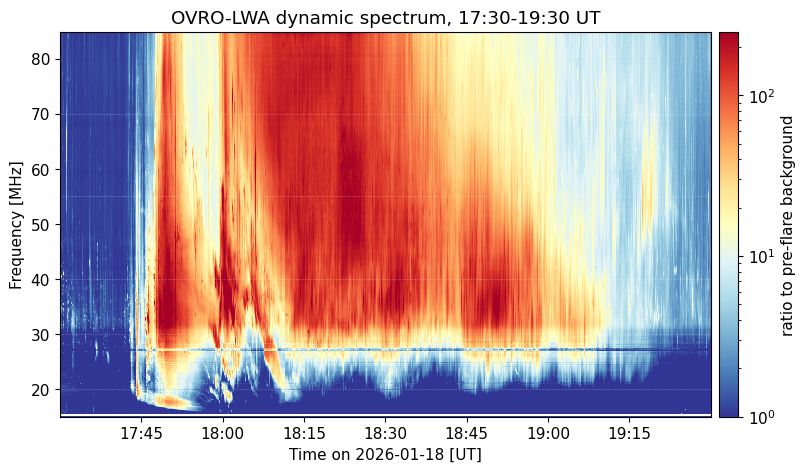

In [184]:
# ---- §6.1b OVRO-LWA dynamic spectrum over the epoch window ----
if have_lwa:
    wsel = (lwa_t >= pd.Timestamp(EPOCH_WINDOW[0])) & (lwa_t <= pd.Timestamp(EPOCH_WINDOW[1]))
    bsel = (lwa_t >= pd.Timestamp(radio_bkg_window[0])) & (lwa_t <= pd.Timestamp(radio_bkg_window[1]))
    bkg = np.nanmedian(lwa_s[:, bsel].astype(float), axis=1)[:, None]
    with np.errstate(all='ignore'):
        ratio = lwa_s[:, wsel].astype(float) / bkg
    tw = lwa_t[wsel]
    step = max(1, len(tw) // 7000)        # keep pcolormesh light (~0.5 s cadence x 2 h)

    fig, ax = plt.subplots(figsize=[10,5])
    pm = ax.pcolormesh(tw[::step], lwa_f, ratio[:, ::step],
                       norm=colors.LogNorm(vmin=max(1, np.nanpercentile(ratio, 5)),
                                           vmax=np.nanpercentile(ratio, 99.5)),
                       cmap='RdYlBu_r', rasterized=True)
    fig.colorbar(pm, ax=ax, pad=0.01, label='ratio to pre-flare background')
    # sub-band boundaries used in the epoch stack above
    for f_lo, f_hi in LWA_EPOCH_BANDS:
        ax.axhline(f_lo, color='w', lw=0.4, ls=':', alpha=0.6)
    ax.axhline(LWA_EPOCH_BANDS[0][1], color='w', lw=0.4, ls=':', alpha=0.6)
    ax.set_ylim(lwa_f.min(), lwa_f.max())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f"Time on {event['date']} [UT]")
    ax.set_ylabel('Frequency [MHz]')
    ax.set_title(f'OVRO-LWA dynamic spectrum, {EPOCH_WINDOW[0][11:16]}-{EPOCH_WINDOW[1][11:16]} UT')
    # savefig(fig, 'lwa_dynspec_epoch_window')
    plt.show()
else:
    print('OVRO-LWA spectrum not loaded - epoch-window spectrum skipped')

## 7. Type III bursts: timing against HXR pulses, polarisation, imaging

### 7.1 Burstiness of acceleration: type III occurrence vs STIX peaks (Shilpi)

Type III times from the frequency-collapsed LWA profile; matching tolerance is set by the
10 s LWA cadence, so association is claimed at ±15 s and treated as indicative, not exact.

17 type IIIs; 65% matched to an HXR pulse within ±15 s


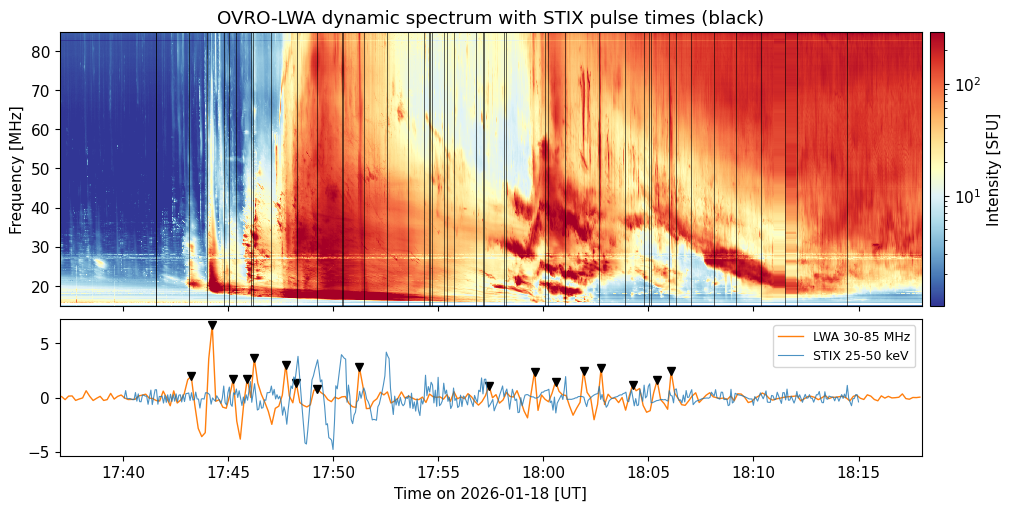

In [187]:
if have_lwa:
    lwa_prof = channels['OVRO-LWA 30-85 MHz']
    t3_idx, t3_props = find_peaks(lwa_prof.values, prominence=1.5, distance=2)
    t3_times = lwa_prof.index[t3_idx]

    # v2: STIX pulse times are Earth-arrival (shifted in §3), so this window now tests
    # true simultaneity rather than orbital geometry (~119 s offset before the fix)
    tol = pd.Timedelta(seconds=15)
    matches = []
    for t3 in t3_times:
        d = (pulse_df['t_peak'] - t3).abs()
        j = d.idxmin()
        matches.append({'t_typeIII': t3, 't_hxr': pulse_df.loc[j, 't_peak'],
                        'dt_s': (pulse_df.loc[j, 't_peak'] - t3).total_seconds(),
                        'matched': d.min() <= tol})
    match_df = pd.DataFrame(matches)
    match_df.to_csv(f'{res_dir}/typeIII_hxr_matches.csv', index=False)
    frac = match_df['matched'].mean()
    print(f'{len(t3_times)} type IIIs; {frac:.0%} matched to an HXR pulse within ±15 s')
    results['typeIII_hxr_match_frac'] = round(float(frac), 2)

    wp = (lwa_t >= qpp_padded[0]) & (lwa_t <= qpp_padded[1])
    lwa_sw = lwa_s[:, wp]

    fig, axs = plt.subplots(2, 1, figsize=[10,5], sharex=True, height_ratios=[2,1], constrained_layout=True)
    dys = axs[0].pcolormesh(lwa_t[wp], lwa_f, lwa_sw,
                            norm=colors.LogNorm(vmin=np.nanpercentile(lwa_sw, 5),
                                                vmax=np.nanpercentile(lwa_sw, 99)),
                            cmap='RdYlBu_r')
    fig.colorbar(dys, ax=axs[0], pad=0.01, label='Intensity [SFU]')
    axs[0].set_ylabel('Frequency [MHz]')
    axs[0].set_title('OVRO-LWA dynamic spectrum with STIX pulse times (black)')
    for tp in pulse_df['t_peak']:
        axs[0].axvline(tp, color='k', lw=0.6, alpha=0.7)

    axs[1].plot(lwa_prof.index, lwa_prof.values, lw=1, color='tab:orange', label='LWA 30-85 MHz')
    axs[1].plot(t3_times, lwa_prof.values[t3_idx], 'kv', ms=6)
    axs[1].plot(grid_nt, resid_n, lw=0.8, color='tab:blue', alpha=0.8, label='STIX 25-50 keV')
    axs[1].legend(fontsize=9)
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axs[1].set_xlabel(f"Time on {event['date']} [UT]")
    # savefig(fig, 'typeIII_vs_hxr_timing')
    plt.show()

### 7.2 Type III polarisation (LWA Stokes V/I)

Sense and degree of circular polarisation across the type III group constrain the magnetic
field orientation along the beam paths — o-mode dominance is the expectation; changes of
sign across bursts would point to distinct source regions or field geometries. That reading
is a hypothesis to test against the imaging in §7.3.

saved .//2026-01-18/figures/typeIII_polarisation.pdf|png


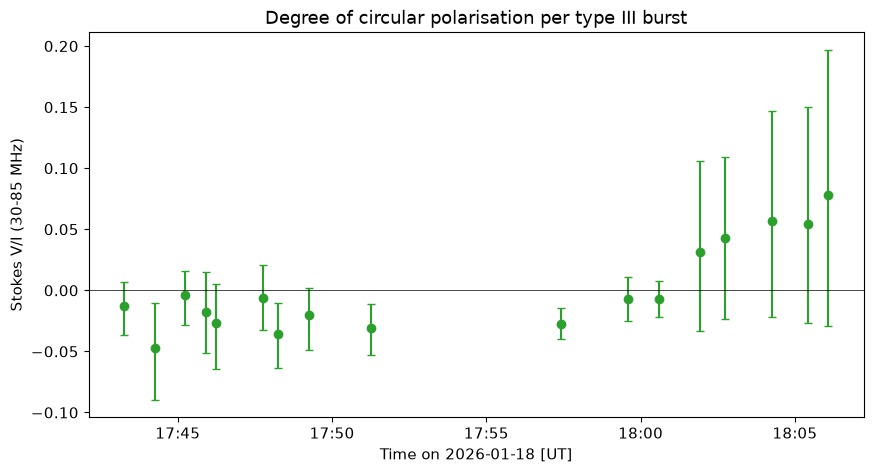

In [34]:
# The polarisation planes live on the first axis of the same dspec cube.
# TODO: confirm the plane ordering with Peijin (assumed here: plane 0 = Stokes I,
# plane 1 = Stokes V); the V sign convention decides o-mode vs x-mode.
if have_lwa and lwa_cube.shape[0] >= 2:
    lwa_tw = lwa_t[wp]
    dcp = lwa_cube[1][:, wp] / lwa_cube[0][:, wp]

    rows = []
    for t3 in t3_times:
        w = (lwa_tw >= t3 - pd.Timedelta(seconds=10)) & (lwa_tw <= t3 + pd.Timedelta(seconds=20))
        band = (lwa_f >= 30) & (lwa_f <= 85)
        box = dcp[np.ix_(band, w)]
        rows.append({'t_typeIII': t3, 'dcp_mean': float(np.nanmean(box)),
                     'dcp_p16': float(np.nanpercentile(box, 16)),
                     'dcp_p84': float(np.nanpercentile(box, 84))})
    dcp_df = pd.DataFrame(rows)
    dcp_df.to_csv(f'{res_dir}/typeIII_polarisation.csv', index=False)

    fig, ax = plt.subplots(figsize=[10,5])
    ax.errorbar(dcp_df['t_typeIII'], dcp_df['dcp_mean'],
                yerr=[dcp_df['dcp_mean'] - dcp_df['dcp_p16'], dcp_df['dcp_p84'] - dcp_df['dcp_mean']],
                fmt='o', color='tab:green', capsize=3)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Stokes V/I (30-85 MHz)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f"Time on {event['date']} [UT]")
    ax.set_title('Degree of circular polarisation per type III burst')
    savefig(fig, 'typeIII_polarisation')
    plt.show()
else:
    print('dspec cube has a single polarisation plane — ask Peijin for the Stokes V product')

### 7.3 LWA imaging: source centroids on the AIA disc

~10 s cadence imaging FITS (Peijin's Google Drive). Centroids above a threshold trace the
type III trajectories; Catherine's uncertainty map bounds where triangulation with a second
array would be viable. Positions at these frequencies carry ionospheric + scattering shifts
— treat absolute positions with care, relative motion is the robust quantity.

In [35]:
lwa_img_files = sorted(glob.glob(f"{paths['lwa_imaging']}/*.fits"))
print(f'{len(lwa_img_files)} LWA imaging files')
if lwa_img_files:
    inspect_fits(lwa_img_files[0])

0 LWA imaging files


In [36]:
def lwa_image_centroids(files, thresh_frac=0.7):
    """
    Brightest-pixel + intensity-weighted centroid per file (per frequency plane if 3D).
    Returns a tidy DataFrame; coordinates in the file's native WCS (arcsec if helioprojective).
    """
    rows = []
    rot_warned = False
    for fname in tqdm(files, desc='LWA images'):
        with fits.open(fname) as hdul:
            hdu = hdul[0]
            data = np.squeeze(hdu.data)
            hdr = hdu.header
            tobs = pd.Timestamp(hdr.get('DATE-OBS', hdr.get('DATE_OBS')))
            crota = float(hdr.get('CROTA2', hdr.get('CROTA', 0)) or 0)
            if abs(crota) > 0.5 and not rot_warned:
                print(f'WARNING: {os.path.basename(fname)} has CROTA={crota:.1f} deg - '
                      'the linear WCS conversion below ignores rotation')
                rot_warned = True
            planes = data[None, ...] if data.ndim == 2 else data
            for k, img in enumerate(planes):
                if not np.isfinite(img).any():
                    continue
                pk = np.nanmax(img)
                ys, xs = np.where(img >= thresh_frac * pk)
                wts = img[ys, xs]
                cx = np.sum(xs * wts) / np.sum(wts)
                cy = np.sum(ys * wts) / np.sum(wts)
                x_world = hdr['CRVAL1'] + (cx + 1 - hdr['CRPIX1']) * hdr['CDELT1']
                y_world = hdr['CRVAL2'] + (cy + 1 - hdr['CRPIX2']) * hdr['CDELT2']
                rows.append({'time': tobs, 'plane': k, 'x': x_world, 'y': y_world, 'peak': pk})
    return pd.DataFrame(rows)


if lwa_img_files:
    cen_df = lwa_image_centroids(lwa_img_files)
    cen_df.to_csv(f'{res_dir}/lwa_centroids.csv', index=False)

In [37]:
# AIA access with automatic download and level upgrade: disk is checked first,
# anything missing is fetched with Fido, and aiapy performs the 1.0 -> 1.5 upgrade
# (update_pointing -> register -> correct_degradation -> /exposure). Cached next to originals so
# the JSOC pointing query and the registration run once per file.
try:
    from aiapy.calibrate import register, update_pointing, correct_degradation
    from aiapy.calibrate.util import get_pointing_table
    have_aiapy = True
except ImportError:
    have_aiapy = False
    print('aiapy not installed (pip install aiapy) — AIA maps will stay at level 1')


def aia_to_lev15(m):
    '''Full AIA level-1 -> 1.5 preparation, in order: update_pointing -> register ->
    correct_degradation -> normalise by the exposure time (data then in DN/s), following
    the aiapy calibration hierarchy.'''
    if not have_aiapy or float(m.meta.get('lvl_num', 1)) >= 1.5:
        return m
    try:
        ptab = get_pointing_table('jsoc', time_range=(m.date - 12 * u.hour, m.date + 12 * u.hour))
        m = update_pointing(m, pointing_table=ptab)
    except Exception as err:
        print(f'pointing table unavailable ({err}) — registering with the header pointing')
    m = register(m)                                       # 1.5 plate scale, roll, disc centre
    try:
        m = correct_degradation(m)                        # time-dependent throughput
    except Exception as err:
        print(f'degradation correction skipped ({err})')
    m = m / m.exposure_time                               # normalise to DN/s
    return m


def get_aia_map(t_target, wavelength=171, max_offset_min=5, level15=True):
    '''
    Nearest AIA map to t_target: from disk if a frame lies within max_offset_min,
    otherwise downloaded via Fido. Returns a level-1.5 sunpy map when aiapy is
    available (cached as aia.lev15.*.fits), else the level-1 map.
    '''
    t_target = pd.Timestamp(t_target)
    cands = []
    for fname in glob.glob(f"{paths['aia']}/*.fits"):
        if f'{wavelength}a' not in os.path.basename(fname).lower():
            continue
        hdr = None
        for ext in [1, 0]:
            try:
                h = fits.getheader(fname, ext)
                if 'DATE-OBS' in h:
                    hdr = h
                    break
            except Exception:
                continue
        if hdr is None:
            continue
        t_obs = pd.Timestamp(hdr['DATE-OBS'].rstrip('Z'))
        cands.append((abs((t_obs - t_target).total_seconds()), float(hdr.get('LVL_NUM', 1)), fname))

    fname = None
    if cands:
        cands.sort()
        off_s, lvl, best = cands[0]
        if off_s <= max_offset_min * 60:
            # prefer an already-cached lev1.5 frame at the same offset
            lev15_same = [c for c in cands if abs(c[0] - off_s) < 1 and c[1] >= 1.5]
            fname = lev15_same[0][2] if lev15_same else best

    if fname is None:
        pad = pd.Timedelta(minutes=max_offset_min)
        query = Fido.search(a.Time(t_target - pad, t_target + pad),
                            a.Instrument('AIA'), a.Wavelength(wavelength * u.angstrom))
        if len(query[0]) == 0:
            raise FileNotFoundError(f'no AIA {wavelength} Å data found within '
                                    f'±{max_offset_min} min of {t_target}')
        fetched = Fido.fetch(query[0, 0], path=f"{paths['aia']}/{{file}}")
        fname = sorted(fetched)[0]

    m = sunpy.map.Map(fname)
    if level15 and float(m.meta.get('lvl_num', 1)) < 1.5:
        m = aia_to_lev15(m)
        cache = (f"{paths['aia']}/aia.lev15.{wavelength}A_"
                 f"{m.date.datetime.strftime('%Y%m%dT%H%M%S')}.fits")
        if not os.path.exists(cache):
            m.save(cache)
    return m


In [38]:
# AIA context frame near the flare peak for the overlay (level 1.5 via get_aia_map)
m_aia = get_aia_map(event['flare_peak'], wavelength=171)
print(f'AIA frame at {m_aia.date.isot}, processing level {m_aia.processing_level}')

if lwa_img_files:
    fig = plt.figure(figsize=[8,8])
    ax = fig.add_subplot(projection=m_aia)
    m_aia.plot(axes=ax, clip_interval=(1, 99.9) * u.percent)
    sc = ax.scatter_coord(SkyCoord(cen_df['x'].values * u.arcsec, cen_df['y'].values * u.arcsec,
                                   frame=m_aia.coordinate_frame),
                          c=mdates.date2num(cen_df['time']), cmap='cool', s=25, edgecolor='k', lw=0.3)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8, label='Time [UT]')
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_title('OVRO-LWA source centroids on AIA 171 Å')
    savefig(fig, 'lwa_centroids_on_aia')
    plt.show()


AIA frame at 2026-01-18T18:09:09.350, processing level 1.5


### 7.4 Automatic type III detection (probabilistic Hough transform)

Two stages, both on the background-ratioed spectrogram with the slowly varying (type IV)
continuum removed by a per-channel running median:

1. **Detection** — the ~2 s-binned residual is thresholded at $z > 5$, cleaned
   morphologically, and near-vertical bright lanes are found with the probabilistic Hough
   transform (at this pixel aspect any drift faster than ~1 MHz/s is within ±15° of
   vertical); overlapping segments merge into burst groups.
2. **Characterisation** — at the native ~0.5 s cadence each group is split into individual
   bursts (peaks of the band-summed residual), the drift rate $df/dt$ comes from a
   Theil–Sen fit of the per-channel peak times (robust against blends), and the exciter
   speed follows from $v = (df/dt)\,/\,(df/dr)$ with $df/dr$ from a density model at the
   geometric-mean frequency — fundamental emission assumed. The kinetic energy per burst
   is relativistic, $E = (\gamma - 1)\,m_e c^2$.

Caveats: positive-drift entries are blends or reverse-drift features and get no speed;
detections after ~18:12 UT sit on the type IV continuum and are fast fine structures
rather than classic flare-accelerated type IIIs — judge from the overview figure. The
detection parameters in `t3_par` were tuned on this spectrogram (0.514 s cadence,
731 channels); re-tune after any change of window or binning.


In [39]:
# Coronal density models and frequency-inversion utilities, shared by the type III
# kinematics (§7.4) and the type II shock parameters (§8.1). Conventions ported from
# trace_type2_ilofar_orfees.ipynb so both events are processed identically.
MU = 1.27                                  # mean mass per electron [m_p], band-split literature convention.
# NOTE (v2): a fully ionised 10% He corona gives 1.17, and GY11's v_A = 2.18e6 n^-1/2 B
# corresponds to mu = 1, so comparing our band-split B with their profile carries a
# built-in sqrt(1.27) ~ 13% systematic. State the adopted mu explicitly in the paper.
R_SUN_M = const.R_sun.to_value(u.m)
M_P = const.m_p.si.value
MU0 = const.mu0.si.value
C_MS = const.c.si.value
# electron plasma frequency: f_p[Hz] = PLASMA_CONST * sqrt(Ne[cm^-3])
PLASMA_CONST = float((1 / (2 * np.pi)) * np.sqrt(
    (const.e.si**2 / (const.eps0 * const.m_e)).to_value(u.m**3 / u.s**2) * 1e6))


def newkirk(r, fold=1):
    # Newkirk (1961)
    r = np.asarray(r, float)
    return fold * 4.2e4 * 10.0**(4.32 / r)


def saito(r, fold=1):
    # Saito, Poland & Munro (1977) two-term background corona (v2: was mis-cited as Saito 1970)
    r = np.asarray(r, float)
    return fold * (1.36e6 * r**-2.14 + 1.68e8 * r**-6.13)


def leblanc(r, fold=1):
    # Leblanc, Dulk & Bougeret (1998)
    r = np.asarray(r, float)
    return fold * (3.3e5 * r**-2 + 4.1e6 * r**-4 + 8e7 * r**-6)


def freq_to_density(f_hz, harmonic=1):
    return (np.asarray(f_hz, float) / harmonic / PLASMA_CONST)**2


def freq_to_radius(f_hz, model, harmonic=1, r_bounds=(1, 5), nres=6000):
    # invert a monotonically decreasing Ne(r) model for the source height (vectorised);
    # out-of-range densities (source below the surface for that model) -> NaN
    rr = np.linspace(r_bounds[0], r_bounds[1], nres)
    ne = model(rr)
    ne_t = freq_to_density(np.atleast_1d(f_hz), harmonic=harmonic)
    r = np.interp(ne_t, ne[::-1], rr[::-1])
    r[(ne_t > np.nanmax(ne)) | (ne_t < np.nanmin(ne))] = np.nan
    return r if r.size > 1 else float(r[0])


def alfven_mach_from_X(X):
    # Vrsnak et al. (2002) perpendicular-shock M_A(X) in the beta -> 0 limit, gamma = 5/3
    # baked into the constants; valid for 1 <= X < 4. Assumes the shock speed is measured
    # against a static upstream corona (no wind subtraction; fine below ~3 Rsun).
    X = np.asarray(X, float)
    out = np.full(X.shape, np.nan)
    ok = (X >= 1) & (X < 4)
    out[ok] = np.sqrt(X[ok] * (X[ok] + 5) / (2 * (4 - X[ok])))
    return out


BASE_MODELS = {'Newkirk': newkirk, 'Saito': saito, 'Leblanc': leblanc}
FOLDS = [1, 2, 3, 4]
MODEL_GRID = {f'{name} x{fold}': (lambda r, _f=fun, _k=fold: _f(r, fold=_k))
              for name, fun in BASE_MODELS.items() for fold in FOLDS}
print('model x fold combinations:', len(MODEL_GRID))


model x fold combinations: 12


In [40]:
from scipy.ndimage import median_filter
from scipy.stats import theilslopes

try:
    from skimage.morphology import remove_small_objects, closing
    from skimage.transform import probabilistic_hough_line
    try:
        from skimage.morphology import footprint_rectangle

        def _vert_footprint(n):
            return footprint_rectangle((n, 1))
    except ImportError:                                    # scikit-image < 0.25
        from skimage.morphology import rectangle

        def _vert_footprint(n):
            return rectangle(n, 1)
    have_skimage = True
except ImportError:
    have_skimage = False
    print('scikit-image not installed (pip install scikit-image) — §7.4 will skip')


def _hough(mask, threshold, line_length, line_gap, theta, seed=42):
    try:
        return probabilistic_hough_line(mask, threshold=threshold, line_length=line_length,
                                        line_gap=line_gap, theta=theta, rng=seed)
    except TypeError:                                      # scikit-image < 0.23
        return probabilistic_hough_line(mask, threshold=threshold, line_length=line_length,
                                        line_gap=line_gap, theta=theta, seed=seed)


def _detrended_z(t_index, freqs, spec, window, bkg_window, nbin, trend_s,
                 f_min_mhz=16, occupancy_max=0.3):
    '''Background-ratioed, continuum-detrended, MAD-normalised spectrogram slice.'''
    wsel = (t_index >= pd.Timestamp(window[0])) & (t_index <= pd.Timestamp(window[1]))
    sw = spec[:, wsel].astype(float)
    tw = t_index[wsel]
    bsel = (t_index >= pd.Timestamp(bkg_window[0])) & (t_index <= pd.Timestamp(bkg_window[1]))
    bkg = np.nanmedian(spec[:, bsel].astype(float), axis=1)[:, None]

    dt_raw = np.median(np.diff(tw.values).astype('timedelta64[ms]').astype(float)) / 1000
    if nbin > 1:
        nt = (sw.shape[1] // nbin) * nbin
        sw = np.nanmean(sw[:, :nt].reshape(sw.shape[0], -1, nbin), axis=2)
        tw = tw[:nt][nbin // 2::nbin][:sw.shape[1]]
    dt_s = dt_raw * nbin

    with np.errstate(all='ignore'):
        logr = np.log10(sw / bkg)
    logr[~np.isfinite(logr)] = 0
    # the running median over ~trend_s removes the type IV continuum, keeping transients
    trend = median_filter(logr, size=(1, max(3, int(trend_s / dt_s) | 1)), mode='nearest')
    resid = logr - trend
    mad = np.nanmedian(np.abs(resid - np.nanmedian(resid))) * 1.4826
    z = resid / mad
    bad = ((z > 5).mean(axis=1) > occupancy_max) | (freqs < f_min_mhz)   # RFI / junk channels
    return tw, z, bad, dt_s


def typeiii_detect(t_index, freqs, spec, window, bkg_window, par):
    '''
    Stage 1: probabilistic-Hough detection of fast-drift lanes; returns the burst-group
    table and a diagnostics dict (binned time axis, z, mask, segments).
    '''
    tb, z, bad, dt_bin = _detrended_z(t_index, freqs, spec, window, bkg_window,
                                      par['nbin'], par['trend_s'],
                                      par['f_min_mhz'], par['occupancy_max'])
    mask = z > par['z_thresh']
    mask[bad] = False
    df_chan = np.median(np.diff(freqs))
    mask = closing(mask, _vert_footprint(max(3, int(par['close_mhz'] / df_chan))))
    mask = remove_small_objects(mask, min_size=par['min_size_pix'])

    theta = np.deg2rad(np.linspace(-par['theta_max_deg'], par['theta_max_deg'],
                                   8 * par['theta_max_deg'] + 1))
    segs = _hough(mask, par['hough_threshold'], int(par['line_length_mhz'] / df_chan),
                  int(par['line_gap_mhz'] / df_chan), theta)

    groups = []
    if segs:
        iv = sorted((min(x0, x1), max(x0, x1)) for (x0, y0), (x1, y1) in segs)
        merged = []
        c0, c1 = iv[0]
        for lo, hi in iv[1:]:
            if lo <= c1 + int(par['merge_gap_s'] / dt_bin):
                c1 = max(c1, hi)
            else:
                merged.append((c0, c1))
                c0, c1 = lo, hi
        merged.append((c0, c1))
        for c0, c1 in merged:
            sub = mask[:, c0:c1 + 1]
            chans = np.where(sub.any(axis=1))[0]
            if len(chans) < 2:
                continue
            groups.append({'t_start': tb[c0], 't_end': tb[min(c1, len(tb) - 1)],
                           'f_lo_mhz': freqs[chans.min()], 'f_hi_mhz': freqs[chans.max()],
                           'n_pix': int(sub.sum())})
    diag = {'tb': tb, 'z': z, 'mask': mask, 'bad': bad, 'segments': segs, 'dt_bin': dt_bin}
    return pd.DataFrame(groups), diag


# parameters tuned on this spectrogram; lengths/gaps are physical (MHz, s), not pixels
t3_window = ('2026-01-18T17:20:00', '2026-01-18T19:00:00')
t3_par = {'nbin': 4, 'trend_s': 60, 'z_thresh': 5, 'f_min_mhz': 16, 'occupancy_max': 0.3,
          'close_mhz': 0.7, 'min_size_pix': 30, 'hough_threshold': 10,
          'line_length_mhz': 10, 'line_gap_mhz': 1.2, 'theta_max_deg': 15, 'merge_gap_s': 8}

if have_lwa and have_skimage:
    t3_groups, t3_diag = typeiii_detect(lwa_t, lwa_f, lwa_s, t3_window, radio_bkg_window, t3_par)
    print(f"{len(t3_groups)} burst groups from {len(t3_diag['segments'])} Hough segments")

32 burst groups from 169 Hough segments


In [41]:
T3_MODEL = newkirk        # density model for the exciter kinematics
T3_FOLD = 1               # fold factor (x1 quiet-Sun baseline; x2-x4 for denser corona)
T3_HARMONIC = 1           # fundamental plasma emission assumed


def beam_speed_from_drift(drift_mhz_s, f_lo_mhz, f_hi_mhz, model=T3_MODEL,
                          fold=T3_FOLD, harmonic=T3_HARMONIC):
    '''v/c and emission height from df/dt via v = (df/dt)/(df/dr) at the geometric-mean
    frequency. Negative drift (outward beam) gives positive speed.'''
    f_mid = np.sqrt(f_lo_mhz * f_hi_mhz)
    bound = (lambda r: model(r, fold=fold))
    r_mid = freq_to_radius(f_mid * 1e6, bound, harmonic=harmonic)
    if not np.isfinite(r_mid) or not np.isfinite(drift_mhz_s):
        return np.nan, r_mid
    dr = 1e-4
    f_of_r = lambda rr: harmonic * PLASMA_CONST * np.sqrt(bound(rr)) / 1e6
    dfdr = (f_of_r(r_mid + dr) - f_of_r(r_mid - dr)) / (2 * dr)      # MHz/Rsun, negative
    beta = (drift_mhz_s / dfdr) * R_SUN_M / C_MS
    return (beta if 0 < beta < 1 else np.nan), r_mid


def typeiii_characterise(t_index, freqs, spec, groups, window, bkg_window,
                         trend_s=60, z_floor=4, split_prom=0.25, min_sep_s=2,
                         min_chans=30, pad_s=3):
    '''
    Stage 2 at the native cadence: split each group into individual bursts, then per
    burst a Theil-Sen drift fit and the exciter speed/energy from the density model.
    '''
    tw, z, bad, dt_s = _detrended_z(t_index, freqs, spec, window, bkg_window,
                                    nbin=1, trend_s=trend_s)
    z[bad] = np.nan
    tsec = (tw - tw[0]).total_seconds().values

    bursts = []
    for gi, g in tqdm(groups.iterrows(), total=len(groups), desc='type III bursts'):
        c0 = max(0, tw.searchsorted(g['t_start'] - pd.Timedelta(seconds=pad_s)))
        c1 = min(len(tw) - 1, tw.searchsorted(g['t_end'] + pd.Timedelta(seconds=pad_s)))
        chans = np.where((freqs >= g['f_lo_mhz']) & (freqs <= g['f_hi_mhz']) & ~bad)[0]
        if len(chans) < min_chans or c1 - c0 < 2:
            continue
        prof = np.nansum(np.clip(z[np.ix_(chans, np.arange(c0, c1 + 1))], 0, None), axis=0)
        pk, _ = find_peaks(prof, prominence=split_prom * np.nanmax(prof),
                           distance=max(1, int(min_sep_s / dt_s)))
        if len(pk) == 0:
            pk = np.array([int(np.nanargmax(prof))])       # single burst peaking at an edge
        # single burst -> whole group window; a group of bursts -> +/- window per peak
        half = (c1 - c0) if len(pk) == 1 else max(int(4 / dt_s), (c1 - c0) // (2 * len(pk)))
        for p in pk:
            w0 = max(c0, c0 + p - half)
            w1 = min(c1, c0 + p + half)
            tpk, fpk = [], []
            for ch in chans:
                seg = z[ch, w0:w1 + 1]
                if np.all(~np.isfinite(seg)):
                    continue
                j = np.nanargmax(seg)
                if seg[j] > z_floor:
                    tpk.append(tsec[w0 + j])
                    fpk.append(freqs[ch])
            if len(fpk) < min_chans:
                continue
            tpk = np.asarray(tpk)
            fpk = np.asarray(fpk)
            slope, intercept, s_lo, s_hi = theilslopes(tpk, fpk)     # t(f) in s/MHz
            drift = 1 / slope if slope != 0 else np.nan              # MHz/s
            # v2: 1/slope confidence bounds are only meaningful when the slope CI does
            # not cross zero; otherwise the drift CI is unconstrained
            if s_lo != 0 and s_hi != 0 and np.sign(s_lo) == np.sign(s_hi):
                ci = np.array([1 / s_lo, 1 / s_hi])
                d_lo = float(np.min(ci))
                d_hi = float(np.max(ci))
            else:
                d_lo = np.nan
                d_hi = np.nan
            speeds = [beam_speed_from_drift(d, fpk.min(), fpk.max())[0] for d in [drift, d_lo, d_hi]]
            _, r_mid = beam_speed_from_drift(drift, fpk.min(), fpk.max())
            v, v_lo, v_hi = speeds[0], np.nanmin(speeds), np.nanmax(speeds)
            gamma_of = lambda be: 1 / np.sqrt(1 - be**2)
            e_of = lambda be: (gamma_of(be) - 1) * 510.999 if np.isfinite(be) else np.nan
            bursts.append({
                't_peak': tw[int(np.clip(c0 + p, w0, w1))],
                't_start': tw[w0], 't_end': tw[w1],
                'f_start_mhz': round(float(fpk.max()), 1),
                'f_end_mhz': round(float(fpk.min()), 1),
                'drift_mhz_s': round(float(drift), 2),
                'drift_lo': round(float(d_lo), 2), 'drift_hi': round(float(d_hi), 2),
                'r_mid_rsun': round(float(r_mid), 2) if np.isfinite(r_mid) else np.nan,
                'v_beam_c': round(float(v), 3) if np.isfinite(v) else np.nan,
                'v_beam_c_lo': round(float(v_lo), 3) if np.isfinite(v_lo) else np.nan,
                'v_beam_c_hi': round(float(v_hi), 3) if np.isfinite(v_hi) else np.nan,
                'E_kin_keV': round(e_of(v), 1) if np.isfinite(v) else np.nan,
                'E_kin_keV_lo': round(e_of(v_lo), 1) if np.isfinite(v_lo) else np.nan,
                'E_kin_keV_hi': round(e_of(v_hi), 1) if np.isfinite(v_hi) else np.nan,
                'n_chan': len(fpk), 'group': gi})
    out = pd.DataFrame(bursts)
    if len(out):
        out = out.sort_values('t_peak').reset_index(drop=True)
    return out


if have_lwa and have_skimage and len(t3_groups):
    t3_bursts = typeiii_characterise(lwa_t, lwa_f, lwa_s, t3_groups, t3_window, radio_bkg_window)
    t3_bursts.to_csv(f'{res_dir}/typeIII_auto_bursts.csv', index=False)
    neg = t3_bursts['drift_mhz_s'] < 0
    results['typeIII_n_auto'] = int(len(t3_bursts))
    results['typeIII_drift_median_MHz_s'] = round(float(t3_bursts.loc[neg, 'drift_mhz_s'].median()), 2)
    results['typeIII_vbeam_median_c'] = round(float(t3_bursts.loc[neg, 'v_beam_c'].median()), 3)
    results['typeIII_Ekin_median_keV'] = round(float(t3_bursts.loc[neg, 'E_kin_keV'].median()), 1)
    print(f'{len(t3_bursts)} bursts ({int(neg.sum())} with negative drift); '
          f"median drift {results['typeIII_drift_median_MHz_s']} MHz/s, "
          f"median v {results['typeIII_vbeam_median_c']} c, "
          f"median E {results['typeIII_Ekin_median_keV']} keV")
    display_cols = ['t_peak', 'f_start_mhz', 'f_end_mhz', 'drift_mhz_s',
                    'v_beam_c', 'E_kin_keV', 'r_mid_rsun', 'n_chan']
    print(t3_bursts[display_cols].to_string())

type III bursts: 100%|██████████| 32/32 [00:00<00:00, 104.87it/s]

39 bursts (28 with negative drift); median drift -9.44 MHz/s, median v 0.263 c, median E 18.6 keV
                    t_peak  f_start_mhz  f_end_mhz  drift_mhz_s  v_beam_c  E_kin_keV  r_mid_rsun  n_chan
0  2026-01-18 17:24:44.553         78.5       66.6          NaN       NaN        NaN        1.35     125
1  2026-01-18 17:25:50.292         84.9       20.2        -9.14     0.263       18.6        1.60     677
2  2026-01-18 17:26:11.349         84.9       20.2       -47.20       NaN        NaN        1.60     626
3  2026-01-18 17:26:33.433         84.9       23.4       -10.53     0.269       19.5        1.56     577
4  2026-01-18 17:26:48.327         84.9       20.2        -9.39     0.270       19.7        1.60     674
5  2026-01-18 17:28:15.124         84.9       19.9        -9.48     0.276       20.6        1.60     680
6  2026-01-18 17:30:42.010         41.5       25.6         7.08       NaN        NaN        1.73     120
7  2026-01-18 17:31:15.907         74.2       27.3       -30.5

saved .//2026-01-18/figures/typeIII_auto_detections.pdf|png


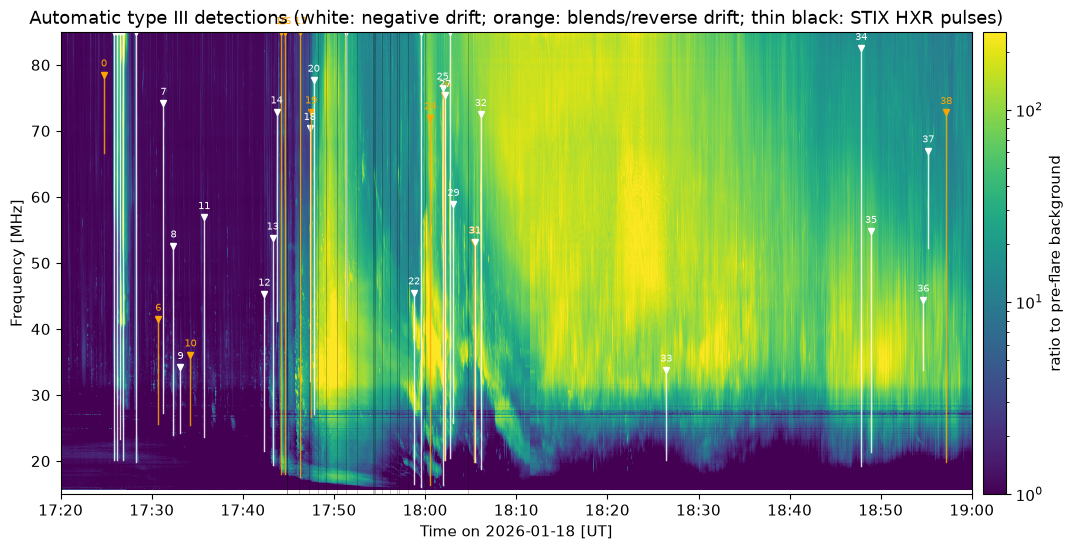

In [42]:
if have_lwa and have_skimage and len(t3_groups):
    wsel = (lwa_t >= pd.Timestamp(t3_window[0])) & (lwa_t <= pd.Timestamp(t3_window[1]))
    bsel = (lwa_t >= pd.Timestamp(radio_bkg_window[0])) & (lwa_t <= pd.Timestamp(radio_bkg_window[1]))
    bkg = np.nanmedian(lwa_s[:, bsel].astype(float), axis=1)[:, None]
    with np.errstate(all='ignore'):
        ratio = lwa_s[:, wsel].astype(float) / bkg
    tw = lwa_t[wsel]

    fig, ax = plt.subplots(figsize=[14,6])
    pm = ax.pcolormesh(tw[::4], lwa_f, ratio[:, ::4],
                       norm=colors.LogNorm(vmin=1, vmax=np.nanpercentile(ratio, 99.5)),
                       cmap='viridis', rasterized=True)
    fig.colorbar(pm, ax=ax, pad=0.01, label='ratio to pre-flare background')
    for i, row in t3_bursts.iterrows():
        colr = 'w' if row['drift_mhz_s'] < 0 else 'orange'
        ax.plot([row['t_peak'], row['t_peak']], [row['f_end_mhz'], row['f_start_mhz']],
                color=colr, lw=1, alpha=0.85)
        ax.plot(row['t_peak'], row['f_start_mhz'], 'v', color=colr, ms=5)
        ax.annotate(str(i), (row['t_peak'], row['f_start_mhz']), xytext=[0, 6],
                    textcoords='offset points', ha='center', fontsize=7, color=colr)
    for tp in pulse_df['t_peak']:
        ax.axvline(tp, color='k', lw=0.4, alpha=0.4)
    ax.set_ylabel('Frequency [MHz]')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f"Time on {event['date']} [UT]")
    ax.set_title('Automatic type III detections (white: negative drift; orange: blends/'
                 'reverse drift; thin black: STIX HXR pulses)')
    # savefig(fig, 'typeIII_auto_detections')
    plt.show()

saved .//2026-01-18/figures/typeIII_characteristics_hist.pdf|png


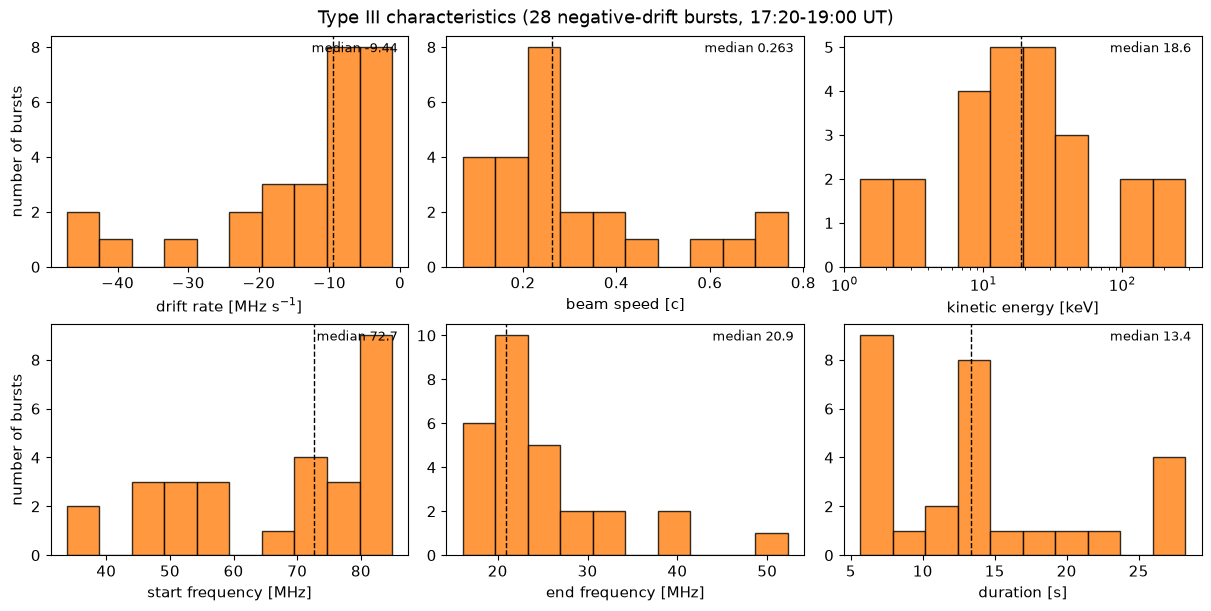

In [43]:
# Distributions of the automatically detected type III characteristics.
# Only negative-drift bursts enter (positive drifts are blends/reverse-drift, §7.4 text).
if have_lwa and have_skimage and len(t3_bursts):
    t3n = t3_bursts[t3_bursts['drift_mhz_s'] < 0].copy()
    dur_s = (t3n['t_end'] - t3n['t_start']).dt.total_seconds()
    panels = [
        (t3n['drift_mhz_s'], 'drift rate [MHz s$^{-1}$]', 'linear'),
        (t3n['v_beam_c'], 'beam speed [c]', 'linear'),
        (t3n['E_kin_keV'], 'kinetic energy [keV]', 'log'),
        (t3n['f_start_mhz'], 'start frequency [MHz]', 'linear'),
        (t3n['f_end_mhz'], 'end frequency [MHz]', 'linear'),
        (dur_s, 'duration [s]', 'linear'),
    ]
    fig, axs = plt.subplots(2, 3, figsize=[12,6], constrained_layout=True)
    for ax, (vals, label, scale) in zip(axs.ravel(), panels):
        vals = np.asarray(vals, float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            ax.set_axis_off()
            continue
        if scale == 'log' and vals.min() > 0:
            bins = np.geomspace(vals.min(), vals.max(), 11)
            ax.set_xscale('log')
        else:
            bins = 10
        ax.hist(vals, bins=bins, color='tab:orange', edgecolor='k', alpha=0.8)
        med = np.median(vals)
        ax.axvline(med, color='k', ls='--', lw=1)
        ax.annotate(f'median {med:.3g}', xy=[0.97, 0.93], xycoords='axes fraction',
                    ha='right', fontsize=9)
        ax.set_xlabel(label)
    axs[0, 0].set_ylabel('number of bursts')
    axs[1, 0].set_ylabel('number of bursts')
    fig.suptitle(f'Type III characteristics ({len(t3n)} negative-drift bursts, '
                 f'{t3_window[0][11:16]}-{t3_window[1][11:16]} UT)')
    savefig(fig, 'typeIII_characteristics_hist')
    plt.show()


## 8. CME kinematics and shock formation

Height-time points from LASCO C2/C3 and STEREO-A/COR2 (CDAW catalogue values, or your own
tie-points/GCS fits — replace the placeholder table). The near-Sun acceleration phase is
what matters for the SEP question: when does the CME reach the speed/height at which the
type II appears, and how does that time sit relative to the QPP interval and the inferred
particle release (§10)?

For a halo near central meridian the LASCO plane-of-sky speed is a projection — the
STEREO-A vantage and a GCS fit give the deprojected speed; ESA's transit estimate
(~1700 km/s) is a consistency check, not a measurement of the near-Sun speed.

#### SOHO/LASCO coronagraph frames (Helioviewer JP2)

Downloads C2/C3 frames for the CME interval so the white-light height-time points below (`ht_rows`) can be measured. Recipe from `sandbox.ipynb`.

In [ ]:
# ---- LASCO coronagraph frames via Helioviewer JP2 (recipe from sandbox.ipynb) ----
# Gives the white-light CME height-time points that §8's `ht_rows` still needs.
LASCO_DETECTORS = ['LASCO_C2', 'LASCO_C3']
LASCO_T0 = '2026-01-18T18:00'   # just after the flare peak, when the CME reaches the C2 FOV
LASCO_T1 = '2026-01-18T21:00'   # long enough to follow the front out through C3
LASCO_STEP_MIN = 12             # C2's synoptic cadence is ~12 min; a finer step just
                                # re-requests the same nearest frame from Helioviewer
LASCO_NORM_VMAX = {'LASCO_C2': 250, 'LASCO_C3': 200}   # JP2 images are byte-scaled counts;
                                # these are the sandbox.ipynb values that keep streamers
                                # visible without saturating the CME front
lasco_dir = paths['lasco']
os.makedirs(lasco_dir, exist_ok=True)

try:
    import hvpy
    from sunpy.time import parse_time
    from astropy.visualization import ImageNormalize

    lasco_times = pd.date_range(LASCO_T0, LASCO_T1, freq=f'{LASCO_STEP_MIN}min')
    for inst in LASCO_DETECTORS:
        for t in tqdm(lasco_times, desc=inst):
            out = f'{lasco_dir}/{inst}_{t:%Y%m%dT%H%M}.jp2'
            if os.path.exists(out):
                continue
            try:
                data = hvpy.getJP2Image(t.to_pydatetime(), hvpy.DataSource[inst].value)
                hvpy.save_file(data, out, overwrite=True)
            except Exception as err:
                print(f'  {inst} {t:%H:%M} unavailable: {err}')

    def load_lasco_maps(detector='LASCO_C2'):
        """LASCO JP2 frames as sunpy maps (bunit workaround + fixed display scale)."""
        maps = []
        for f in sorted(glob.glob(f'{lasco_dir}/{detector}_*.jp2')):
            m = sunpy.map.Map(f)
            m.meta['bunit'] = 'ct'          # JP2 carries no BUNIT; sunpy needs one
            m.plot_settings['norm'] = ImageNormalize(vmin=0, vmax=LASCO_NORM_VMAX[detector])
            maps.append(m)
        return maps

    lasco_c2_maps = load_lasco_maps('LASCO_C2')
    lasco_c3_maps = load_lasco_maps('LASCO_C3')
    print(f'LASCO C2: {len(lasco_c2_maps)} frames | C3: {len(lasco_c3_maps)} frames')

    if lasco_c2_maps:
        show = lasco_c2_maps[: min(3, len(lasco_c2_maps))]
        fig = plt.figure(figsize=[5 * len(show), 5])
        for k, m in enumerate(show, start=1):
            ax = fig.add_subplot(1, len(show), k, projection=m)
            m.plot(axes=ax)
            ax.set_title(m.date.strftime('%H:%M:%S UT'), fontsize=10)
            ax.grid(False)
        fig.suptitle('SOHO/LASCO C2')
        fig.tight_layout()
        savefig(fig, 'lasco_c2_frames')
        plt.show()
except ImportError:
    print('hvpy not installed (pip install hvpy) — LASCO download skipped')

In [44]:
# TODO: replace with measured points (CDAW: https://cdaw.gsfc.nasa.gov/CME_list/)
# columns: UT time, height [Rsun], instrument
ht_rows = [
    # ('2026-01-18T18:24:00', 3.1, 'C2'),
    # ('2026-01-18T18:36:00', 5.6, 'C2'),
    # ('2026-01-18T18:48:00', 8.4, 'C3'),
]
have_ht = len(ht_rows) > 0

if have_ht:
    ht = pd.DataFrame(ht_rows, columns=['time', 'height_rsun', 'inst'])
    ht['time'] = pd.to_datetime(ht['time'])
    tsec_cme, t0_cme = to_seconds(ht['time'])
    h_mm = ht['height_rsun'].values * const.R_sun.to_value(u.Mm)
else:
    print('CME height-time table empty — fill ht_rows to run §8')

CME height-time table empty — fill ht_rows to run §8


In [45]:
def kinematic_model(t, s0, v0, acc):
    return s0 + v0 * t + 0.5 * acc * t**2


def fit_kinematics(tsec, dist_mm, v0_max=3.5):
    """
    Constant-acceleration fit (as in solar_data_utils, bounds widened for this event:
    v0 up to 3500 km/s). Distances in Mm, times in s.
    """
    rsun_mm = const.R_sun.to_value(u.Mm)
    p0 = [2 * rsun_mm, 1, 0.0005]
    bounds = ([rsun_mm, 0.1, -0.005], [30 * rsun_mm, v0_max, 0.005])
    params, pcov = curve_fit(kinematic_model, tsec, dist_mm, p0=p0, bounds=bounds)
    perr = np.sqrt(np.diag(pcov))
    return params, perr


if have_ht:
    (s0_f, v0_f, a_f), (s0_e, v0_e, a_e) = fit_kinematics(tsec_cme, h_mm)
    print(f'v0 = {v0_f * 1e3:.0f} ± {v0_e * 1e3:.0f} km/s, a = {a_f * 1e6:.0f} ± {a_e * 1e6:.0f} m/s²')
    results['cme_v0_kms'] = round(float(v0_f * 1e3))
    results['cme_acc_ms2'] = round(float(a_f * 1e6))

    # model-independent check: Savitzky-Golay derivative of the height-time points
    if len(tsec_cme) >= 7:
        h_s = savgol_filter(h_mm, 5, 2)
        v_sg = np.gradient(h_s, tsec_cme) * 1e3  # km/s

    fig, axs = plt.subplots(2, 1, figsize=[9, 7], sharex=True)
    tfit = np.linspace(tsec_cme[0], tsec_cme[-1], 200)
    axs[0].plot(ht['time'], ht['height_rsun'], 'ko', label='height-time points')
    axs[0].plot(t0_cme + pd.to_timedelta(tfit, unit='s'),
                kinematic_model(tfit, s0_f, v0_f, a_f) / const.R_sun.to_value(u.Mm),
                'r-', lw=1.2, label='constant-a fit')
    axs[0].set_ylabel(r'Height [$R_\odot$]')
    axs[0].legend()

    axs[1].plot(t0_cme + pd.to_timedelta(tfit, unit='s'), (v0_f + a_f * tfit) * 1e3, 'r-', lw=1.2)
    axs[1].set_ylabel('Speed [km s$^{-1}$]')
    axs[1].axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.15)
    axs[1].axvline(t_flare['type_iv_onset'], color='tab:blue', lw=1, ls='--', label='type IV onset')
    axs[1].legend()
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axs[1].set_xlabel(f"Time on {event['date']} [UT]")
    savefig(fig, 'cme_kinematics')
    plt.show()

#### Kinematic models: constant acceleration, Gallagher (2003), Byrne (2013)

Three descriptions of the same height–time data, applied to the CME here and reused for the EUV wave sectors and the type II lane (§8.1a). v2 notes: the Gallagher et al. (2003) profile is their two-phase exponential *acceleration* integrated twice numerically (the earlier closed form was exact only for constant acceleration), and "Byrne (2013)" throughout this notebook means the Savitzky–Golay + residual-resampling bootstrap of Byrne et al. (2013, A&A 557, A96) — the two-parameter arctan curve formerly carrying that label appears nowhere in that paper and has been removed.

In [46]:
def gallagher_accel_kms2(t, ar, ad, taur, taud):
    # Gallagher et al. (2003) two-phase exponential ACCELERATION [km/s^2]
    with np.errstate(over='ignore'):
        return ((1 / (ar * np.exp(t / taur))) + (1 / (ad * np.exp(-t / taud))))**-1


def gallagher_h_km(t, ar, ad, taur, taud, h0, v0):
    '''Gallagher et al. (2003) height-time: their a(t) integrated twice numerically
    (v2 fix). The earlier closed form h0 + v0 t + a(t) t^2/2 is exact only for constant
    acceleration and must not be presented as the Gallagher model. h [km], t [s],
    ar/ad [km/s^2], tau [s]; anchored so that h(0) = h0 and v(0) = v0.'''
    t = np.atleast_1d(np.asarray(t, float))
    lo = min(0, float(t.min()))
    hi = max(0, float(t.max()))
    tg = np.linspace(lo, hi, 600)
    a = gallagher_accel_kms2(tg, ar, ad, taur, taud)
    dtg = tg[1] - tg[0]
    v_rel = np.concatenate([[0], np.cumsum((a[1:] + a[:-1]) * 0.5 * dtg)])
    v = v0 + v_rel - np.interp(0, tg, v_rel)
    h_rel = np.concatenate([[0], np.cumsum((v[1:] + v[:-1]) * 0.5 * dtg)])
    h = h0 + h_rel - np.interp(0, tg, h_rel)
    out = np.interp(t, tg, h)
    return out if out.size > 1 else float(out[0])


def fit_gallagher(tsec, dist_mm):
    '''Fit the Gallagher (2003) h(t) (internally in km, as in the type II notebook).
    Returns (params, perr, model_mm) or None; needs >= 6 points for 6 parameters.'''
    tsec = np.asarray(tsec, float)
    h_km = np.asarray(dist_mm, float) * 1e3
    if len(tsec) < 6:
        print('Gallagher (2003) needs >= 6 height-time points for its 6 parameters')
        return None
    v0g = (h_km[-1] - h_km[0]) / (tsec[-1] - tsec[0])
    p0 = [1e-3, 1e-3, 150, 150, h_km[0], v0g]
    lo = [1e-6, 1e-6, 20, 20, h_km[0] - 5e4, -2000]
    hi = [1e2, 1e2, 5e3, 5e3, h_km[0] + 5e4, 3000]
    try:
        p, pcov = curve_fit(gallagher_h_km, tsec, h_km, p0=p0, bounds=(lo, hi),
                            maxfev=200000)
    except Exception as err:
        print(f'Gallagher fit did not converge: {err}')
        return None
    model_mm = lambda tt, p=p: gallagher_h_km(np.asarray(tt, float), *p) / 1e3
    return p, np.sqrt(np.diag(pcov)), model_mm


def model_speed_mm_s(model_mm, t, dt=0.5):
    # exact central-difference speed of a fitted h(t) [Mm/s]
    return (model_mm(np.asarray(t, float) + dt) - model_mm(np.asarray(t, float) - dt)) / (2 * dt)


def byrne_kinematics(tsec, dist_mm, n_boot=1000, window=None, poly=3, seed=0):
    '''Byrne et al. (2013): Savitzky-Golay kinematics with a residual-resampling
    bootstrap. Returns a dict on a uniform grid: t, h/v/a and their 95% bands (Mm, s).'''
    tsec = np.asarray(tsec, float)
    dist_mm = np.asarray(dist_mm, float)
    dtm = np.median(np.diff(tsec))
    tu = np.arange(tsec[0], tsec[-1] + dtm / 2, dtm)
    hu = np.interp(tu, tsec, dist_mm)
    if window is None:
        window = max(5, (len(tu) // 2) | 1)
    if window % 2 == 0:
        window += 1
    window = min(window, len(tu) if len(tu) % 2 else len(tu) - 1)
    if window < poly + 2:
        poly = max(1, window - 2)
    base = savgol_filter(hu, window, poly)
    resid = hu - base
    rng = np.random.default_rng(seed)
    H, V, A = [], [], []
    for _ in range(n_boot):
        hb = base + rng.choice(resid, size=len(resid), replace=True)
        H.append(savgol_filter(hb, window, poly))
        V.append(savgol_filter(hb, window, poly, deriv=1, delta=dtm))
        A.append(savgol_filter(hb, window, poly, deriv=2, delta=dtm))
    out = {'t': tu, 'window': window}
    for k, M in [('h', np.array(H)), ('v', np.array(V)), ('a', np.array(A))]:
        out[k] = np.nanmean(M, axis=0)
        out[k + '_lo'] = np.nanpercentile(M, 2.5, axis=0)
        out[k + '_hi'] = np.nanpercentile(M, 97.5, axis=0)
    return out


if have_ht:
    rsun_mm = const.R_sun.to_value(u.Mm)
    tfit = np.linspace(tsec_cme[0], tsec_cme[-1], 300)
    gal = fit_gallagher(tsec_cme, h_mm)
    byr = byrne_kinematics(tsec_cme, h_mm) if len(tsec_cme) >= 7 else None

    fig, axs = plt.subplots(2, 1, figsize=[9, 8], sharex=True)
    axs[0].plot(tsec_cme, h_mm / rsun_mm, 'ko', ms=5, label='height-time points')
    axs[0].plot(tfit, kinematic_model(tfit, s0_f, v0_f, a_f) / rsun_mm, '-',
                color='tab:red', lw=1.4, label='constant acceleration')
    axs[1].plot(tfit, (v0_f + a_f * tfit) * 1e3, '-', color='tab:red', lw=1.4)

    if gal is not None:
        p_gal, perr_gal, gal_model = gal
        v_gal = model_speed_mm_s(gal_model, tfit)
        axs[0].plot(tfit, gal_model(tfit) / rsun_mm, '-',
                    color='tab:blue', lw=1.4, label='Gallagher (2003)')
        axs[1].plot(tfit, v_gal * 1e3, '-', color='tab:blue', lw=1.4)
        results['cme_v_peak_gallagher_kms'] = round(float(np.nanmax(v_gal) * 1e3))
        print(f"Gallagher: v_peak = {results['cme_v_peak_gallagher_kms']} km/s, "
              f'tau_r = {p_gal[2]:.0f} s, tau_d = {p_gal[3]:.0f} s')
    if byr is not None:
        axs[0].plot(byr['t'], byr['h'] / rsun_mm, '-', color='tab:green', lw=1.4,
                    label=f"Byrne (2013), SG window {byr['window']}")
        axs[0].fill_between(byr['t'], byr['h_lo'] / rsun_mm, byr['h_hi'] / rsun_mm,
                            color='tab:green', alpha=0.2)
        axs[1].plot(byr['t'], byr['v'] * 1e3, '-', color='tab:green', lw=1.4)
        axs[1].fill_between(byr['t'], byr['v_lo'] * 1e3, byr['v_hi'] * 1e3,
                            color='tab:green', alpha=0.2)
        j_mid = len(byr['t']) // 2
        results['cme_v_byrne_mid_kms'] = round(float(byr['v'][j_mid] * 1e3))
    elif have_ht:
        print('Byrne bootstrap needs >= 7 height-time points — add more to ht_rows')

    axs[0].set_ylabel(r'Height [$R_\odot$]')
    axs[0].legend(fontsize=9)
    axs[1].set_ylabel('Speed [km s$^{-1}$]')
    axs[1].set_xlabel(f"seconds since {t0_cme.strftime('%H:%M:%S')} UT")
    for ax in axs:
        ax.grid(alpha=0.3)
    fig.suptitle('CME kinematics: three descriptions of the same points')
    savefig(fig, 'cme_kinematics_models')
    plt.show()
else:
    print('CME height-time table empty — fill ht_rows in the cell above to run the '
          'model comparison')


CME height-time table empty — fill ht_rows in the cell above to run the model comparison


#### EUV wave tracing on AIA running-ratio J-maps (radial slits)

The wave fronts consumed just below are **traced here**, not assumed. AIA 211/193/171 level-1.5 running-ratio RGB frames are cut by a fan of radial slits from the eruption centre (`WAVE_ORIGIN_XY`); each slit gives a distance–time J-plot on which the front is traced `WAVE_N_REPEATS` times, giving the mean front and its standard error. The result is written to `results/euv_wave_fronts.csv` (one *sector* per slit), which the kinematics cell below then reads. Set the geometry/window in the config cell, run the sequence (downloads AIA on first run), trace each slit, then build the CSV.

In [47]:
# ---- EUV wave J-map configuration (edit the geometry/window for THIS event) ----
# Running-ratio RGB (R=211, G=193, B=171), traced on G(193). The slit fan is a set of
# straight radial cuts from the eruption centre; each slit -> one J-plot -> one traced
# front (repeated N times for the standard error). Set WAVE_ORIGIN_XY to the eruption site.
WAVE_CHANNELS   = {'R': 211, 'G': 193, 'B': 171}
WAVE_TRACE_CH   = 'G'                                   # channel the J-plots are traced on
WAVE_SEQ_START  = '2026-01-18T17:30:00'
WAVE_SEQ_END    = '2026-01-18T18:05:00'
WAVE_SEQ_FREQ   = '12s'                                 # sequence cadence (>= 12 s AIA native)
WAVE_RATIO_LAG  = 3                                     # running-ratio baseline = LAG x cadence
WAVE_ROI        = dict(left=-1000, right=1000, bottom=-1000, top=500)   # arcsec, J-map crop
WAVE_ORIGIN_XY  = (-60, -260)                           # eruption centre (Tx, Ty) arcsec — SET THIS
WAVE_ANGLES_DEG = np.arange(-90, 100, 20)              # radial fan, CCW from solar West
WAVE_LEN_ARCSEC = 700
WAVE_N_SAMPLES  = 400
WAVE_N_REPEATS  = 5                                     # repeated manual traces per slit
WAVE_JPLOT_TLIM = (WAVE_SEQ_START, WAVE_SEQ_END)
WAVE_JPLOT_DLIM = (0, 700)                              # Mm
WAVE_JPLOT_CMAP = 'Greys_r'
WAVE_REF_TIME   = '2026-01-18T17:45:00'                # frame used for the slit-fan preview
WAVE_RGB_KW     = dict(gamma=0.5, lo=0.5, hi=2)        # powernorm scaling for the RGB
WAVE_GEOMETRY   = 'great_circle'                        # v2: 'great_circle' = true arc distances on the
                                                        # sphere; 'plane' = old projected chords (bias speeds low)
USE_SAVED_WAVE_PICKS = False                            # True -> reload results/euv_wave_picks.pkl
wave_picks_file = f'{res_dir}/euv_wave_picks.pkl'
print(f'EUV wave J-maps: {WAVE_SEQ_START[11:16]}-{WAVE_SEQ_END[11:16]} UT, '
      f'{len(WAVE_ANGLES_DEG)} slits from {WAVE_ORIGIN_XY} arcsec')

EUV wave J-maps: 17:30-18:05 UT, 10 slits from (-60, -260) arcsec


In [ ]:
# ---- EUV wave J-map functions (radial-slit pipeline, ported from plot_jmap_AIA.ipynb) ----
from scipy.ndimage import map_coordinates
from sunpy.time import parse_time
import re


def _jmap_savefig(fig, savepath, dpi=300):
    """Local export helper matching the ported pipeline's (fig, path, dpi) signature."""
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches='tight', pad_inches=0.02)


def get_aia_sequence(wavelength, t0, t1, cadence='24s', level15=True):
    """AIA level-1.5 MapSequence over [t0, t1] at ~cadence. Disk cache is reused only when
    it already spans the window; otherwise the interval is fetched via Fido and each frame
    upgraded with aia_to_lev15 (§7.3), then cached. Pass a start earlier than the first
    frame you need so the running ratio has a baseline (see the run cell's lead-in)."""
    seq_dir = f"{paths['aia']}/seq/{wavelength}A"
    os.makedirs(seq_dir, exist_ok=True)

    def _cached():
        out = []
        for f in sorted(glob.glob(f'{seq_dir}/aia.lev15.{wavelength}A_*.fits')):
            mt = re.search(r'_(\d{8}T\d{6})\.fits$', f)
            if mt:
                out.append((pd.Timestamp(mt.group(1)), f))
        return sorted(out)

    ct = _cached()
    tol = pd.Timedelta(cadence) * 1.5
    covered = bool(ct) and ct[0][0] <= pd.Timestamp(t0) + tol and ct[-1][0] >= pd.Timestamp(t1) - tol
    if not covered:
        step_s = int(pd.Timedelta(cadence).total_seconds())
        q = Fido.search(a.Time(t0, t1), a.Instrument('AIA'),
                        a.Wavelength(wavelength * u.angstrom), a.Sample(step_s * u.s))
        if len(q[0]) == 0 and not ct:
            raise FileNotFoundError(f'no AIA {wavelength} Å between {t0} and {t1}')
        if len(q[0]):
            raw = sorted(Fido.fetch(q[0], path=f'{seq_dir}/raw_{{file}}'))
            for f in tqdm(raw, desc=f'AIA {wavelength} Å 1.0->1.5'):
                m = sunpy.map.Map(f)
                if level15 and float(m.meta.get('lvl_num', 1)) < 1.5:
                    m = aia_to_lev15(m)
                out = f"{seq_dir}/aia.lev15.{wavelength}A_{m.date.datetime.strftime('%Y%m%dT%H%M%S')}.fits"
                if not os.path.exists(out):
                    m.save(out)
    files = [f for _, f in _cached()]
    print(f'AIA {wavelength} Å: {len(files)} level-1.5 frames in {seq_dir}')
    return sunpy.map.Map(files, sequence=True)


def running_ratio_map(sequence, target_time, lag=1, denom_floor=1.0):
    """Ratio of the frame nearest target_time to the frame `lag` steps earlier."""
    t = parse_time(target_time)
    idx = int(np.argmin([abs(mp.date - t) for mp in sequence.maps]))
    if idx < lag:
        raise ValueError(f'Frame {idx} has no frame {lag} step(s) earlier.')
    cur, prev = sequence[idx], sequence[idx - lag]
    denom = np.where(prev.data > denom_floor, prev.data, np.nan)
    rmap = sunpy.map.Map(cur.data / denom, cur.meta)
    rmap.plot_settings['norm'] = colors.Normalize()
    return rmap, cur.date


def crop_to_roi(rmap, box):
    """Submap to an ROI given as left/right/bottom/top in arcsec."""
    frame = rmap.coordinate_frame
    bl = SkyCoord(box['left'] * u.arcsec, box['bottom'] * u.arcsec, frame=frame)
    tr = SkyCoord(box['right'] * u.arcsec, box['top'] * u.arcsec, frame=frame)
    return rmap.submap(bl, top_right=tr)


def scale_to_unit(data, method='percentile', plo=0.5, phi=99.5, lo=0.5, hi=2.0, gamma=0.5):
    """Map a ratio array into [0, 1] for RGB display."""
    arr = np.asarray(data, dtype=float)
    if method == 'percentile':
        vmin, vmax = np.nanpercentile(arr, [plo, phi])
        out = (arr - vmin) / (vmax - vmin)
    elif method == 'fixed':
        out = (arr - lo) / (hi - lo)
    elif method == 'powernorm':
        out = colors.PowerNorm(gamma=gamma, vmin=lo, vmax=hi, clip=True)(arr)
    else:
        raise ValueError("method must be 'percentile', 'fixed', or 'powernorm'.")
    return np.clip(np.nan_to_num(out, nan=0.0), 0, 1)


def build_rgb(r_map, g_map, b_map, method='percentile', **kw):
    """Stack three same-grid AIA ratio maps into an RGB array; G carries the WCS."""
    ny = min(m.data.shape[0] for m in (r_map, g_map, b_map))
    nx = min(m.data.shape[1] for m in (r_map, g_map, b_map))
    r = scale_to_unit(r_map.data[:ny, :nx], method, **kw)
    g = scale_to_unit(g_map.data[:ny, :nx], method, **kw)
    b = scale_to_unit(b_map.data[:ny, :nx], method, **kw)
    rgb = np.dstack([r, g, b])
    ref = sunpy.map.Map(g_map.data[:ny, :nx], g_map.meta)
    ref.plot_settings['norm'] = colors.Normalize()
    return rgb, ref


def make_hpc_coord(x_arcsec, y_arcsec, map_obj):
    return SkyCoord(x_arcsec * u.arcsec, y_arcsec * u.arcsec, frame=map_obj.coordinate_frame)


def make_slit(start_xy, angle_deg, length_arcsec, map_obj):
    """One straight slit from start_xy at angle_deg (CCW from solar West); [start, end]."""
    x0, y0 = start_xy
    ar = np.deg2rad(angle_deg)
    x1 = x0 + length_arcsec * np.cos(ar)
    y1 = y0 + length_arcsec * np.sin(ar)
    return SkyCoord([make_hpc_coord(x0, y0, map_obj), make_hpc_coord(x1, y1, map_obj)])


def _hgs_lonlat(map_obj, x_arcsec, y_arcsec):
    from sunpy.coordinates import HeliographicStonyhurst
    c = make_hpc_coord(x_arcsec, y_arcsec, map_obj).transform_to(
        HeliographicStonyhurst(obstime=map_obj.date))
    return float(c.lon.to_value(u.rad)), float(c.lat.to_value(u.rad))


def make_slit_gc(start_xy, angle_deg, length_arcsec, map_obj, n_samples=400):
    '''Great-circle slit on the solar sphere (v2): same origin and initial direction as
    the plane slit, but sampled along the surface, so distances are true arc lengths in
    Mm rather than plane-of-sky chords (chords bias wave speeds increasingly low away
    from the origin). Returns (coords, arc_Mm, visible).'''
    from sunpy.coordinates import HeliographicStonyhurst
    rsun_mm = const.R_sun.to_value(u.Mm)
    lon1, lat1 = _hgs_lonlat(map_obj, start_xy[0], start_xy[1])
    ar = np.deg2rad(angle_deg)
    eps = 5
    lon2, lat2 = _hgs_lonlat(map_obj, start_xy[0] + eps * np.cos(ar),
                             start_xy[1] + eps * np.sin(ar))
    dlon = lon2 - lon1
    beta = np.arctan2(np.sin(dlon) * np.cos(lat2),
                      np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon))
    arc_mm = np.linspace(0, length_arcsec * arcsec_to_Mm_factor(map_obj), n_samples)
    delta = arc_mm / rsun_mm
    lat = np.arcsin(np.sin(lat1) * np.cos(delta) + np.cos(lat1) * np.sin(delta) * np.cos(beta))
    lon = lon1 + np.arctan2(np.sin(beta) * np.sin(delta) * np.cos(lat1),
                            np.cos(delta) - np.sin(lat1) * np.sin(lat))
    frame_hgs = HeliographicStonyhurst(obstime=map_obj.date)
    hgs = SkyCoord(lon * u.rad, lat * u.rad, frame=frame_hgs)
    coords = hgs.transform_to(map_obj.coordinate_frame)
    obs = map_obj.observer_coordinate.transform_to(frame_hgs)
    lon_o = float(obs.lon.to_value(u.rad))
    lat_o = float(obs.lat.to_value(u.rad))
    cosang = np.sin(lat) * np.sin(lat_o) + np.cos(lat) * np.cos(lat_o) * np.cos(lon - lon_o)
    return coords, arc_mm, cosang > 0


def make_slit_grid(start_xy, angles_deg, length_arcsec, map_obj, geometry='plane',
                   n_samples=400):
    slits = {}
    for i, angle in enumerate(angles_deg):
        entry = {'angle_deg': angle, 'start_xy': start_xy, 'length_arcsec': length_arcsec}
        if geometry == 'great_circle':
            coords, arc_mm, vis = make_slit_gc(start_xy, angle, length_arcsec, map_obj,
                                               n_samples=n_samples)
            entry['line'] = coords
            entry['coords'] = coords
            entry['arc_mm'] = arc_mm
            entry['visible'] = vis
        else:
            entry['line'] = make_slit(start_xy, angle, length_arcsec, map_obj)
        slits[f'slit_{i + 1:02d}'] = entry
    return slits


def sample_map_along_slit(map_obj, slit_line, n_samples=300, order=1):
    """Interpolate map values along a slit; returns (distances_arcsec, intensities, coords)."""
    start, end = slit_line[0], slit_line[1]
    x_vals = np.linspace(start.Tx.to_value(u.arcsec), end.Tx.to_value(u.arcsec), n_samples)
    y_vals = np.linspace(start.Ty.to_value(u.arcsec), end.Ty.to_value(u.arcsec), n_samples)
    coords = SkyCoord(x_vals * u.arcsec, y_vals * u.arcsec, frame=map_obj.coordinate_frame)
    px, py = map_obj.world_to_pixel(coords)
    intensities = map_coordinates(map_obj.data.astype(float),
                                  [py.to_value(u.pix), px.to_value(u.pix)],
                                  order=order, mode='constant', cval=np.nan)
    distances_arcsec = np.sqrt((x_vals - x_vals[0])**2 + (y_vals - y_vals[0])**2)
    return distances_arcsec, intensities, coords


def process_one_rgb_frame(sequences, target_time, channels, roi_box,
                          lag=12, method='powernorm', scale_kwargs=None):
    if scale_kwargs is None:
        scale_kwargs = {}
    ratio_maps, frame_times = {}, {}
    for colour in channels:
        ratio_maps[colour], frame_times[colour] = running_ratio_map(
            sequences[colour], target_time, lag=lag)
    cropped = {colour: crop_to_roi(ratio_maps[colour], roi_box) for colour in channels}
    rgb, ref_map = build_rgb(cropped['R'], cropped['G'], cropped['B'], method=method, **scale_kwargs)
    return {'target_time': target_time, 'frame_times': frame_times, 'ratio_maps': ratio_maps,
            'cropped_maps': cropped, 'rgb': rgb, 'ref_map': ref_map}


def trace_slits_for_frame(frame_result, slits, n_samples=300):
    traces = {}
    for slit_id, slit in slits.items():
        traces[slit_id] = {'angle_deg': slit['angle_deg'], 'start_xy': slit['start_xy'],
                           'length_arcsec': slit['length_arcsec'], 'channels': {}}
        for colour, mp in frame_result['cropped_maps'].items():
            if 'coords' in slit:
                # v2 great-circle path: sample the precomputed on-sphere coordinates and
                # blank everything on the far hemisphere
                px, py = mp.world_to_pixel(slit['coords'])
                intensity = map_coordinates(mp.data.astype(float),
                                            [py.to_value(u.pix), px.to_value(u.pix)],
                                            order=1, mode='constant', cval=np.nan)
                intensity[~slit['visible']] = np.nan
                traces[slit_id]['channels'][colour] = {
                    'distance_arcsec': slit['arc_mm'] / arcsec_to_Mm_factor(mp),
                    'distance_Mm': slit['arc_mm'], 'arc': True,
                    'intensity': intensity, 'coords': slit['coords']}
            else:
                distance, intensity, coords = sample_map_along_slit(mp, slit['line'],
                                                                    n_samples=n_samples)
                traces[slit_id]['channels'][colour] = {
                    'distance_arcsec': distance,
                    'distance_Mm': distance * arcsec_to_Mm_factor(mp), 'arc': False,
                    'intensity': intensity, 'coords': coords}
    return traces


def process_rgb_slit_sequence(sequences, target_times, channels, roi_box, start_xy, angles_deg,
                              length_arcsec, lag=12, method='powernorm', scale_kwargs=None,
                              n_samples=300, geometry='plane'):
    if scale_kwargs is None:
        scale_kwargs = {}
    results = {'frames': {}, 'traces': {}, 'slits': None, 'target_times': []}
    skipped = 0
    for target_time in tqdm(target_times, desc='RGB/slit sequence'):
        try:
            frame = process_one_rgb_frame(sequences, target_time, channels, roi_box,
                                          lag=lag, method=method, scale_kwargs=scale_kwargs)
        except ValueError:
            skipped += 1                       # first `lag` frames have no earlier baseline
            continue
        if results['slits'] is None:
            results['slits'] = make_slit_grid(start_xy, angles_deg, length_arcsec,
                                              frame['ref_map'], geometry=geometry,
                                              n_samples=n_samples)
        results['frames'][target_time] = frame
        results['traces'][target_time] = trace_slits_for_frame(frame, results['slits'], n_samples)
        results['target_times'].append(target_time)
    if skipped:
        print(f'skipped {skipped} frame(s) with no running-ratio baseline (need {lag} earlier)')
    if results['slits'] is None:
        raise RuntimeError('No frames had a running-ratio baseline — widen the download window '
                           'before WAVE_SEQ_START by >= WAVE_RATIO_LAG x cadence.')
    return results


def plot_rgb_with_slits(rgb, ref_map, slits=None, title='', slit_colour='red', slit_lw=1,
                        label_offset_arcsec=15, show_title=True, savepath=None, dpi=300):
    fig = plt.figure(figsize=[7, 7])
    ax = fig.add_subplot(projection=ref_map)
    ax.imshow(rgb, origin='lower')
    ax.grid(False)
    if slits is not None:
        for slit_id, slit in slits.items():
            line = slit['line']
            ax.plot_coord(line, color=slit_colour, linestyle='-', lw=slit_lw, alpha=0.7)
            start, end = line[0], line[-1]
            dx = end.Tx.to_value(u.arcsec) - start.Tx.to_value(u.arcsec)
            dy = end.Ty.to_value(u.arcsec) - start.Ty.to_value(u.arcsec)
            norm = np.hypot(dx, dy)
            ux, uy = (0, 0) if norm == 0 else (dx / norm, dy / norm)
            label_coord = SkyCoord(
                (end.Tx.to_value(u.arcsec) + label_offset_arcsec * ux) * u.arcsec,
                (end.Ty.to_value(u.arcsec) + label_offset_arcsec * uy) * u.arcsec,
                frame=ref_map.coordinate_frame)
            ax.text_coord(label_coord, int(slit_id.split('_')[-1]), color=slit_colour,
                          fontsize=10, fontweight='bold', ha='center', va='center')
    if show_title:
        ax.set_title(title)
    ax.set_xlabel('Solar X [arcsec]')
    ax.set_ylabel('Solar Y [arcsec]')
    _jmap_savefig(fig, savepath, dpi=dpi)
    return fig, ax


def arcsec_to_Mm_factor(ref_map):
    """arcsec -> Mm using the map's observed solar radius (physical R_sun / R_sun_obs)."""
    rsun_obs_arcsec = ref_map.rsun_obs.to_value(u.arcsec)
    rsun_Mm = const.R_sun.to_value(u.Mm)                 # astropy constant (sunpy const.radius upstream)
    return rsun_Mm / rsun_obs_arcsec


def build_jplot(results, slit_id, channel='G', distance_unit='Mm', track_name='slit'):
    times = list(results['traces'].keys())
    rows = [results['traces'][t][slit_id]['channels'][channel]['intensity'] for t in times]
    jplot = np.asarray(rows)
    ch0 = results['traces'][times[0]][slit_id]['channels'][channel]
    distances_arcsec = ch0['distance_arcsec']
    if distance_unit == 'arcsec':
        distances = distances_arcsec
        distance_label = f'Distance along {track_name} [arcsec]'
    elif distance_unit == 'Mm':
        if 'distance_Mm' in ch0:
            distances = ch0['distance_Mm']
            kind = 'Arc distance' if ch0.get('arc') else 'Distance'
            distance_label = f'{kind} along {track_name} [Mm]'
        else:
            ref_map = results['frames'][times[0]]['ref_map']
            distances = distances_arcsec * arcsec_to_Mm_factor(ref_map)
            distance_label = f'Distance along {track_name} [Mm]'
    else:
        raise ValueError("distance_unit must be 'arcsec' or 'Mm'.")
    return jplot, times, distances, distance_label


def plot_jplot(results, slit_id, channel='G', distance_unit='Mm', xlim=None, ylim=None,
               vmin=None, vmax=None, percentile=(1, 99), cmap='RdYlBu_r', title=None,
               show_title=True, savepath=None, dpi=300, track_name='slit'):
    jplot, times, distances, distance_label = build_jplot(
        results, slit_id=slit_id, channel=channel, distance_unit=distance_unit, track_name=track_name)
    time_nums = mdates.date2num(pd.to_datetime(times))
    if vmin is None or vmax is None:
        vmin, vmax = np.nanpercentile(jplot, percentile)
    fig, ax = plt.subplots(figsize=[8, 6])
    mesh = ax.pcolormesh(time_nums, distances, jplot.T, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    if xlim is not None:
        ax.set_xlim(*mdates.date2num(pd.to_datetime(list(xlim))))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(distance_label)
    if show_title:
        ax.set_title(title if title is not None else f'{slit_id} | channel {channel}')
    fig.colorbar(mesh, ax=ax, pad=0.01, label='Running-ratio intensity')
    fig.autofmt_xdate()
    _jmap_savefig(fig, savepath, dpi=dpi)
    return fig, ax, jplot, times, distances


def collect_repeated_jplot_traces(fig, ax, slit_id, feature_id='front_00', n_repeats=5,
                                  storage=None, y_unit='Mm', marker='x', line_style='-',
                                  show_title=True):
    """Collect repeated manual traces of a moving feature on a J-plot (needs %matplotlib widget)."""
    if storage is None:
        storage = {}
    storage.setdefault(slit_id, {})
    storage[slit_id].setdefault(feature_id, {'y_unit': y_unit, 'repeats': []})
    current_trace = {'x_time_num': [], 'x_time': [], 'y_distance': []}
    current_artists = []

    def update_title():
        if not show_title:
            return
        done = len(storage[slit_id][feature_id]['repeats'])
        ax.set_title(f'{slit_id} | {feature_id} | '
                     f'{min(done + 1, n_repeats)}/{n_repeats}' if done < n_repeats
                     else f'{slit_id} | {feature_id} | {n_repeats}/{n_repeats} done')
        fig.canvas.draw_idle()

    def redraw():
        nonlocal current_artists
        for art in current_artists:
            art.remove()
        current_artists = []
        x, y = current_trace['x_time_num'], current_trace['y_distance']
        if len(x) == 0:
            fig.canvas.draw_idle()
            return
        pa, = ax.plot(x, y, linestyle='None', marker=marker, ms=7, mew=1.5, color='red')
        current_artists.append(pa)
        if len(x) > 1:
            la, = ax.plot(x, y, linestyle=line_style, lw=1.5, alpha=0.8, color='red')
            current_artists.append(la)
        fig.canvas.draw_idle()

    def clear_current():
        nonlocal current_artists
        for art in current_artists:
            art.remove()
        current_artists = []
        fig.canvas.draw_idle()

    def reset_current():
        current_trace['x_time_num'] = []
        current_trace['x_time'] = []
        current_trace['y_distance'] = []

    def onclick(event):
        nonlocal cid
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return
        repeats = storage[slit_id][feature_id]['repeats']
        if event.button == 1:
            current_trace['x_time_num'].append(event.xdata)
            current_trace['x_time'].append(mdates.num2date(event.xdata))
            current_trace['y_distance'].append(event.ydata)
            redraw()
        elif event.button == 3:
            if len(current_trace['x_time_num']) == 0:
                print('No points in current trace. Left-click points first.')
                return
            repeats.append({k: current_trace[k].copy() for k in current_trace})
            print(f'Saved repeat {len(repeats)}/{n_repeats} for {feature_id} on {slit_id} '
                  f'({len(current_trace["x_time_num"])} points).')
            clear_current()
            reset_current()
            update_title()
            if len(repeats) >= n_repeats:
                fig.canvas.mpl_disconnect(cid)
                print(f'Finished {n_repeats} repeats for {feature_id} on {slit_id}.')

    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    update_title()
    print(f'Collecting {n_repeats} repeated traces for {feature_id} on {slit_id}.\n'
          'Left click = add point | Right click = save this repeat and reset.')
    return storage


def summarise_repeated_traces(clicked_traces, slit_id, feature_id, jplot_times, min_repeats=2):
    """Mean +/- SEM of repeated manual traces, on the J-plot time grid."""
    repeats = clicked_traces[slit_id][feature_id]['repeats']
    y_unit = clicked_traces[slit_id][feature_id].get('y_unit', '')
    valid = []
    for rep in repeats:
        x = np.asarray(rep['x_time_num'], float)
        y = np.asarray(rep['y_distance'], float)
        good = np.isfinite(x) & np.isfinite(y)
        x, y = x[good], y[good]
        if len(x) < 2:
            continue
        o = np.argsort(x)
        x, y = x[o], y[o]
        xu, ui = np.unique(x, return_index=True)
        if len(xu) < 2:
            continue
        valid.append({'x_time_num': xu, 'y_distance': y[ui]})
    if len(valid) < min_repeats:
        raise ValueError(f'Need >= {min_repeats} valid repeats, found {len(valid)}.')
    jtn = mdates.date2num(pd.to_datetime(jplot_times))
    x_left = max(r['x_time_num'][0] for r in valid)
    x_right = min(r['x_time_num'][-1] for r in valid)
    x_grid = jtn[(jtn >= x_left) & (jtn <= x_right)]
    if len(x_grid) < 2:
        raise ValueError('Repeated traces overlap over < 2 J-plot frames.')
    y_interp = np.asarray([np.interp(x_grid, r['x_time_num'], r['y_distance']) for r in valid])
    y_mean = np.nanmean(y_interp, axis=0)
    y_std = np.nanstd(y_interp, axis=0, ddof=1)
    return {'slit_id': slit_id, 'feature_id': feature_id, 'y_unit': y_unit,
            'n_repeats': len(valid), 'x_time_num': x_grid,
            'x_time': [mdates.num2date(x) for x in x_grid],
            'y_distance_mean': y_mean, 'y_distance_std': y_std,
            'y_distance_sem': y_std / np.sqrt(y_interp.shape[0])}


def overplot_trace_summary(ax, ts, errorbar_every=1, mean_lw=2.0, marker='o', capsize=3):
    x = np.asarray(ts['x_time_num'])
    y = np.asarray(ts['y_distance_mean'])
    yerr = np.asarray(ts['y_distance_sem'])
    idx = np.arange(len(x))[::errorbar_every]
    ax.errorbar(x[idx], y[idx], yerr=yerr[idx], fmt=marker + '-', lw=mean_lw, ms=4,
                capsize=capsize, color='red', label=f'{ts["feature_id"]} mean ± SEM')
    ax.legend()
    return ax

: 

In [ ]:
%matplotlib inline
# Download/prepare the AIA level-1.5 sequences (cached), build the running-ratio RGB slit
# sequence, and preview the slit fan on the reference frame. Heavy step: it fetches three
# AIA channels over the wave window on first run, then reads them from disk.
if 'run_euv_wave' not in globals():
    run_euv_wave = True          # set False to skip the whole EUV-wave tracing block

if run_euv_wave:
    # download a lead-in of WAVE_RATIO_LAG x cadence before the window so the running ratio
    # already has a baseline at the first traced frame (fixes "no frame N steps earlier")
    wave_lead = pd.Timedelta(WAVE_SEQ_FREQ) * WAVE_RATIO_LAG + pd.Timedelta('60s')
    wave_dl_start = (pd.Timestamp(WAVE_SEQ_START) - wave_lead).strftime('%Y-%m-%dT%H:%M:%S')
    wave_sequences = {c: get_aia_sequence(ch, wave_dl_start, WAVE_SEQ_END, cadence=WAVE_SEQ_FREQ)
                      for c, ch in WAVE_CHANNELS.items()}
    wave_target_times = (pd.date_range(WAVE_SEQ_START, WAVE_SEQ_END, freq=WAVE_SEQ_FREQ)
                         .strftime('%Y-%m-%dT%H:%M:%S').tolist())
    wave_results = process_rgb_slit_sequence(
        sequences=wave_sequences, target_times=wave_target_times, channels=WAVE_CHANNELS,
        roi_box=WAVE_ROI, start_xy=WAVE_ORIGIN_XY, angles_deg=WAVE_ANGLES_DEG,
        length_arcsec=WAVE_LEN_ARCSEC, lag=WAVE_RATIO_LAG, method='powernorm',
        scale_kwargs=WAVE_RGB_KW, n_samples=WAVE_N_SAMPLES, geometry=WAVE_GEOMETRY)
    WAVE_SLIT_IDS = list(wave_results['slits'].keys())
    print(f'{len(wave_target_times)} frames, {len(WAVE_SLIT_IDS)} slits: {WAVE_SLIT_IDS}')

    ref_key = min(wave_results['frames'],
                  key=lambda k: abs(pd.to_datetime(k) - pd.to_datetime(WAVE_REF_TIME)))
    rf = wave_results['frames'][ref_key]
    fig, ax = plot_rgb_with_slits(rf['rgb'], rf['ref_map'], slits=wave_results['slits'],
                                  title=f"AIA 211/193/171 running ratio\n{rf['frame_times']['G']}")
    savefig(fig, 'euv_wave_slit_fan')
    plt.show()
else:
    print('run_euv_wave=False — skipping the EUV-wave J-map tracing')

AIA 211 Å: 144 level-1.5 frames in .//2026-01-18/AIA/seq/211A
AIA 193 Å: 183 level-1.5 frames in .//2026-01-18/AIA/seq/193A
AIA 171 Å: 183 level-1.5 frames in .//2026-01-18/AIA/seq/171A


RGB/slit sequence:  57%|█████▋    | 101/176 [16:50<1:49:55, 87.94s/it]

In [61]:
%matplotlib widget
# Interactive tracing: pick a slit, trace its wave front WAVE_N_REPEATS times, then change
# WAVE_ACTIVE_SLIT and re-run for the next slit. Left click = add a point along the front;
# right click = store the repeat. `wave_clicked` accumulates across slits.
if 'wave_clicked' not in globals():
    wave_clicked = {}
    wave_jtimes = {}
WAVE_ACTIVE_SLIT = 'slit_05'        # 1-based ids (slit_01 ... slit_NN); re-run per slit
WAVE_FEATURE_ID  = 'front_00'

fig, ax, jplot, jtimes, distances = plot_jplot(
    wave_results, slit_id=WAVE_ACTIVE_SLIT, channel=WAVE_TRACE_CH, distance_unit='Mm',
    xlim=WAVE_JPLOT_TLIM, ylim=WAVE_JPLOT_DLIM, cmap=WAVE_JPLOT_CMAP)
wave_clicked = collect_repeated_jplot_traces(
    fig, ax, slit_id=WAVE_ACTIVE_SLIT, feature_id=WAVE_FEATURE_ID,
    n_repeats=WAVE_N_REPEATS, storage=wave_clicked, y_unit='Mm')
wave_jtimes[WAVE_ACTIVE_SLIT] = jtimes
plt.show()

NameError: name 'wave_results' is not defined

In [ ]:
%matplotlib inline
# Assemble every traced slit's mean front (with SEM) into results/euv_wave_fronts.csv, in
# the schema the §8 kinematics consumer expects (time, distance_Mm, sector, distance_err_Mm).
# One 'sector' per slit. Also persists the raw picks so the tracing can be reloaded.
import pickle

if USE_SAVED_WAVE_PICKS and os.path.exists(wave_picks_file):
    wave_clicked = pickle.load(open(wave_picks_file, 'rb'))
    print(f'reloaded wave picks from {wave_picks_file}')


def _naive(tt):
    t = pd.Timestamp(tt)
    return t.tz_convert(None) if t.tzinfo is not None else t


wave_rows = []
jplot_times = list(wave_results['traces'].keys())
for slit_id, feats in wave_clicked.items():
    for feat in feats:
        try:
            ts = summarise_repeated_traces(wave_clicked, slit_id, feat, jplot_times)
        except Exception as err:
            print(f'{slit_id}/{feat}: {err}')
            continue
        sector = int(slit_id.split('_')[-1])
        for tt, dm, de in zip(ts['x_time'], ts['y_distance_mean'], ts['y_distance_sem']):
            wave_rows.append({'time': _naive(tt), 'distance_Mm': float(dm),
                              'sector': sector, 'distance_err_Mm': float(de)})

if wave_rows:
    wf_out = pd.DataFrame(wave_rows).sort_values(['sector', 'time']).reset_index(drop=True)
    wf_out.to_csv(f'{res_dir}/euv_wave_fronts.csv', index=False)
    pickle.dump(wave_clicked, open(wave_picks_file, 'wb'))
    print(f"wrote {len(wf_out)} front points across {wf_out['sector'].nunique()} slits "
          f"to {res_dir}/euv_wave_fronts.csv — the §8 kinematics cells now run off it")
else:
    print('no traced slits yet — trace at least one slit in the cell above, then re-run this')

#### EUV wave kinematics from the traced fronts

Wave-front distances go into `results/euv_wave_fronts.csv` (columns: `time`,
`distance_Mm`, optional `sector` in degrees, optional `distance_err_Mm`) — from the
`plot_jmap` tracing or a SOLERwave run on the AIA sequence. Each sector gets the same
three-model treatment (quadratic ↔ constant acceleration, Gallagher when the sampling
supports its 6 parameters, Byrne bootstrap), and the per-sector speeds and accelerations
feed the wave-property histograms below.


In [ ]:
wave_file = f'{res_dir}/euv_wave_fronts.csv'
have_wave = os.path.exists(wave_file)
wave_kin = None

if have_wave:
    wf = pd.read_csv(wave_file, parse_dates=['time'])
    if 'sector' not in wf.columns:
        wf['sector'] = 0
    t0_wave = wf['time'].min()
    rows = []
    for sec, g in wf.groupby('sector'):
        g = g.sort_values('time')
        ts = (g['time'] - t0_wave).dt.total_seconds().values
        dmm = g['distance_Mm'].values
        if len(g) < 3:
            continue
        c2, c1, c0 = np.polyfit(ts, dmm, 2)          # quadratic = constant acceleration
        row = {'sector': sec, 'n_pts': len(g),
               'v0_kms': round(c1 * 1e3), 'a_ms2': round(2 * c2 * 1e6),
               'v_mean_kms': round(float(np.mean(np.polyval([2 * c2, c1], ts)) * 1e3))}
        gal = fit_gallagher(ts, dmm)
        if gal is not None:
            row['v_peak_gallagher_kms'] = round(float(np.nanmax(
                model_speed_mm_s(gal[2], np.linspace(ts.min(), ts.max(), 300))) * 1e3))
        if len(g) >= 7:
            byr_w = byrne_kinematics(ts, dmm)
            j_mid = len(byr_w['t']) // 2
            row['v_byrne_mid_kms'] = round(float(byr_w['v'][j_mid] * 1e3))
            row['v_byrne_lo_kms'] = round(float(byr_w['v_lo'][j_mid] * 1e3))
            row['v_byrne_hi_kms'] = round(float(byr_w['v_hi'][j_mid] * 1e3))
        rows.append(row)
    wave_kin = pd.DataFrame(rows)
    wave_kin.to_csv(f'{res_dir}/euv_wave_kinematics_by_sector.csv', index=False)
    results['euv_wave_n_sectors'] = int(len(wave_kin))
    results['euv_wave_v_median_kms'] = round(float(wave_kin['v_mean_kms'].median()))
    print(wave_kin.to_string())

    # model-comparison figure on the best-sampled sector
    sec_best = wf['sector'].value_counts().idxmax()
    g = wf[wf['sector'] == sec_best].sort_values('time')
    ts = (g['time'] - t0_wave).dt.total_seconds().values
    dmm = g['distance_Mm'].values
    tfit_w = np.linspace(ts.min(), ts.max(), 300)
    pq = np.polyfit(ts, dmm, 2)
    gal = fit_gallagher(ts, dmm)
    byr_w = byrne_kinematics(ts, dmm) if len(g) >= 7 else None

    fig, axs = plt.subplots(2, 1, figsize=[9, 8], sharex=True)
    if 'distance_err_Mm' in g.columns:
        axs[0].errorbar(ts, dmm, yerr=g['distance_err_Mm'], fmt='ko', ms=4, capsize=2,
                        label=f'fronts, sector {sec_best}')
    else:
        axs[0].plot(ts, dmm, 'ko', ms=5, label=f'fronts, sector {sec_best}')
    axs[0].plot(tfit_w, np.polyval(pq, tfit_w), '-', color='tab:red', lw=1.4,
                label='constant acceleration')
    axs[1].plot(tfit_w, np.polyval([2 * pq[0], pq[1]], tfit_w) * 1e3, '-',
                color='tab:red', lw=1.4)
    if gal is not None:
        axs[0].plot(tfit_w, gal[2](tfit_w), '-', color='tab:blue', lw=1.4,
                    label='Gallagher (2003)')
        axs[1].plot(tfit_w, model_speed_mm_s(gal[2], tfit_w) * 1e3, '-',
                    color='tab:blue', lw=1.4)
    if byr_w is not None:
        axs[0].plot(byr_w['t'], byr_w['h'], '-', color='tab:green', lw=1.4,
                    label='Byrne (2013)')
        axs[0].fill_between(byr_w['t'], byr_w['h_lo'], byr_w['h_hi'],
                            color='tab:green', alpha=0.2)
        axs[1].plot(byr_w['t'], byr_w['v'] * 1e3, '-', color='tab:green', lw=1.4)
        axs[1].fill_between(byr_w['t'], byr_w['v_lo'] * 1e3, byr_w['v_hi'] * 1e3,
                            color='tab:green', alpha=0.2)
    axs[0].set_ylabel('Distance [Mm]')
    axs[0].legend(fontsize=9)
    axs[1].set_ylabel('Speed [km s$^{-1}$]')
    axs[1].set_xlabel(f"seconds since {t0_wave.strftime('%H:%M:%S')} UT")
    for ax in axs:
        ax.grid(alpha=0.3)
    fig.suptitle('EUV wave kinematics: three descriptions of the same fronts')
    savefig(fig, 'euv_wave_kinematics_models')
    plt.show()
else:
    print(f'no EUV wave fronts yet — write the traced fronts to {wave_file} '
          '(columns: time, distance_Mm[, sector][, distance_err_Mm])')


In [ ]:
# Distributions of the EUV wave properties across sectors
if have_wave and wave_kin is not None and len(wave_kin) >= 3:
    fig, axs = plt.subplots(1, 2, figsize=[11, 4.2])
    axs[0].hist(wave_kin['v_mean_kms'], bins=min(12, max(5, len(wave_kin) // 2)),
                color='tab:blue', edgecolor='k', alpha=0.8)
    axs[0].axvline(wave_kin['v_mean_kms'].median(), color='k', ls='--', lw=1,
                   label=f"median {wave_kin['v_mean_kms'].median():.0f} km/s")
    axs[0].set_xlabel('mean front speed [km s$^{-1}$]')
    axs[0].set_ylabel('number of sectors')
    axs[0].legend(fontsize=9)
    axs[1].hist(wave_kin['a_ms2'], bins=min(12, max(5, len(wave_kin) // 2)),
                color='tab:purple', edgecolor='k', alpha=0.8)
    axs[1].axvline(wave_kin['a_ms2'].median(), color='k', ls='--', lw=1,
                   label=f"median {wave_kin['a_ms2'].median():.0f} m/s$^2$")
    axs[1].set_xlabel('acceleration [m s$^{-2}$]')
    axs[1].legend(fontsize=9)
    fig.suptitle('EUV wave properties across sectors')
    savefig(fig, 'euv_wave_properties_hist')
    plt.show()
elif have_wave:
    print('fewer than 3 sectors — histogram skipped, see the table above')


### 8.1 Type II tracing in the LWA spectrum → shock parameters

The type II is traced interactively in a defined window of the OVRO-LWA dynamic spectrum:
knotty band-split lanes drift from ~45 to ~25 MHz between about 17:56 and 18:12 UT, with
fundamental patches below ~28 MHz (see the quicklook below). The tracing and every
downstream step follow `trace_type2_ilofar_orfees.ipynb`, so both events are processed
identically: each lane (F-lower / F-upper / H-lower / H-upper) is traced `N_REPS_T2`
times; lanes are fit with quadratics keeping the coefficient covariance, and a
Monte-Carlo over passes × coefficient draws propagates the combined clicking + fitting
uncertainty through every quantity.

Physics (Vršnak et al. 2001, 2002): the band split gives the density jump
$X = (f_U/f_L)^2$ and, for a perpendicular low-β shock,

$$ M_A = \sqrt{\frac{X(X+5)}{2(4-X)}} $$

Heights come from $f_{pe}\,[\mathrm{Hz}] = 8.98\times10^3\sqrt{n_e\,[\mathrm{cm^{-3}}]}$
inverted through each density model × fold (traced harmonic frequencies are divided by 2);
the shock speed from the fitted $r(t)$; $v_A = v_{sh}/M_A$; and the coronal field from
$B = v_A \sqrt{\mu_0\, \mu\, m_p\, n_e}$ at the upstream (lower-lane) height. The
perpendicular-shock geometry is a caveat to state, not a fact. The reported RSTN drift
speed (693 km/s) is the consistency check.


In [ ]:
# Defined tracing window, set from the 2 s quicklook; adjust and re-run if the lanes
# extend further. The tracing layer is the background-ratioed spectrum at full cadence.
TYPEII_WINDOW = (pd.Timestamp('2026-01-18T17:55:00'), pd.Timestamp('2026-01-18T18:14:00'))
TYPEII_FLIM = [16, 62]            # MHz, tracing band
N_REPS_T2 = 3                     # tracing reps per lane (reduce to 2-3 for a quick pass)
REF_MODEL_NAME_T2 = 'Newkirk x2'  # model x fold shown in the reference figure
N_MC_T2 = 100                     # Monte-Carlo draws per pass
HARM_T2 = {'F': 1, 'H': 2}        # harmonic number per band
ERRBAR_MODE = 'reps'             # type II error bars: 'reps' = SE of the mean across passes;
                                 # 'combined' = reps SE (+) lane-fit SE (+) Savitzky-Golay
                                 # scatter, added in quadrature (v2: one definition for BOTH
                                 # the §8.1 four-panel figure and the §8.1a comparison).

if have_lwa:
    t2_sel_t = (lwa_t >= TYPEII_WINDOW[0]) & (lwa_t <= TYPEII_WINDOW[1])
    t2_sel_f = (lwa_f >= TYPEII_FLIM[0]) & (lwa_f <= TYPEII_FLIM[1])
    bsel = (lwa_t >= pd.Timestamp(radio_bkg_window[0])) & (lwa_t <= pd.Timestamp(radio_bkg_window[1]))
    t2_bkg = np.nanmedian(lwa_s[np.ix_(t2_sel_f, bsel)].astype(float), axis=1)[:, None]
    with np.errstate(all='ignore'):
        t2_layer = lwa_s[np.ix_(t2_sel_f, t2_sel_t)].astype(float) / t2_bkg
    t2_t = lwa_t[t2_sel_t]
    t2_f = lwa_f[t2_sel_f]

    def draw_typeii_layer(ax):
        pm = ax.pcolormesh(t2_t, t2_f, t2_layer,
                           norm=colors.LogNorm(vmin=np.nanpercentile(t2_layer, 35),
                                               vmax=np.nanpercentile(t2_layer, 99)),
                           cmap='RdYlBu_r', rasterized=True)
        return pm

    fig, ax = plt.subplots(figsize=[12, 6])
    pm = draw_typeii_layer(ax)
    fig.colorbar(pm, ax=ax, pad=0.01, label='ratio to pre-flare background')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f"Time on {event['date']} [UT]")
    ax.set_ylabel('Frequency [MHz]')
    ax.set_title('Type II tracing window (trace on the interactive copy below)')
    savefig(fig, 'typeii_tracing_window')
    plt.show()


In [ ]:
%matplotlib widget
# Interactive lane picker, ported unchanged from trace_type2_ilofar_orfees.ipynb
# (left-click: add point | right-click or "Finish rep": store the rep | Undo: drop last
# point | trace each lane N_REPS_T2 times, switching lanes with the toggle buttons).
import ipywidgets as widgets
from IPython.display import display


class TypeIIPicker:
    LANES = [('F', 'lower'), ('F', 'upper'), ('H', 'lower'), ('H', 'upper')]
    STYLE = {('F', 'lower'): ('navy', 'o'), ('F', 'upper'): ('red', 'o'),
             ('H', 'lower'): ('darkcyan', 's'), ('H', 'upper'): ('magenta', 's')}

    def __init__(self, n_reps=5, flim=None):
        self.n_reps = n_reps
        self.flim = flim if flim is not None else TYPEII_FLIM
        self.reps = {lane: [] for lane in self.LANES}     # finished reps, per lane
        self.current = {'t': [], 'f': []}                 # in-progress rep (active lane)
        self.active = ('F', 'lower')
        self._build()

    @property
    def passes(self):
        # assemble the i-th rep of every lane into "pass i" for the analysis downstream
        out = []
        for i in range(self.n_reps):
            pas = {b: {ln: {'t': [], 'f': []} for ln in ('lower', 'upper')}
                   for b in ('F', 'H')}
            for (b, ln), reps in self.reps.items():
                if i < len(reps):
                    pas[b][ln] = {'t': list(reps[i]['t']), 'f': list(reps[i]['f'])}
            if any(pas[b][ln]['f'] for b in ('F', 'H') for ln in ('lower', 'upper')):
                out.append(pas)
        return out

    def _build(self):
        self.fig, self.ax = plt.subplots(figsize=[12, 6])
        try:
            self.fig.canvas.header_visible = False
        except Exception:
            pass
        draw_typeii_layer(self.ax)
        self.ax.set_ylim(*self.flim)
        self.ax.set_xlim(*TYPEII_WINDOW)
        self.ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        self.ax.set_xlabel('Time (UT)')
        self.ax.set_ylabel('Frequency (MHz)')
        # marker artists are animated so clicks are blitted (fast) instead of a full redraw
        self.scat = {}
        for lane in self.LANES:
            c, m = self.STYLE[lane]
            (self.scat[lane],) = self.ax.plot([], [], m, color=c, ms=7, mew=1.4,
                                              mfc='none', animated=True,
                                              label=f'{lane[0]}-{lane[1]}')
        (self.ghost,) = self.ax.plot([], [], '.', color='0.5', ms=3, alpha=0.4,
                                     animated=True)
        self.ax.legend(loc='upper right', fontsize=8, ncol=2)
        self._bg = None
        self.fig.canvas.mpl_connect('draw_event', self._on_draw)
        self._title()
        self.sel = widgets.ToggleButtons(
            options=[f'{b}-{l}' for b, l in self.LANES], value='F-lower',
            description='Lane:')
        self.undo_btn = widgets.Button(description='Undo', icon='rotate-left')
        self.rep_btn = widgets.Button(description='Finish rep', icon='check',
                                      button_style='success')
        self.status = widgets.HTML()
        self.sel.observe(self._on_sel, names='value')
        self.undo_btn.on_click(lambda _: self._undo())
        self.rep_btn.on_click(lambda _: self._finish_rep())
        self.fig.canvas.mpl_connect('button_press_event', self._on_click)
        display(widgets.VBox([widgets.HBox([self.sel, self.undo_btn, self.rep_btn]),
                              self.status]))
        self._update_status()

    def _title(self):
        b, l = self.active
        done = len(self.reps[self.active])
        rep_no = min(done + 1, self.n_reps)
        state = 'COMPLETE - switch lane' if done >= self.n_reps else f'rep {rep_no} / {self.n_reps}'
        self.ax.set_title(f'{b}-{l}:  {state}   '
                          f'-   left-click: add  |  right-click: finish rep')

    def _on_sel(self, change):
        # switching lane discards any half-traced current rep
        self.active = tuple(change['new'].split('-'))
        self.current = {'t': [], 'f': []}
        self._title()
        self.fig.canvas.draw_idle()
        self._update_status()

    def _on_click(self, event):
        if event.inaxes != self.ax or event.xdata is None:
            return
        if event.button == 3:                       # right-click finishes the current rep
            self._finish_rep()
            return
        if len(self.reps[self.active]) >= self.n_reps:
            self._update_status(f'{self.active[0]}-{self.active[1]} already has '
                                f'{self.n_reps} reps - switch to another lane.', warn=True)
            return
        t = mdates.num2date(event.xdata).replace(tzinfo=None)
        self.current['t'].append(pd.Timestamp(t))
        self.current['f'].append(float(event.ydata))
        self._redraw()
        self._update_status()

    def _on_draw(self, event=None):
        # cache the static background (spectrum + axes) for fast blitting of markers
        self._bg = self.fig.canvas.copy_from_bbox(self.ax.bbox)
        self._blit_markers()

    def _blit_markers(self):
        for lane in self.LANES:
            self.ax.draw_artist(self.scat[lane])
        self.ax.draw_artist(self.ghost)

    def _redraw(self):
        # only the active lane shows its in-progress rep; finished reps live in ghost
        for lane in self.LANES:
            if lane == self.active and self.current['f']:
                x = mdates.date2num(pd.to_datetime(self.current['t']))
                self.scat[lane].set_data(x, self.current['f'])
            else:
                self.scat[lane].set_data([], [])
        if self._bg is not None:
            self.fig.canvas.restore_region(self._bg)
            self._blit_markers()
            self.fig.canvas.blit(self.ax.bbox)
        else:
            self.fig.canvas.draw_idle()

    def _undo(self):
        if self.current['t']:
            self.current['t'].pop()
            self.current['f'].pop()
            self._redraw()
            self._update_status()

    def _refresh_ghost(self):
        gx, gy = [], []
        for lane in self.LANES:
            for rep in self.reps[lane]:
                gx += list(mdates.date2num(pd.to_datetime(rep['t'])))
                gy += list(rep['f'])
        self.ghost.set_data(gx, gy)

    def _finish_rep(self):
        lane = self.active
        if len(self.reps[lane]) >= self.n_reps:
            self._update_status(f'{lane[0]}-{lane[1]}: {self.n_reps} reps already done. '
                                f'Move on to the next lane.', warn=True)
            return
        if len(self.current['f']) == 0:
            self._update_status('Nothing traced in this rep yet.', warn=True)
            return
        self.reps[lane].append({'t': list(self.current['t']), 'f': list(self.current['f'])})
        self.current = {'t': [], 'f': []}
        self._refresh_ghost()
        done = len(self.reps[lane])
        self._title()
        self.fig.canvas.draw_idle()
        if done >= self.n_reps:
            self._update_status(f'{lane[0]}-{lane[1]}: {self.n_reps}/{self.n_reps} reps '
                                f'done - move on to the next lane.', warn=True)
        else:
            self._update_status(f'{lane[0]}-{lane[1]}: rep {done}/{self.n_reps} recorded.')

    def _update_status(self, msg='', warn=False):
        counts = ' | '.join(f'{b}-{l}:{len(self.reps[(b, l)])}/{self.n_reps}'
                            for (b, l) in self.LANES)
        color = '#a00' if warn else '#060'
        self.status.value = (f'<b>Reps per lane:</b> {counts} &nbsp; '
                             f'<b>current rep:</b> {len(self.current["f"])} pts '
                             f'&nbsp; <span style="color:{color}">{msg}</span>')


if have_lwa:
    picker = TypeIIPicker(n_reps=N_REPS_T2)


In [ ]:
%matplotlib inline
# picks come straight from the picker (real clicks on the loaded spectrum) or from a
# previously saved pickle. No synthetic data.
import pickle

USE_SAVED_PICKS = False
picks_file = f'{res_dir}/typeii_picks.pkl'

if USE_SAVED_PICKS:
    passes = pickle.load(open(picks_file, 'rb'))
    print(f'loaded {len(passes)} passes from {picks_file}')
else:
    passes = picker.passes
    if len(passes) < 1:
        raise RuntimeError('No lanes traced yet: trace in the picker cell, right-click '
                           '(or "Finish rep") to record each rep, then re-run this cell.')
    pickle.dump(passes, open(picks_file, 'wb'))
    print(f'using {len(passes)} pass(es) from the picker '
          f'({sum(len(v) for v in picker.reps.values())} lane-reps total) — saved to {picks_file}')


#### How the Monte-Carlo works, and how the aggregated error is built

The §8.1 shock parameters are **sampled** rather than propagated analytically, because the chain from traced frequency to magnetic field is strongly non-linear: the band split enters squared, $X=(f_{\rm upper}/f_{\rm lower})^2$; the Alfvén Mach number follows the perpendicular-shock relation $M_A=\sqrt{X(X+5)/[2(4-X)]}$; the height comes from numerically inverting a density model $N_e(r)$; and $B=v_A\sqrt{\mu_0\rho}$ with $\rho\propto N_e$. Linearised propagation through that would misstate both the width and the shape of the resulting distribution.

Two independent error sources are represented:

- **Repeat (clicking) error** — each lane is traced `N_REPS_T2` times. One complete set of traces is a *pass*; differences between passes measure how reproducibly the eye places the lane.
- **Fitting error** — within a pass, each lane's $f(t)$ is a polynomial fit whose coefficient covariance comes from `np.polyfit(..., cov=True)`. Drawing coefficient vectors from the multivariate normal defined by that covariance (`rng.multivariate_normal(p, cov)`) samples how well the polynomial is actually constrained by the clicked points.

**One realisation** = take one pass, draw one coefficient vector per lane, and push it through the entire chain (frequency → density → height → speed and acceleration → density jump → $M_A$ → $v_A$ → $B$) on the shared time grid `tg_t2`. `aggregate_lanes` repeats this `N_MC_T2` times per pass and pools all passes × draws into one distribution per grid point and quantity.

From that pooled distribution: the **mean** is the reported value, `_sd` is the **total** spread (fitting ⊕ repeat), and `_se = _sd/√N_pass` is the **standard error of the mean**. The division uses the number of passes, *not* passes × draws, because the Monte-Carlo draws are not independent measurements — they resample the same set of clicks, so only the passes contribute to the effective sample size.

The **aggregated ("combined") error** adds the smoothing term in quadrature,
$$\sigma_{\rm comb}=\sqrt{\sigma_{\rm reps}^{2}+\sigma_{\rm fit}^{2}+\sigma_{\rm SG}^{2}},$$
where $\sigma_{\rm SG}$ is the scatter of the individual tracks about the Savitzky–Golay smooth. `ERRBAR_MODE` switches the plotted bars between the reproducibility standard error alone (`'reps'`) and this combined value (`'combined'`).

Note what is deliberately **excluded**: the density-model systematic (Newkirk/Saito/Leblanc × fold, ~0.1–0.3 $R_\odot$ in height) is not in these bars. It is a systematic *choice* rather than a random error, so it is reported separately in the model-grid table.

In [ ]:
# Shock-parameter machinery, ported from trace_type2_ilofar_orfees.ipynb (§6 there).
# A pass = one rep of every traced lane; the Monte-Carlo pools passes x coefficient
# draws so the spread is the combined (clicking + fitting) uncertainty.
T2_T0 = TYPEII_WINDOW[0]                  # shared time origin for all passes


def _lane_fit(lane, deg=2):
    # polynomial fit of a lane f(t), keeping the coefficient covariance for the fit error
    t = pd.to_datetime(lane['t'])
    f = np.asarray(lane['f'], float)
    if len(f) < 2:
        return None
    ts = (t - T2_T0).total_seconds().to_numpy()
    o = np.argsort(ts)
    ts, f = ts[o], f[o]
    d = min(deg, len(ts) - 1)
    if len(ts) >= d + 2:
        p, cov = np.polyfit(ts, f, d, cov=True)
    else:
        p, cov = np.polyfit(ts, f, d), None
    return {'p': p, 'cov': cov, 'tmin': ts.min(), 'tmax': ts.max()}


def _coeffs(fit, rng=None, sample=False):
    # best-fit coefficients, or a draw from their covariance when sampling the fit error
    if fit is None:
        return None
    if sample and rng is not None and fit['cov'] is not None:
        try:
            return rng.multivariate_normal(fit['p'], fit['cov'])
        except Exception:
            return fit['p']
    return fit['p']


def _eval(fit, coeffs, tg):
    if fit is None or coeffs is None:
        return np.full_like(tg, np.nan)
    f = np.polyval(coeffs, tg)
    f[(tg < fit['tmin']) | (tg > fit['tmax'])] = np.nan
    return f


def pass_fits(pas):
    return {b: {ln: _lane_fit(pas[b][ln]) for ln in ('lower', 'upper')}
            for b in ('F', 'H')}


def build_grid(passes, n=40):
    secs = []
    for pas in passes:
        for b in ('F', 'H'):
            for l in ('lower', 'upper'):
                L = pas[b][l]
                if L['f']:
                    secs += list((pd.to_datetime(L['t']) - T2_T0).total_seconds())
    secs = np.asarray(secs, float)
    return np.linspace(np.nanmin(secs), np.nanmax(secs), n)


def _invert_grid(model, r_bounds=(1, 5), nres=6000):
    rr = np.linspace(r_bounds[0], r_bounds[1], nres)
    return rr, model(rr)


def realise(fits, tg, invert, rng=None, sample=False, mu=MU):
    # one realisation of the diagnostic chain from a set of lane fits
    rr, ne = invert
    ne_min, ne_max = np.nanmin(ne), np.nanmax(ne)
    Xs, rs, nes, BW = [], [], [], {}
    for b in ('F', 'H'):
        fl = _eval(fits[b]['lower'], _coeffs(fits[b]['lower'], rng, sample), tg)
        fu = _eval(fits[b]['upper'], _coeffs(fits[b]['upper'], rng, sample), tg)
        with np.errstate(all='ignore'):
            Xs.append((fu / fl)**2)
        s = HARM_T2[b]
        ne_t = freq_to_density(fl * 1e6, harmonic=s)
        rb = np.interp(ne_t, ne[::-1], rr[::-1])              # vectorised inversion
        rb[(ne_t > ne_max) | (ne_t < ne_min)] = np.nan
        rs.append(rb)
        nes.append(ne_t)
        BW[b] = fu - fl                                       # instantaneous bandwidth (MHz)
    X = np.nanmean(np.vstack(Xs), axis=0)
    r = np.nanmean(np.vstack(rs), axis=0)
    ne_up = np.nanmean(np.vstack(nes), axis=0)
    MA = alfven_mach_from_X(X)
    v = np.full_like(tg, np.nan)
    a = np.full_like(tg, np.nan)
    good = np.isfinite(r)
    # only trust the kinematics when the model constrains most of the burst (>40% of the
    # grid in range) with a resolved height change; models that put the source at/below
    # the surface for this event fail this and drop out
    frac = good.sum() / good.size
    r_range = (np.nanmax(r) - np.nanmin(r)) if good.sum() > 3 else 0.0
    if good.sum() > 3 and frac > 0.4 and r_range > 0.01:
        pr = np.polyfit(tg[good], r[good], min(3, good.sum() - 1))
        v = np.polyval(np.polyder(pr, 1), tg) * R_SUN_M / 1e3     # km/s
        a = np.polyval(np.polyder(pr, 2), tg) * R_SUN_M     # m/s^2
    # a type II shock moves outward at a physical speed: keep only 0 < v < 3000 km/s
    v_phys = np.where((v > 0) & (v < 3000), v, np.nan)
    vA = v_phys / MA                                              # km/s
    rho = mu * M_P * (ne_up * 1e6)                                # kg/m^3
    B = (vA * 1e3) * np.sqrt(MU0 * rho) * 1e4                     # Gauss
    return dict(X=X, r=r, ne=ne_up, MA=MA, v=v, a=a, vA=vA, B=B,
                BW_F=BW['F'], BW_H=BW['H'])


def aggregate(passes, tg, model, keys=('r', 'v', 'a', 'B', 'X', 'MA', 'vA'),
              n_mc=N_MC_T2, seed=0):
    # Monte-Carlo over BOTH error sources: for each pass (repeat error) the lane fits
    # are resampled from their covariance (fitting error); pooling all passes x draws
    # gives one distribution whose spread is the combined uncertainty
    rng = np.random.default_rng(seed)
    invert = _invert_grid(model)
    fitsets = [pass_fits(pas) for pas in passes]
    stacks = {k: [] for k in keys}
    for fits in fitsets:
        for _ in range(n_mc):
            s = realise(fits, tg, invert, rng=rng, sample=True)
            for k in keys:
                stacks[k].append(s[k])
    out = {}
    npass = len(passes)
    for k in keys:
        M = np.vstack(stacks[k])
        out[k + '_mean'] = np.nanmean(M, axis=0)
        out[k + '_sd'] = np.nanstd(M, axis=0)                     # total (fit + repeat)
        out[k + '_se'] = out[k + '_sd'] / np.sqrt(npass)          # standard error of the mean
    return out


def sg_smooth(y, window=9, poly=2):
    y = np.asarray(y, float)
    m = np.isfinite(y)
    if m.sum() < 5:
        return y
    yy = y.copy()
    yy[~m] = np.interp(np.flatnonzero(~m), np.flatnonzero(m), y[m])
    w = min(window, len(yy))
    if w % 2 == 0:
        w -= 1
    if w < poly + 2:
        return yy
    return savgol_filter(yy, w, poly)


def realise_lanes(fits, tg, invert, rng=None, sample=False, mu=MU):
    # one realisation of per-lane height/speed/accel/B for all four lanes. Height, v and
    # a come from each lane's own frequency (F: s=1, H: s=2). B additionally needs the
    # band's density jump, so it exists only where both split branches are traced.
    rr, ne = invert
    ne_min, ne_max = np.nanmin(ne), np.nanmax(ne)
    coeff = {(b, p): _coeffs(fits[b][p], rng, sample)
             for b in ('F', 'H') for p in ('lower', 'upper')}
    fval = {(b, p): _eval(fits[b][p], coeff[(b, p)], tg)
            for b in ('F', 'H') for p in ('lower', 'upper')}
    out = {}
    for b in ('F', 'H'):
        s = HARM_T2[b]
        with np.errstate(all='ignore'):
            X = (fval[(b, 'upper')] / fval[(b, 'lower')])**2
        MA = alfven_mach_from_X(X)
        for p in ('lower', 'upper'):
            ne_t = freq_to_density(fval[(b, p)] * 1e6, harmonic=s)
            r = np.interp(ne_t, ne[::-1], rr[::-1])
            r[(ne_t > ne_max) | (ne_t < ne_min)] = np.nan
            v = np.full_like(tg, np.nan)
            a = np.full_like(tg, np.nan)
            good = np.isfinite(r)
            frac = good.sum() / good.size
            r_range = (np.nanmax(r) - np.nanmin(r)) if good.sum() > 3 else 0.0
            if good.sum() > 3 and frac > 0.4 and r_range > 0.01:
                pr = np.polyfit(tg[good], r[good], min(3, good.sum() - 1))
                v = np.polyval(np.polyder(pr, 1), tg) * R_SUN_M / 1e3
                a = np.polyval(np.polyder(pr, 2), tg) * R_SUN_M
            v_phys = np.where((v > 0) & (v < 3000), v, np.nan)
            vA = v_phys / MA
            rho = mu * M_P * (ne_t * 1e6)
            B = (vA * 1e3) * np.sqrt(MU0 * rho) * 1e4
            out[(b, p)] = dict(r=r, v=v, a=a, vA=vA, B=B)
    return out


def aggregate_lanes(passes, tg, model, n_mc=N_MC_T2, seed=0):
    # per-lane Monte-Carlo aggregation (combined fitting + repeat error), like aggregate()
    rng = np.random.default_rng(seed)
    invert = _invert_grid(model)
    fitsets = [pass_fits(pas) for pas in passes]
    keys = ('r', 'v', 'a', 'vA', 'B')
    lanes = [(b, p) for b in ('F', 'H') for p in ('lower', 'upper')]
    stacks = {ln: {k: [] for k in keys} for ln in lanes}
    for fits in fitsets:
        for _ in range(n_mc):
            res = realise_lanes(fits, tg, invert, rng=rng, sample=True)
            for ln in lanes:
                for k in keys:
                    stacks[ln][k].append(res[ln][k])
    out = {}
    npass = len(passes)
    for ln in lanes:
        out[ln] = {}
        for k in keys:
            M = np.vstack(stacks[ln][k])
            out[ln][k + '_mean'] = np.nanmean(M, axis=0)
            out[ln][k + '_sd'] = np.nanstd(M, axis=0)
            out[ln][k + '_se'] = out[ln][k + '_sd'] / np.sqrt(npass)
    return out


def scalar_summary(passes):
    # band-independent scalars: density jump X, M_A, drift rate and relative bandwidth,
    # each as mean +/- standard error across the passes.
    # v2: also reports the traced H-lower/F-lower frequency ratio - if it sits well away
    # from 2, the harmonic pairing of the traced lanes needs a second look.
    Xv, MAv, drift, relbw, ratio = [], [], [], [], []
    for pas in passes:
        fl = _lane_fit(pas['F']['lower'])
        fu = _lane_fit(pas['F']['upper'])
        hl = _lane_fit(pas['H']['lower'])
        if fl and fu:
            lo = max(fl['tmin'], fu['tmin'])
            hi = min(fl['tmax'], fu['tmax'])
            gg = np.linspace(lo, hi, 20)
            fL = np.polyval(fl['p'], gg)
            fU = np.polyval(fu['p'], gg)
            Xg = (fU / fL)**2
            Xv.append(np.nanmean(Xg))
            MAv.append(np.nanmean(alfven_mach_from_X(Xg)))
            relbw.append(np.nanmean((fU - fL) / fL))
        if fl:
            gg = np.linspace(fl['tmin'], fl['tmax'], 20)
            drift.append(np.nanmean(np.polyval(np.polyder(fl['p']), gg)))   # MHz/s
        if fl and hl:
            lo = max(fl['tmin'], hl['tmin'])
            hi = min(fl['tmax'], hl['tmax'])
            if hi > lo:
                gg = np.linspace(lo, hi, 20)
                ratio.append(np.nanmean(np.polyval(hl['p'], gg) / np.polyval(fl['p'], gg)))
    def mse(arr):
        arr = np.asarray(arr, float)
        se = np.nanstd(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
        return np.nanmean(arr), se
    out = {'X': mse(Xv), 'M_A': mse(MAv), 'drift_MHz_s': mse(drift),
           'rel_bandwidth': mse(relbw)}
    if ratio:
        out['fH_fF_ratio'] = mse(ratio)
    return out


In [ ]:
tg_t2 = build_grid(passes)
scalars = scalar_summary(passes)
for k, (m_, e_) in scalars.items():
    print(f'{k:16s} = {m_:8.3f} +/- {e_:.3f}')
    results[f'typeii_{k}'] = round(float(m_), 3)
    results[f'typeii_{k}_se'] = round(float(e_), 3)

if 'fH_fF_ratio' in scalars and np.isfinite(scalars['fH_fF_ratio'][0]):
    _r = scalars['fH_fF_ratio'][0]
    if abs(_r - 2) > 0.2:
        print(f'NOTE: traced H-lower/F-lower frequency ratio = {_r:.2f} (expected ~2) - '
              'check the harmonic pairing of the traced lanes')

ALref = aggregate_lanes(passes, tg_t2, MODEL_GRID[REF_MODEL_NAME_T2])
print(f'\nReference model: {REF_MODEL_NAME_T2} (upstream = lower branch of each band)')
ref_lane = None
for lane in [('F', 'lower'), ('H', 'lower')]:
    d = ALref[lane]
    if np.isfinite(d['r_mean']).sum() > 2:
        if ref_lane is None:
            ref_lane = lane
        print(f'  {lane[0]}-{lane[1]}:  '
              f'r = {np.nanmean(d["r_mean"]):.3f} +/- {np.nanmean(d["r_se"]):.3f} Rsun,  '
              f'v_sh = {np.nanmean(d["v_mean"]):.0f} +/- {np.nanmean(d["v_se"]):.0f} km/s,  '
              f'v_A = {np.nanmean(d["vA_mean"]):.0f} +/- {np.nanmean(d["vA_se"]):.0f} km/s,  '
              f'B = {np.nanmean(d["B_mean"]):.2f} +/- {np.nanmean(d["B_se"]):.2f} G')
    else:
        print(f'  {lane[0]}-{lane[1]}:  not traced / out of range for this model')

if ref_lane is not None:
    d = ALref[ref_lane]
    results['typeii_ref_model'] = REF_MODEL_NAME_T2
    results['typeii_r_rsun'] = round(float(np.nanmean(d['r_mean'])), 3)
    results['typeii_vsh_kms'] = round(float(np.nanmean(d['v_mean'])))
    results['typeii_vA_kms'] = round(float(np.nanmean(d['vA_mean'])))
    results['typeii_B_G'] = round(float(np.nanmean(d['B_mean'])), 2)
print(f"\nreported RSTN drift speed for comparison: {event['type_ii_drift_speed_reported']} km/s")


In [ ]:
# Four-panel reference figure: per-lane kinematics and coronal B (reference model)
AL = ALref
LANES4 = [('F', 'lower'), ('F', 'upper'), ('H', 'lower'), ('H', 'upper')]
LANE_COLOR = {('F', 'lower'): 'navy', ('F', 'upper'): 'firebrick',
              ('H', 'lower'): 'darkcyan', ('H', 'upper'): 'magenta'}


def _traced(lane, key):
    return np.isfinite(AL[lane][key + '_mean']).sum() > 2


fig, axs = plt.subplots(2, 2, figsize=[13, 9])
(axr, axv), (axa, axb) = axs
t0_label = TYPEII_WINDOW[0].strftime('%H:%M')


def lane_panel(ax, key, ylabel, unit, fmt='{:.3g}'):
    for ln in LANES4:
        if not _traced(ln, key):
            continue
        c = LANE_COLOR[ln]
        m_ = AL[ln][key + '_mean']
        e_ = AL[ln][key + '_se']
        if ERRBAR_MODE == 'combined':
            e_ = np.sqrt(e_**2 + np.nanstd(m_ - sg_smooth(m_))**2)   # + Savitzky-Golay fit scatter
        mbar = np.nanmean(m_)
        sebar = np.sqrt(np.nanmean(e_**2))
        ax.errorbar(tg_t2, m_, yerr=e_, fmt='o', ms=3, color=c, ecolor=c,
                    elinewidth=0.7, capsize=1.5, alpha=0.45)
        ax.plot(tg_t2, sg_smooth(m_), '-', color=c, lw=1.8,
                label=f'{ln[0]}-{ln[1]}: {fmt.format(mbar)} $\\pm$ {fmt.format(sebar)} {unit}')
    ax.set_ylabel(ylabel)
    ax.set_xlabel(f'time since {t0_label} UT [s]')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)


lane_panel(axr, 'r', r'$r\,/\,R_\odot$', r'$R_\odot$', '{:.3f}')
axr.set_title(f'(a) Height-time  ({REF_MODEL_NAME_T2})')
lane_panel(axv, 'v', r'$v$ [km s$^{-1}$]', 'km/s', '{:.0f}')
axv.set_title('(b) Speed')
lane_panel(axa, 'a', r'$a$ [m s$^{-2}$]', r'm s$^{-2}$', '{:.2f}')
axa.axhline(0, color='0.6', lw=0.8)
axa.set_title('(c) Acceleration')
lane_panel(axb, 'B', r'$B$ [G]', 'G', '{:.2f}')
axb.set_title('(d) Coronal magnetic field')

# top axis of (d): height of a reference lane (prefer F-lower) vs the same time ticks
ref4 = next((ln for ln in LANES4 if _traced(ln, 'r')), None)
if _traced(('F', 'lower'), 'r'):
    ref4 = ('F', 'lower')
if ref4 is not None:
    rm = AL[ref4]['r_mean']
    axt = axb.twiny()
    axt.set_xlim(axb.get_xlim())
    sel = np.flatnonzero(np.isfinite(rm))
    if sel.size:
        idx = sel[np.linspace(0, sel.size - 1, 6).astype(int)]
        axt.set_xticks(tg_t2[idx])
        axt.set_xticklabels([f'{rm[i]:.2f}' for i in idx])
    axt.set_xlabel(rf'$r\,/\,R_\odot$  ({ref4[0]}-{ref4[1]})')

fig.suptitle(f"Type II per-lane kinematics and coronal B ({event['date']}) — {ERRBAR_MODE} error bars", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, 'typeii_kinematics_Bfield')
plt.show()


In [ ]:
# per model x fold AND band: grid-averaged upstream height, shock speed, Alfven speed, B
rows = []
for name, mdl in tqdm(MODEL_GRID.items(), desc='model grid'):
    ALm = aggregate_lanes(passes, tg_t2, mdl)
    for lane in [('F', 'lower'), ('H', 'lower')]:
        d = ALm[lane]
        g = lambda k: np.nanmean(d[k + '_mean'])
        ge = lambda k: np.nanmean(d[k + '_se'])
        rows.append({'model_fold': name, 'band': f'{lane[0]}-{lane[1]}',
                     'r_Rsun': g('r'), 'r_SE': ge('r'),
                     'v_sh_kms': g('v'), 'v_sh_SE': ge('v'),
                     'vA_kms': g('vA'), 'vA_SE': ge('vA'),
                     'B_G': g('B'), 'B_SE': ge('B')})
t2_table = pd.DataFrame(rows).round(3)

t2_scal = pd.DataFrame([{'quantity': k, 'mean': round(m_, 3), 'SE': round(e_, 3)}
                        for k, (m_, e_) in scalars.items()])

t2_table.to_csv(f'{res_dir}/typeii_characteristics.csv', index=False)
t2_scal.to_csv(f'{res_dir}/typeii_scalars.csv', index=False)


def df_to_latex(df, caption, label):
    # dependency-free LaTeX tabular (avoids pandas' jinja2 requirement)
    cols = list(df.columns)
    esc = lambda s: str(s).replace('_', r'\_')
    lines = [r'\begin{table}[ht]', r'\centering',
             r'\caption{' + caption + '}', r'\label{' + label + '}',
             r'\begin{tabular}{l' + 'r' * (len(cols) - 1) + '}', r'\hline',
             ' & '.join(esc(c) for c in cols) + r' \\', r'\hline']
    for _, row in df.iterrows():
        vals = [esc(row[c]) if isinstance(row[c], str) else f'{row[c]:g}' for c in cols]
        lines.append(' & '.join(vals) + r' \\')
    lines += [r'\hline', r'\end{tabular}', r'\end{table}', '']
    return '\n'.join(lines)


with open(f'{res_dir}/typeii_characteristics.tex', 'w') as fh:
    fh.write(df_to_latex(t2_table,
        'Type II burst shock and coronal magnetic-field diagnostics for the 18 January '
        '2026 event, for the Newkirk, Saito and Leblanc density models at folds 1--4, '
        'per band (F-lower $s{=}1$, H-lower $s{=}2$; grid-averaged, mean $\\pm$ combined '
        'fitting+repeat standard error).', 'tab:typeii'))
with open(f'{res_dir}/typeii_scalars.tex', 'w') as fh:
    fh.write(df_to_latex(t2_scal,
        f'Band-independent type II parameters (mean $\\pm$ SE, {len(passes)} passes).',
        'tab:typeii_scalars'))

print(f'wrote typeii_characteristics.csv|tex and typeii_scalars.csv|tex to {res_dir}')
t2_table


### 8.1a Shock kinematics: constant-a, Gallagher (2003) and Byrne (2013) compared

The reference lane's height-time is fit three ways — a constant-acceleration parabola, the numerically integrated Gallagher et al. (2003) two-phase exponential-acceleration profile, and the Byrne et al. (2013) Savitzky–Golay + residual-resampling bootstrap — with $v=\mathrm{d}r/\mathrm{d}t$ and $a=\mathrm{d}^2r/\mathrm{d}t^2$ from one central-difference operator for the parametric fits and from the SG derivatives for Byrne (acceleration in m s$^{-2}$).

In [ ]:
# ---- 8.1a: reference-lane height-time fit with three methods (v2) -----------
# 1. constant acceleration (degree-2 polynomial);
# 2. Gallagher et al. (2003): two-phase exponential ACCELERATION integrated twice
#    numerically via gallagher_h_km from the CME section (exact - the closed-form
#    h0 + v0 t + a(t) t^2/2 previously used is only exact for constant a);
# 3. Byrne et al. (2013): Savitzky-Golay + residual-resampling bootstrap, their actual
#    method (the two-parameter arctan curve formerly labelled "Byrne (2013)" appears
#    nowhere in that paper and has been removed).
# v = dr/dt and a = d2r/dt2 are central differences of each fitted h(t) [km] vs t [s]
# for the parametric fits, and SG derivatives for Byrne -> v in km/s, a in m/s^2.
RS_KM        = R_SUN_M / 1e3
KIN_REF_LANE = ('F', 'lower')                       # lane whose height-time is fit
POLY_DEG     = 2                                     # degree 2 == constant acceleration
N_BOOT       = 300                                   # bootstrap refits for the error bars
DT_DERIV     = 0.5                                   # s, central-difference step
# ERRBAR_MODE is set in the §8.1 config cell above ('reps' or 'combined')

N_PARAMS = {'Constant acceleration': POLY_DEG + 1, 'Gallagher (2003)': 6}
PAR_METHODS = ['Constant acceleration', 'Gallagher (2003)']


def lane_height_errors(passes, tg, model, lane, n_mc=N_MC_T2, seed=0):
    # decompose the reference lane's statistical height error into reproducibility SE
    # across passes (se_reps), tracing/'clicking' SE from the lane-polynomial covariance
    # (se_fit), and the scatter about the Savitzky-Golay smooth (se_sg).
    # v2: combined = sqrt(se_reps^2 + se_fit^2 + se_sg^2), matching the §8.1 four-panel
    # definition (the previous version silently dropped se_reps).
    rng = np.random.default_rng(seed)
    rr, ne = _invert_grid(model)
    ne_min, ne_max = np.nanmin(ne), np.nanmax(ne)
    b, p = lane
    s = HARM_T2[b]

    def r_of(fit, coeffs):
        f = _eval(fit, coeffs, tg)
        ne_t = freq_to_density(f * 1e6, harmonic=s)
        r = np.interp(ne_t, ne[::-1], rr[::-1])
        r[(ne_t > ne_max) | (ne_t < ne_min)] = np.nan
        return r

    per_pass_best, within_fit_sd = [], []
    for pas in passes:
        fit = _lane_fit(pas[b][p])
        if fit is None:
            continue
        per_pass_best.append(r_of(fit, _coeffs(fit)))
        draws = [r_of(fit, _coeffs(fit, rng, True)) for _ in range(n_mc)]
        within_fit_sd.append(np.nanstd(np.vstack(draws), axis=0))
    if not per_pass_best:
        nan = np.full_like(tg, np.nan, dtype=float)
        return dict(r_mean=nan, se_reps=nan, se_fit=nan, se_sg=nan, se_comb=nan)

    B = np.vstack(per_pass_best)
    npass = B.shape[0]
    r_mean = np.nanmean(B, axis=0)
    se_reps = (np.nanstd(B, axis=0, ddof=1) / np.sqrt(npass)) if npass > 1 else np.zeros_like(tg)
    se_fit = np.nanmean(np.vstack(within_fit_sd), axis=0) / np.sqrt(npass)
    smooth = sg_smooth(r_mean)
    se_sg = np.full_like(tg, np.nanstd((B - smooth)[np.isfinite(B - smooth)]))
    se_comb = np.sqrt(se_reps ** 2 + se_fit ** 2 + se_sg ** 2)
    return dict(r_mean=r_mean, se_reps=se_reps, se_fit=se_fit, se_sg=se_sg, se_comb=se_comb)


# --- choose the reference lane (fall back if it is out of range) -------------
AL_kin = aggregate_lanes(passes, tg_t2, MODEL_GRID[REF_MODEL_NAME_T2])
lane = KIN_REF_LANE if np.isfinite(AL_kin[KIN_REF_LANE]['r_mean']).sum() > 3 else None
if lane is None:
    lane = next((ln for ln in [('F', 'lower'), ('H', 'lower'), ('F', 'upper'), ('H', 'upper')]
                 if np.isfinite(AL_kin[ln]['r_mean']).sum() > 3), None)
if lane is None:
    raise RuntimeError('No lane has enough in-range height points to fit.')

err  = lane_height_errors(passes, tg_t2, MODEL_GRID[REF_MODEL_NAME_T2], lane)
good = np.isfinite(err['r_mean'])
t_fit = tg_t2[good].astype(float)                   # s since TYPEII_WINDOW[0]
r_fit = err['r_mean'][good].astype(float)           # Rsun
h_fit = r_fit * RS_KM                               # km
t_dense = np.linspace(t_fit.min(), t_fit.max(), 400)


# --- model fit functions ------------------------------------------------------
def fit_poly(t, h, sig, deg=POLY_DEG):
    w = (1 / sig) if sig is not None else None
    return np.polyfit(t, h, deg, w=w)


def fit_gallagher_ht(t, h, sig):
    v0g = (h[-1] - h[0]) / (t[-1] - t[0])
    p0 = [1e-3, 1e-3, 150, 150, h[0], v0g]
    lo = [1e-6, 1e-6, 20, 20, h[0] - 5e4, -2000]
    hi = [1e2, 1e2, 5e3, 5e3, h[0] + 5e4, 3000]
    popt, _ = curve_fit(gallagher_h_km, t, h, p0=p0, sigma=sig, absolute_sigma=False,
                        bounds=(lo, hi), maxfev=200000)
    return popt


def refit_hfun(name, t, h_km, sig_km):
    if name == 'Constant acceleration':
        p = fit_poly(t, h_km, sig_km)
        return lambda tt, p=p: np.polyval(p, tt)
    p = fit_gallagher_ht(t, h_km, sig_km)
    return lambda tt, p=p: gallagher_h_km(np.asarray(tt, float), *p)


def hva(hfun, t, dt=DT_DERIV):
    hp, h0, hm = hfun(t + dt), hfun(t), hfun(t - dt)
    v = (hp - hm) / (2 * dt)                                        # km/s
    a = (hp - 2 * h0 + hm) / dt ** 2                                # km/s^2
    return h0, v, a * 1000                                          # a -> m/s^2


def fit_metrics(resid_km, sig_km, k):
    n = resid_km.size
    rss = np.nansum(resid_km ** 2)
    rmse = np.sqrt(rss / n) / RS_KM
    rse = np.sqrt(rss / (n - k)) / RS_KM if n > k else np.nan
    chi2v = np.nansum((resid_km / sig_km) ** 2)
    chi2_red = chi2v / (n - k) if n > k else np.nan
    return dict(rmse_Rsun=rmse, rse_Rsun=rse, chi2_red=chi2_red)


def byrne_sg_kin(t, h_km, t_out, n_boot=N_BOOT):
    '''Byrne et al. (2013): SG + residual-resampling bootstrap (byrne_kinematics, §8),
    evaluated on t_out; h [km], v [km/s], a [m/s^2] with bootstrap SDs. k_eff is the
    approximate effective parameter count of the SG smoother, (poly+1) * n / window
    (trace-of-smoother estimate), used only for an indicative chi2_red.'''
    kb = byrne_kinematics(t, h_km / 1e3, n_boot=n_boot)             # internally in Mm
    conv = {'h': 1e3, 'v': 1e3, 'a': 1e9}
    out = {}
    for key in ('h', 'v', 'a'):
        out[key] = np.interp(t_out, kb['t'], kb[key]) * conv[key]
        sd = (kb[key + '_hi'] - kb[key + '_lo']) / (2 * 1.96)
        out[key + '_sd'] = np.interp(t_out, kb['t'], sd) * conv[key]
    n = len(t)
    out['k_eff'] = max(2, min(n - 2, int(round(4 * n / kb['window']))))
    out['window'] = kb['window']
    return out


methods = PAR_METHODS + ['Byrne (2013)']


def run_mode(se_all, seed=1):
    se_r = se_all[good].astype(float)
    w_ok = np.isfinite(se_r) & (se_r > 0)
    if w_ok.any():
        se_r = np.where(w_ok, se_r, np.nanmedian(se_r[w_ok]))
        sig_h = se_r * RS_KM
    else:
        se_r = np.full_like(r_fit, np.nan)
        sig_h = None
    sig_mc = sig_h if sig_h is not None else np.full_like(h_fit, 2000)
    sig_metric = sig_h if sig_h is not None else sig_mc

    kin = {}
    boot = {m: {'h': [], 'v': [], 'a': []} for m in PAR_METHODS}
    for name in PAR_METHODS:
        try:
            f0 = refit_hfun(name, t_fit, h_fit, sig_h)
        except Exception as e:
            print(f'{name} fit failed:', e)
            continue
        h0, v0, a0 = hva(f0, t_dense)
        kin[name] = dict(h=h0, v=v0, a=a0,
                         **fit_metrics(f0(t_fit) - h_fit, sig_metric, N_PARAMS[name]))
    rng = np.random.default_rng(seed)
    for _ in tqdm(range(N_BOOT), desc='parametric bootstrap'):
        hb = h_fit + rng.normal(0, sig_mc)
        for name in kin:
            try:
                f = refit_hfun(name, t_fit, hb, sig_h)
            except Exception:
                continue
            hh, vv, aa = hva(f, t_dense)
            boot[name]['h'].append(hh)
            boot[name]['v'].append(vv)
            boot[name]['a'].append(aa)
    for name in kin:
        for key in ('h', 'v', 'a'):
            M = np.vstack(boot[name][key]) if boot[name][key] else np.atleast_2d(kin[name][key])
            kin[name][key + '_sd'] = np.nanstd(M, axis=0)
    # Byrne (2013): SG + residual bootstrap, with its own error machinery
    try:
        bz = byrne_sg_kin(t_fit, h_fit, t_dense)
        met = fit_metrics(np.interp(t_fit, t_dense, bz['h']) - h_fit, sig_metric, bz['k_eff'])
        kin['Byrne (2013)'] = dict(h=bz['h'], v=bz['v'], a=bz['a'], h_sd=bz['h_sd'],
                                   v_sd=bz['v_sd'], a_sd=bz['a_sd'], **met)
    except Exception as e:
        print('Byrne (2013) SG+bootstrap failed:', e)
    return kin, dict(se_r=se_r, sig_h=sig_h, sig_r=se_r)

KIN, DATA = {}, {}
KIN['combined'], DATA['combined'] = run_mode(err['se_comb'])
KIN['reps'],     DATA['reps']     = run_mode(err['se_reps'])
kin3 = KIN[ERRBAR_MODE]
se_r = DATA[ERRBAR_MODE]['se_r']

print(f"Fitting {lane[0]}-{lane[1]} height-time: {t_fit.size} points, "
      f"{t_fit.min():.0f}-{t_fit.max():.0f} s, {r_fit.min():.3f}-{r_fit.max():.3f} Rsun")
for name, kd in kin3.items():
    print(f"  {name:22s} chi2_red={kd['chi2_red']:.2f}  RSE={kd['rse_Rsun']:.4f} Rsun  "
          f"v_peak={np.nanmax(kd['v']):.0f} km/s")
if 'Gallagher (2003)' in kin3:
    results['typeii_cme_v_peak_gallagher_kms'] = round(float(np.nanmax(kin3['Gallagher (2003)']['v'])))

In [ ]:
# ---- 8.1a figure: height / speed / acceleration for the three fitting methods ----
# The Gallagher (2003) and Byrne (2013) shock-kinematics curves, overlaid on the traced
# reference-lane points. ERRBAR_MODE is read HERE (both modes are cached in KIN/DATA, so
# switching it only needs a re-run of this cell, not the tracing or the fit).
kin3 = KIN[ERRBAR_MODE]
se_r = DATA[ERRBAR_MODE]['se_r']

METHOD_STYLE = {'Constant acceleration': ('black',    '-'),
                'Gallagher (2003)':      ('tab:red',  '--'),
                'Byrne (2013)':          ('tab:blue', '-.')}
mark = np.linspace(0, t_dense.size - 1, 12).astype(int)

fig, (axh, axv, axa) = plt.subplots(3, 1, figsize=[9, 11], sharex=True)

def curve(ax, y, ysd, c, ls, name, off=0):
    ax.plot(t_dense, y, ls, color=c, lw=2, label=name)
    idx = np.clip(mark + off, 0, t_dense.size - 1)
    ax.errorbar(t_dense[idx], y[idx], yerr=ysd[idx], fmt='none', ecolor=c,
                elinewidth=1, capsize=2, alpha=0.9)

# (a) height-time: traced points + the three fitted profiles with error bars
axh.errorbar(t_fit, r_fit, yerr=se_r, fmt='o', ms=4, color='0.35', ecolor='0.6',
             elinewidth=0.8, capsize=2, alpha=0.85, zorder=5,
             label=f'data ({lane[0]}-{lane[1]}, {REF_MODEL_NAME_T2}, {ERRBAR_MODE} err)')
for k, (name, kd) in enumerate(kin3.items()):
    c, ls = METHOD_STYLE[name]
    curve(axh, kd['h'] / RS_KM, kd['h_sd'] / RS_KM, c, ls,
          f"{name}  ($\\chi^2_\\nu$={kd['chi2_red']:.2f}, SE={kd['rse_Rsun']:.4f} $R_\\odot$)", off=k * 3)
axh.set_ylabel(r'$r\,/\,R_\odot$')
axh.set_title(f'(a) Height-time fits ({lane[0]}-{lane[1]} lane)')
axh.legend(fontsize=8)
axh.grid(alpha=0.3)

# (b) speed
for k, (name, kd) in enumerate(kin3.items()):
    c, ls = METHOD_STYLE[name]
    curve(axv, kd['v'], kd['v_sd'], c, ls, name, off=k * 3)
axv.set_ylabel(r'$v$ [km s$^{-1}$]')
axv.set_title('(b) Speed')
axv.legend(fontsize=9)
axv.grid(alpha=0.3)

# (c) acceleration (m s^-2). The SG-bootstrap bands widen at the fit-range edges, so set
# robust y-limits from the constant-a + Gallagher curves and clip the display.
for k, (name, kd) in enumerate(kin3.items()):
    c, ls = METHOD_STYLE[name]
    curve(axa, kd['a'], kd['a_sd'], c, ls, name, off=k * 3)
axa.axhline(0, color='0.6', lw=0.8)
a_ref = np.concatenate([kin3[m]['a'] for m in ('Constant acceleration', 'Gallagher (2003)') if m in kin3])
if a_ref.size:
    lo, hi = np.nanpercentile(a_ref, [2, 98])
    pad = 0.5 * (hi - lo) + 1e-3
    axa.set_ylim(lo - pad, hi + pad)
axa.set_ylabel(r'$a$ [m s$^{-2}$]')
axa.set_xlabel(f"time since {TYPEII_WINDOW[0]:%H:%M} UT [s]")
axa.set_title('(c) Acceleration')
axa.legend(fontsize=9)
axa.grid(alpha=0.3)

fig.suptitle('Type II shock kinematics: constant-a, Gallagher (2003, integrated) and Byrne (2013) SG+bootstrap',
             y=1, fontsize=13)
fig.tight_layout()
savefig(fig, 'typeii_kinematics_method_comparison')
plt.show()

### 8.1b Coronal magnetic field vs height: band-split vs empirical profiles

The type II band-split $B(r)$ per model$\times$fold and band, against the Dulk & McLean (1978) and Gopalswamy & Yashiro (2011) empirical radial profiles.

In [ ]:
# ---- 8.1b: coronal magnetic field vs height, with empirical reference profiles ----
# Type II band-split B(r) per model x fold and band (colour = model x fold, line style =
# band), overlaid with two empirical radial profiles: Dulk & McLean (1978) and
# Gopalswamy & Yashiro (2011). The latter, B = 0.356 r^-1.28 G, was calibrated over
# 6-23 Rsun from a CME shock stand-off distance, so at this event's ~2 Rsun it is an
# EXTRAPOLATION below its validity range (drawn dotted, for reference only).
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=[9, 6])
cmap = {'Newkirk': plt.cm.Reds, 'Saito': plt.cm.Blues, 'Leblanc': plt.cm.Greens}
BANDS = {('F', 'lower'): '-', ('H', 'lower'): '--'}
r_all = []
for name, mdl in MODEL_GRID.items():
    base, fold = name.split(' x')
    col = cmap[base](0.30 + 0.16 * int(fold))
    ALm = aggregate_lanes(passes, tg_t2, mdl)
    for lane_, ls in BANDS.items():
        r_i, B_i = ALm[lane_]['r_mean'], ALm[lane_]['B_mean']
        r_e, B_e = ALm[lane_]['r_se'], ALm[lane_]['B_se']
        gd = np.isfinite(r_i) & np.isfinite(B_i)
        if gd.sum() > 2:
            o = np.argsort(r_i[gd])
            r_all.append(r_i[gd])
            ax.errorbar(r_i[gd], B_i[gd], yerr=B_e[gd], xerr=r_e[gd],
                        fmt='o', ms=2.5, color=col, ecolor=col, elinewidth=0.6,
                        capsize=1, alpha=0.35)
            ax.plot(r_i[gd][o], sg_smooth(B_i[gd][o]), ls=ls, color=col, lw=1.6)

# empirical reference profiles over the traced height range
if r_all:
    r_lo = max(1.05, float(np.nanmin(np.concatenate(r_all))) - 0.1)
    r_hi = float(np.nanmax(np.concatenate(r_all))) + 0.2
else:
    r_lo, r_hi = 1.2, 2.6
rr = np.linspace(r_lo, r_hi, 200)
ax.plot(rr, 0.5 * (rr - 1) ** (-1.5), 'k:', lw=1.2)                    # Dulk & McLean (1978)
ax.plot(rr, 0.356 * rr ** (-1.28), color='k', ls=(0, (1, 1)), lw=1.6)   # GY11 gamma=5/3 + LDB fit
ax.plot(rr, 0.377 * rr ** (-1.25), color='0.4', ls=(0, (1, 1)), lw=1.2)  # GY11 headline (gamma=4/3 + SMP)

h_models = [Line2D([], [], color=cmap[n.split(' x')[0]](0.30 + 0.16 * int(n.split(' x')[1])),
                   lw=2, label=n) for n in MODEL_GRID]
h_bands = [Line2D([], [], color='0.3', ls='-', lw=1.6, label='F-lower (s=1)'),
           Line2D([], [], color='0.3', ls='--', lw=1.6, label='H-lower (s=2)'),
           Line2D([], [], color='k', ls=':', lw=1.2, label='Dulk & McLean (1978)'),
           Line2D([], [], color='k', ls=(0, (1, 1)), lw=1.6,
                  label=r'GY11 ($\gamma$=5/3, LDB): $0.356\,r^{-1.28}$'),
           Line2D([], [], color='0.4', ls=(0, (1, 1)), lw=1.2,
                  label=r'GY11 ($\gamma$=4/3, SMP): $0.377\,r^{-1.25}$')]
ax.set_yscale('log')
ax.set_xlabel(r'$r\,/\,R_\odot$')
ax.set_ylabel(r'$B$ [G]')
ax.set_title('Coronal magnetic field per band: type II band-split vs empirical profiles')
leg1 = ax.legend(handles=h_models, fontsize=7, ncol=2, loc='upper right', title='model x fold')
ax.add_artist(leg1)
ax.legend(handles=h_bands, fontsize=7, loc='lower left', title='reference')
fig.tight_layout()
savefig(fig, 'typeii_Bfield_models_GY')
plt.show()

Shock-formation timing synthesis: compare (i) type II onset time, (ii) the height where the
fitted CME speed first exceeds the local fast-mode speed (needs $v_A(r)$ from the model
above), and (iii) the type IV onset (18:13 UT). CASHeW-style shock characterisation
(Kozarev et al.) on the AIA off-limb sector is the follow-up once the EUV wave front is
traced — the `plot_jmap` pipeline slots in here unchanged.

### 8.2 STIX imaging: HXR sources on AIA and EUI/FSI

Follows the stixpy `imaging_demo` notebook step by step. §8.2.1 fetches the pixel data
(sci-xray-cpd) with stixpy's Fido client; §8.2.2 is the **reconstruction**: meta-pixels →
visibilities → calibration, a full-disc back projection to locate the flare, then a single CLEAN
image per energy band (CLEAN only, per request); §8.2.3 fetches the EUI context
(FSI 174, plus the HRIEUV 174 high-resolution image when one exists for this event) and
§8.2.4 draws the STIX CLEAN contours on the Earth-view AIA map and the SolO-view FSI (and
HRI) maps, cut out around the flare (`STIX_OVERLAY_FOV`) so the compact sources are visible. Maps carry the Solar Orbiter observer, so
sunpy reprojects on-disc contours correctly across observers; treat near-limb structure
with care. Background subtraction is applied when `STIX_BKG_FILE` points to a pre-event
sci-xray-cpd file — negligible at an X-class peak, set it for the weaker intervals.


In [ ]:
# ---- §8.2.1: STIX imaging configuration and pixel-data fetch ----
stix_sci_dir = f"{paths['stix']}/sci"
os.makedirs(stix_sci_dir, exist_ok=True)
STIX_IMG_TR = (pd.Timestamp(event['flare_peak']) - pd.Timedelta(seconds=30),
               pd.Timestamp(event['flare_peak']) + pd.Timedelta(seconds=30))
# v2: the STIX archive holds spacecraft-UTC times, so remove the Earth-arrival shift
# applied in §3 for everything that queries or slices the raw files
_lts = pd.Timedelta(seconds=globals().get('LT_SHIFT_S', 0))
STIX_IMG_TR_SC = (STIX_IMG_TR[0] - _lts, STIX_IMG_TR[1] - _lts)
STIX_EBANDS = {'thermal': [6, 10], 'nonthermal': [22, 50]}       # keV
STIX_BKG_FILE = None          # pre-event sci-xray-cpd file for background subtraction
STIX_ALGO = 'clean'           # CLEAN only for the science imaging (see §8.2.2)

# Flare-location robustness (see §8.2.2). The full-disc back projection can peak on an
# off-disc side lobe; the maximum is now taken over the solar disc only. STIX_FLARE_HINT
# overrides it with a hand value in the STIX imaging frame [(Tx, Ty) arcsec] when the
# automatic peak still misbehaves; None -> use the on-disc back-projection maximum.
STIX_FLARE_HINT = None
STIX_OVERLAY_FOV = 480        # arcsec half-width of the AIA/EUI cut-outs in §8.2.4 (None -> full disc)

cpd_files = sorted(glob.glob(f'{stix_sci_dir}/*sci-xray-cpd*.fits'))
if cpd_files:
    print(f'{len(cpd_files)} pixel-data file(s) on disk:')
    for fname in cpd_files:
        print('  ', os.path.basename(fname))
else:
    print('no pixel data on disk — querying the STIX archive via Fido')
    q = Fido.search(a.Time(STIX_IMG_TR_SC[0] - pd.Timedelta(minutes=5),
                           STIX_IMG_TR_SC[1] + pd.Timedelta(minutes=5)),
                    a.Instrument('STIX'), a.stix.DataType.sci, a.stix.DataProduct.sci_xray_cpd)
    print(q)
    if len(q[0]):
        cpd_files = sorted(Fido.fetch(q[0], path=f'{stix_sci_dir}/{{file}}'))

have_stix_img = len(cpd_files) > 0
if not have_stix_img:
    print('NO STIX PIXEL DATA FOUND: the reconstruction (§8.2.2) and the overlays will '
          'skip. Check the STIX Data Center (datacenter.stix.i4ds.net) for sci-xray-cpd '
          f'covering {STIX_IMG_TR[0]:%H:%M}-{STIX_IMG_TR[1]:%H:%M} UT and drop the file '
          f'into {stix_sci_dir}')

#### 8.2.2 Image reconstruction (the cell below builds the STIX maps)

Back projection on sub-collimators 10–7 locates the flare on the full disc; the refined
visibilities on 10–3 then feed CLEAN, as in `imaging_demo.ipynb`. The full-disc peak is
taken over the solar disc only, so the source is no longer mislocated off-limb (the earlier
global argmax landed ~2.1 Rsun off disc). Maps land in `stix_maps[band]['clean']` and on
disk in `STIX/sci/`.


In [ ]:
# ---- §8.2.2: STIX image reconstruction (CLEAN only, per imaging_demo.ipynb) ----
# CLEAN is the only science reconstruction (per request). The coarse full-disc back
# projection is still built once, but purely to LOCATE the flare. Previously its GLOBAL
# argmax landed on an off-disc side lobe (~2.1 Rsun), so the map WCS reference sat off the
# disc and the contours missed AIA entirely. The peak is now taken over the solar disc
# only, with an optional manual override (STIX_FLARE_HINT).
stix_maps = {}                # {band: {'clean': sunpy map (north up)}}
stix_flare_hpc = None         # flare location as Helioprojective(observer=Solar Orbiter)
STIX_CLEAN_PAR = {'niter': 200, 'gain': 0.1, 'beam_arcsec': 20}

if not have_stix_img:
    print('SKIPPED: no STIX pixel data in memory — see the fetch cell (§8.2.1) above')
else:
    try:
        from xrayvision.clean import vis_clean
        from xrayvision.imaging import vis_to_image
        from sunpy.coordinates import HeliographicStonyhurst, Helioprojective
        from sunpy.map import make_fitswcs_header
        from sunpy.time import TimeRange
        from stixpy.calibration.visibility import (calibrate_visibility, create_meta_pixels,
                                                   create_visibility)
        from stixpy.coordinates.frames import STIXImaging
        from stixpy.coordinates.transforms import get_hpc_info
        from stixpy.map.stix import STIXMap  # noqa: F401  (registers the STIX map source)
        from stixpy.product import Product

        # v2: spacecraft-frame window (raw STIX files carry SolO UTC, see §8.2.1)
        time_range_sci = [STIX_IMG_TR_SC[0].isoformat(), STIX_IMG_TR_SC[1].isoformat()]

        # science file covering the imaging window (fall back to the first file)
        cpd_sci = None
        for fname in cpd_files:
            prod = Product(fname)
            if prod.times.min() <= Time(time_range_sci[0]) and prod.times.max() >= Time(time_range_sci[1]):
                cpd_sci = prod
                break
        if cpd_sci is None:
            cpd_sci = Product(cpd_files[0])
            print(f'no file fully covers the window — using {os.path.basename(cpd_files[0])}')

        cpd_bkg = None
        if STIX_BKG_FILE is not None:
            cpd_bkg = Product(STIX_BKG_FILE)
            time_range_bkg = [cpd_bkg.times.min(), cpd_bkg.times.max()]

        # v2 NOTE: no_shadowing=True is used for BOTH the locating and the science stage;
        # check the imaging_demo of your installed stixpy - if it applies grid shadowing
        # once the flare location is known, mirror that here (flare near disc centre from
        # SolO -> the correction is small for this event)
        def _meta(cpd, time_range, energy_range, flare_location):
            m = create_meta_pixels(cpd, time_range=time_range, energy_range=energy_range,
                                   flare_location=flare_location, no_shadowing=True)
            if cpd_bkg is not None:
                mb = create_meta_pixels(cpd_bkg, time_range=time_range_bkg,
                                        energy_range=energy_range,
                                        flare_location=flare_location, no_shadowing=True)
                m = {**m,
                     'abcd_rate_kev_cm': m['abcd_rate_kev_cm'] - mb['abcd_rate_kev_cm'],
                     'abcd_rate_error_kev_cm': np.sqrt(m['abcd_rate_error_kev_cm']**2
                                                       + mb['abcd_rate_error_kev_cm']**2)}
            return m

        # sub-collimator selections from the demo (10-7 for location, 10-3 for imaging)
        isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
        isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28,
                    15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]

        # ---- stage 1: full-disc back projection locates the flare (on-disc peak) ----
        e_loc = STIX_EBANDS.get('nonthermal', list(STIX_EBANDS.values())[0]) * u.keV
        meta = _meta(cpd_sci, time_range_sci, e_loc, [0, 0] * u.arcsec)
        vis = create_visibility(meta)
        vis_tr = TimeRange(vis.meta['time_range'])
        roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
        solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center,
                                      representation_type='cartesian')
        center_stix = SkyCoord(0 * u.deg, 0 * u.deg,
                               frame=STIXImaging(obstime=vis_tr.start,
                                                 obstime_end=vis_tr.end, observer=solo))
        cal_vis = calibrate_visibility(vis, flare_location=center_stix)
        idx = np.argwhere(np.isin(cal_vis.meta['isc'], isc_10_7)).ravel()
        fd_bp = vis_to_image(cal_vis[idx], [512, 512] * u.pixel,
                             pixel_size=[10, 10] * u.arcsec / u.pixel)
        fd_hdr = make_fitswcs_header(fd_bp, center_stix, telescope='STIX',
                                     observatory='Solar Orbiter',
                                     scale=[10, 10] * u.arcsec / u.pix)
        fd_bp_map = sunpy.map.Map((fd_bp, fd_hdr))

        # solar-disc radius from Solar Orbiter, for the on-disc mask and the sanity check
        try:
            rsun_as = float(fd_bp_map.rsun_obs.to_value(u.arcsec))
        except Exception:
            rsun_as = 1300.0

        if STIX_FLARE_HINT is not None:
            max_stix = SkyCoord(STIX_FLARE_HINT[0] * u.arcsec, STIX_FLARE_HINT[1] * u.arcsec,
                                frame=STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end,
                                                  observer=solo))
            print(f'using manual STIX_FLARE_HINT = {tuple(STIX_FLARE_HINT)} arcsec')
        else:
            data = np.asarray(fd_bp_map.data, dtype=float)
            ny, nx = data.shape
            yy, xx = np.mgrid[0:ny, 0:nx]
            cx = float(fd_bp_map.reference_pixel.x.to_value(u.pix))
            cy = float(fd_bp_map.reference_pixel.y.to_value(u.pix))
            sx = float(fd_bp_map.scale[0].to_value(u.arcsec / u.pix))
            sy = float(fd_bp_map.scale[1].to_value(u.arcsec / u.pix))
            rad_as = np.hypot((xx - cx) * sx, (yy - cy) * sy)         # arcsec from Sun centre
            data[rad_as > 1.05 * rsun_as] = -np.inf                  # ignore off-disc side lobes
            mrow, mcol = np.unravel_index(np.nanargmax(data), data.shape)
            max_stix = fd_bp_map.pixel_to_world(mcol * u.pixel, mrow * u.pixel)

        hp_ref = max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo))
        stix_flare_hpc = hp_ref
        off = float(np.hypot(hp_ref.Tx.to_value(u.arcsec), hp_ref.Ty.to_value(u.arcsec)))
        print(f'flare location: STIXImaging Tx={max_stix.Tx:.0f}, Ty={max_stix.Ty:.0f}; '
              f'HPC(SolO) Tx={hp_ref.Tx:.0f}, Ty={hp_ref.Ty:.0f}  ({off:.0f}" from disc centre, '
              f'limb at {rsun_as:.0f}")')
        if off > 1.05 * rsun_as:
            print('WARNING: flare location is still off-disc — set STIX_FLARE_HINT (Tx, Ty in '
                  'the STIX imaging frame, read off the AIA/EUI flare position) and re-run §8.2.2')

        # ---- stage 2: CLEAN per band at the flare location ----
        imsize = [129, 129] * u.pixel
        pixel = [2, 2] * u.arcsec / u.pixel
        for band, erange in STIX_EBANDS.items():
            meta = _meta(cpd_sci, time_range_sci, erange * u.keV, max_stix)
            vis = create_visibility(meta)
            cal_vis = calibrate_visibility(vis, flare_location=max_stix)
            idx = np.argwhere(np.isin(cal_vis.meta['isc'], isc_10_3)).ravel()
            cal_vis.meta['offset'] = max_stix
            vis10_3 = cal_vis[idx]

            clean_map, clean_model, clean_resid = vis_clean(
                vis10_3, imsize, pixel_size=pixel, gain=STIX_CLEAN_PAR['gain'],
                niter=STIX_CLEAN_PAR['niter'],
                clean_beam_width=STIX_CLEAN_PAR['beam_arcsec'] * u.arcsec)

            hdr = make_fitswcs_header(clean_map.data, hp_ref, telescope='STIX',
                                      observatory='Solar Orbiter', scale=pixel,
                                      rotation_angle=90 * u.deg + roll)
            stix_maps[band] = {'clean': sunpy.map.Map((clean_map.data, hdr)).rotate()}
            stamp = STIX_IMG_TR[0].strftime('%Y%m%dT%H%M%S')
            stix_maps[band]['clean'].save(f'{stix_sci_dir}/stix_clean_{band}_{stamp}.fits',
                                          overwrite=True)
            print(f'{band} {erange} keV: CLEAN reconstructed and saved')

        # CLEAN maps, one panel per band
        bands_have = [b for b in STIX_EBANDS if b in stix_maps]
        if bands_have:
            fig = plt.figure(figsize=[6.5 * len(bands_have), 6])
            for k, band in enumerate(bands_have, start=1):
                smap = stix_maps[band]['clean']
                ax = fig.add_subplot(1, len(bands_have), k, projection=smap)
                smap.plot(axes=ax)
                ax.set_title(f'STIX CLEAN {STIX_EBANDS[band]} keV ({band})')
            savefig(fig, 'stix_reconstruction_clean')
            plt.show()
    except Exception as err:
        import traceback
        traceback.print_exc()
        print(f'\nSTIX imaging failed: {err!r} — check stixpy/xrayvision versions '
              'against imaging_demo.ipynb and that the aux ephemeris downloaded')

#### 8.2.3 EUI context: FSI 174 and HRIEUV 174 (disk first, else SOAR)


In [ ]:
# EUI context: FSI 174 (full disc; disk first, else SOAR) plus the high-resolution
# HRIEUV 174 image if one exists for this event. HRI only records during Solar Orbiter
# remote-sensing windows, so it may be absent — the panel then falls back to AIA + FSI.
eui_dir = f'{event_dir}/EUI'
os.makedirs(eui_dir, exist_ok=True)


def _soar_fetch(product, t0, t1):
    """Fido/SOAR fetch of an EUI L2 product between t0 and t1; [] if none / no sunpy_soar."""
    try:
        import sunpy_soar  # noqa: F401  (registers the SOAR Fido client)
    except ImportError:
        print('sunpy_soar not installed (pip install sunpy-soar) — cannot query SOAR')
        return []
    q = Fido.search(a.Time(t0, t1), a.Instrument('EUI'), a.Level(2), a.soar.Product(product))
    if len(q[0]):
        return sorted(Fido.fetch(q[0, 0], path=f'{eui_dir}/{{file}}'))
    return []


peak = pd.Timestamp(event['flare_peak'])

# --- FSI 174 (full-disc context) ---
fsi_files = sorted(glob.glob(f'{eui_dir}/*fsi174*.fits'))
if not fsi_files:
    fsi_files = _soar_fetch('eui-fsi174-image', peak, peak + pd.Timedelta(minutes=15))
have_eui = len(fsi_files) > 0
if have_eui:
    m_eui = sunpy.map.Map(fsi_files[0])
    print(f'EUI/FSI: {os.path.basename(fsi_files[0])} at {m_eui.date.isot}')

# --- HRIEUV 174 (high-resolution imager; remote-sensing windows only) ---
hri_files = sorted(glob.glob(f'{eui_dir}/*hrieuv*.fits'))
if not hri_files:
    hri_files = _soar_fetch('eui-hrieuv174-image',
                            peak - pd.Timedelta(minutes=10), peak + pd.Timedelta(minutes=10))
have_hri = len(hri_files) > 0
if have_hri:
    m_hri = sunpy.map.Map(hri_files[0])
    print(f'EUI/HRI: {os.path.basename(hri_files[0])} at {m_hri.date.isot}')
else:
    print('no EUI/HRI (HRIEUV 174) image for this event — HRI records only during '
          'remote-sensing windows; keeping AIA + FSI in the overlay')

#### 8.2.4 STIX CLEAN contours on AIA, EUI/FSI and HRI


In [ ]:
if stix_maps:
    stix_levels = [30, 50, 70, 90] * u.percent
    m_aia_ov = get_aia_map(event['flare_peak'], wavelength=171)
    panels = [(m_aia_ov, 'SDO/AIA 171 Å (Earth view)')]
    if have_eui:
        panels.append((m_eui, 'SolO/EUI FSI 174 Å'))
    if have_hri:
        panels.append((m_hri, r'SolO/EUI HRI$_{\mathrm{EUV}}$ 174 Å'))

    def _crop(base):
        # STIX_OVERLAY_FOV box around the flare (transformed into the base map's frame) so
        # the compact STIX sources are actually visible; None -> keep the full frame
        if STIX_OVERLAY_FOV is None or stix_flare_hpc is None:
            return base
        try:
            ctr = stix_flare_hpc.transform_to(base.coordinate_frame)
            fov = STIX_OVERLAY_FOV * u.arcsec
            bl = SkyCoord(ctr.Tx - fov, ctr.Ty - fov, frame=base.coordinate_frame)
            tr = SkyCoord(ctr.Tx + fov, ctr.Ty + fov, frame=base.coordinate_frame)
            return base.submap(bl, top_right=tr)
        except Exception as e:
            print(f'FOV crop failed ({e}); showing the full frame')
            return base

    fig = plt.figure(figsize=[7.5 * len(panels), 7.5])
    for k, (base, title) in enumerate(panels, start=1):
        bmap = _crop(base)
        ax = fig.add_subplot(1, len(panels), k, projection=bmap)
        bmap.plot(axes=ax, clip_interval=(1, 99.9) * u.percent)
        for band, colr in [('thermal', 'red'), ('nonthermal', 'dodgerblue')]:
            if band in stix_maps:
                stix_maps[band]['clean'].draw_contours(stix_levels, axes=ax,
                                          colors=colr, linewidths=1.1)
        ax.set_title(f"{title}\nSTIX CLEAN "
                     f"{STIX_EBANDS['thermal']} keV (red), "
                     f"{STIX_EBANDS['nonthermal']} keV (blue)")
    savefig(fig, 'stix_contours_aia_eui')
    plt.show()
else:
    print('no STIX maps in memory — the reconstruction cell in §8.2.2 was '
          'skipped or failed; its output says why')

#### 8.2.5 EOVSA microwave imaging and movie

Reads the `lev1_mbd_12s` multi-band image cubes following `Tutorial_2_EOVSA_data_Basics_2`, shows all spectral windows at the flare peak, and writes an MP4 over the time frames.

In [ ]:
# ---- §8.2.5 EOVSA microwave imaging and movie ----
import re
# Reads the lev1_mbd_12s multi-band image cubes exactly as in
# Tutorial_2_EOVSA_data_Basics_2: HDU1 = (nfreq, ny, nx) brightness temperature with the
# WCS in its header, HDU2 = cfreqs/cdelts [Hz] per spectral window.
EOVSA_SPW = 3          # spectral window to image. Mid-band: high enough that the source is
                       # compact (beam ~ 1/nu) but low enough to keep good SNR in the
                       # gyrosynchrotron core. Change to sweep frequency.
EOVSA_LEVELS = [50, 70, 90] * u.percent   # contour levels; 50% ~ source FWHM, 90% ~ core
EOVSA_MOVIE_FPS = 8    # 8 fps over a 12 s cadence = ~100x real time: fast enough to see
                       # the source evolve, slow enough to follow individual frames
EOVSA_MOVIE_MAX = 200  # cap on frames rendered, so a stray large directory cannot stall


def load_eovsa_image(path, spw=EOVSA_SPW):
    """One EOVSA image-cube frame -> (sunpy map, central frequency [GHz], obs time)."""
    with fits.open(path) as hdul:
        rdata = hdul[1].data                       # (nfreq, ny, nx), brightness temp [K]
        hdr = hdul[1].header
        cfreqs = np.asarray(hdul[2].data['cfreqs'], dtype=float) / 1e9   # Hz -> GHz
    spw = min(spw, rdata.shape[0] - 1)
    m = sunpy.map.Map(rdata[spw, :, :], hdr)
    # timestamp from the filename (…2026-01-18T181443Z…), which is unambiguous
    mt = re.search(r'(\d{4}-\d{2}-\d{2}T\d{6})Z', os.path.basename(path))
    tobs = pd.Timestamp(mt.group(1)) if mt else pd.Timestamp(m.date.isot)
    return m, cfreqs[spw], tobs


eovsa_img_dir = f"{paths['eovsa']}/imaging"
os.makedirs(eovsa_img_dir, exist_ok=True)
eovsa_img_files = sorted(glob.glob(f'{eovsa_img_dir}/*image.fits'))
print(f'{len(eovsa_img_files)} EOVSA image cubes in {eovsa_img_dir}')

if eovsa_img_files:
    # quick look: the frame closest to the flare peak, all spectral windows
    t_peak = pd.Timestamp(event['flare_peak'])
    times_img = [load_eovsa_image(f)[2] for f in eovsa_img_files]
    k_peak = int(np.argmin([abs((t - t_peak).total_seconds()) for t in times_img]))
    with fits.open(eovsa_img_files[k_peak]) as hdul:
        rdata_pk = hdul[1].data
        hdr_pk = hdul[1].header
        cf_pk = np.asarray(hdul[2].data['cfreqs'], dtype=float) / 1e9
    nspw = rdata_pk.shape[0]
    fig = plt.figure(figsize=[4.2 * nspw, 4.4])
    for n in range(nspw):
        mm = sunpy.map.Map(rdata_pk[n, :, :], hdr_pk)
        ax = fig.add_subplot(1, nspw, n + 1, projection=mm)
        mm.plot(axes=ax, cmap='jet')
        mm.draw_limb(axes=ax, color='w', lw=0.5)
        ax.set_title(f'{cf_pk[n]:.1f} GHz', fontsize=10)
    fig.suptitle(f'EOVSA {times_img[k_peak]:%H:%M:%S} UT — all spectral windows')
    fig.tight_layout()
    savefig(fig, 'eovsa_spw_panels')
    plt.show()
else:
    print('no EOVSA image cubes on disk — imaging and movie skipped')

In [ ]:
# ---- EOVSA movie: loop the time frames and write an MP4 ----
# Uses matplotlib's built-in ffmpeg writer; falls back to PNGs + an ffmpeg call if the
# writer is unavailable (matplotlib needs ffmpeg on PATH either way).
from matplotlib import animation

EOVSA_MOVIE_DPI = 110      # 110 dpi at 6x6 in -> ~660 px: legible on screen, small file
EOVSA_VMAX_PCT = 99.5      # clip the colour scale at the 99.5th percentile of the peak
                           # frame: a FIXED scale across frames, so brightness changes in
                           # the movie are physical rather than per-frame autoscaling
eovsa_movie_path = f'{fig_dir}/eovsa_movie_spw{EOVSA_SPW}.mp4'

if eovsa_img_files:
    files_mov = eovsa_img_files[:EOVSA_MOVIE_MAX]
    m_pk, f_pk, _ = load_eovsa_image(eovsa_img_files[k_peak])
    vmax = float(np.nanpercentile(m_pk.data, EOVSA_VMAX_PCT))
    vmin = 0.0                                  # brightness temperature is positive-definite

    def _draw(fig, path):
        m, fghz, tobs = load_eovsa_image(path)
        fig.clf()
        ax = fig.add_subplot(projection=m)
        m.plot(axes=ax, cmap='jet', vmin=vmin, vmax=vmax)
        m.draw_limb(axes=ax, color='w', lw=0.5)
        ax.set_title(f'EOVSA {fghz:.1f} GHz   {tobs:%H:%M:%S} UT')
        return ax

    wrote = False
    try:
        fig = plt.figure(figsize=[6, 6])
        writer = animation.FFMpegWriter(fps=EOVSA_MOVIE_FPS, metadata={'title': 'EOVSA'})
        with writer.saving(fig, eovsa_movie_path, dpi=EOVSA_MOVIE_DPI):
            for path in tqdm(files_mov, desc='EOVSA movie'):
                _draw(fig, path)
                writer.grab_frame()
        plt.close(fig)
        wrote = True
        print(f'wrote {eovsa_movie_path} ({len(files_mov)} frames)')
    except Exception as err:
        plt.close('all')
        print(f'matplotlib ffmpeg writer failed ({err}); falling back to PNGs + ffmpeg')

    if not wrote:
        import subprocess
        png_dir = f'{fig_dir}/eovsa_frames'
        os.makedirs(png_dir, exist_ok=True)
        for k, path in enumerate(tqdm(files_mov, desc='EOVSA frames')):
            fig = plt.figure(figsize=[6, 6])
            _draw(fig, path)
            fig.savefig(f'{png_dir}/frame_{k:04d}.png', dpi=EOVSA_MOVIE_DPI,
                        bbox_inches='tight')
            plt.close(fig)
        cmd = ['ffmpeg', '-y', '-framerate', str(EOVSA_MOVIE_FPS),
               '-i', f'{png_dir}/frame_%04d.png',
               '-pix_fmt', 'yuv420p',            # required for QuickTime/browser playback
               '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2',   # H.264 needs even dimensions
               eovsa_movie_path]
        try:
            subprocess.run(cmd, check=True, capture_output=True)
            print(f'wrote {eovsa_movie_path} via ffmpeg')
        except Exception as err:
            print(f'ffmpeg not available ({err}) — PNG frames left in {png_dir}')
else:
    print('no EOVSA image cubes — movie skipped')

#### 8.2.6 OVRO-LWA imaging from AWS (Stokes I)

Pulls OVRO-LWA snapshot images from the public S3 bucket per `OVRO_AWS.ipynb`. Only Stokes I imaging exists for this event — the V-polarisation product is a spectrum only (used in §7.2), not imaging.

In [ ]:
# ---- §8.2.6 OVRO-LWA imaging from the AWS public bucket ----
# Follows OVRO_AWS.ipynb: list the S3 objects for the interval, pull the .hdf products,
# convert to FITS with lwasolarutl, then load as sunpy maps.
# NOTE: OVRO-LWA V-polarisation IMAGING is not produced yet (only the V *spectrum*, used
# in §7.2), so the polarisation is fixed to Stokes I here.
LWA_IMG_DATE = '20260118'
LWA_IMG_T0 = '17:40:00'    # brackets the type III storm and the type II onset (§7.4, §8.1)
LWA_IMG_T1 = '18:20:00'    # ends after the type II fades into the type IV continuum
LWA_IMG_FMT = 'mfs'        # multi-frequency synthesis: best SNR per snapshot for source
                           # positions (use 'fch' if you need per-channel imaging instead)
LWA_IMG_POL = 'I'          # only imaging polarisation currently produced by the pipeline
LWA_IMG_MAX = 24           # cap the download; 24 snapshots spans the window without
                           # pulling the whole day from S3

lwa_img_dir = paths['lwa_imaging']
os.makedirs(lwa_img_dir, exist_ok=True)
lwa_img_files = sorted(glob.glob(f'{lwa_img_dir}/*.fits'))

if not lwa_img_files:
    try:
        import lwasolarutl as lsu
        entries = lsu.aws.get_flist_from_s3(date=LWA_IMG_DATE, fmt=LWA_IMG_FMT,
                                            pol=LWA_IMG_POL, t0=LWA_IMG_T0, t1=LWA_IMG_T1,
                                            extensions=['.hdf'], return_metadata=True)
        print(f'{len(entries)} OVRO-LWA {LWA_IMG_FMT}/{LWA_IMG_POL} file(s) between '
              f'{LWA_IMG_T0} and {LWA_IMG_T1} UT on {LWA_IMG_DATE}')
        if entries:
            s3 = lsu.aws.get_s3_client()
            for e in tqdm(entries[:LWA_IMG_MAX], desc='LWA images'):
                hdf_local = os.path.join(lwa_img_dir, e['name'])
                fits_local = os.path.splitext(hdf_local)[0] + '.fits'
                if not os.path.exists(hdf_local):
                    s3.download_file(lsu.aws.DEFAULT_BUCKET, e['key'], hdf_local)
                if not os.path.exists(fits_local):
                    lsu.file.recover_fits_from_h5(hdf_local, fits_local)
            lwa_img_files = sorted(glob.glob(f'{lwa_img_dir}/*.fits'))
    except ImportError:
        print('lwasolarutl not installed — run:\n'
              '  pip install git+https://github.com/ovro-eovsa/lwa-solar-util.git boto3\n'
              'then re-run this cell')
    except Exception as err:
        print(f'OVRO-LWA S3 listing/download failed: {err!r}')

have_lwa_img = len(lwa_img_files) > 0
print(f'{len(lwa_img_files)} OVRO-LWA image FITS in {lwa_img_dir}')

if have_lwa_img:
    m_lwa0 = sunpy.map.Map(lwa_img_files[0])
    fig = plt.figure(figsize=[6.5, 6.5])
    ax = fig.add_subplot(projection=m_lwa0)
    m_lwa0.plot(axes=ax, cmap='inferno')
    m_lwa0.draw_limb(axes=ax, color='w', lw=0.6)
    ax.set_title(f'OVRO-LWA Stokes I — {os.path.basename(lwa_img_files[0])}', fontsize=9)
    savefig(fig, 'lwa_image_example')
    plt.show()

### 8.3 The full picture: STIX, EOVSA, and LWA sources on the AIA disc

One panel: thermal and non-thermal STIX contours mark the energy-release site, EOVSA
microwave sources the gyrosynchrotron core, and the OVRO-LWA centroids (§7.3) the
escaping-beam paths at metric heights, all on the AIA 171 Å context. LWA positions carry
ionospheric and scattering shifts — relative motion is the robust quantity (§7.3 caveat).
EOVSA image FITS go into `EOVSA/imaging/` (from Bin/Sijie); any WCS-complete
helioprojective FITS works. Set `FULL_PICTURE_FOV` to zoom on the active region.


In [ ]:
from matplotlib.lines import Line2D

# ---- §8.3 The full picture: X-ray, microwave and radio sources on one AIA map ----
# One instant, every messenger: STIX (HXR footpoints/looptop), EOVSA (gyrosynchrotron),
# OVRO-LWA (coherent decametric emission), on the AIA 171 disc.
OVERLAY_TIME = event['flare_peak']   # the instant to trace; step this through the event
OVERLAY_FOV = 700                    # arcsec half-width about the source. Wide enough to
                                     # hold the LWA source (decametric emission comes from
                                     # ~1.5-2 Rsun, projecting far from the AR) yet tight
                                     # enough that STIX/EOVSA structure stays resolved.
                                     # Set None for the full disc.
OVERLAY_TOL_S = 120                  # accept an image within +-2 min of OVERLAY_TIME:
                                     # ~10 EOVSA frames, and short enough that the sources
                                     # have not moved appreciably at these speeds
STIX_OVL_LEVELS = [50, 70, 90] * u.percent
EOVSA_OVL_LEVELS = [50, 70, 90] * u.percent
LWA_OVL_LEVELS = [70, 90] * u.percent   # the LWA beam is tens of arcmin, so only the
                                        # brightest contours carry positional meaning


def _nearest_idx(times, target, tol_s):
    """Index of the frame closest to `target`, or None if none within tol_s."""
    if times is None or len(times) == 0:
        return None
    d = [abs((pd.Timestamp(t) - pd.Timestamp(target)).total_seconds()) for t in times]
    k = int(np.argmin(d))
    return k if d[k] <= tol_s else None


m_base = get_aia_map(OVERLAY_TIME, wavelength=171)
if OVERLAY_FOV is not None:
    ctr = None
    if 'stix_flare_hpc' in globals() and stix_flare_hpc is not None:
        try:
            ctr = stix_flare_hpc.transform_to(m_base.coordinate_frame)
        except Exception:
            ctr = None
    cx = ctr.Tx.to_value(u.arcsec) if ctr is not None else 0.0
    cy = ctr.Ty.to_value(u.arcsec) if ctr is not None else 0.0
    bl = SkyCoord((cx - OVERLAY_FOV) * u.arcsec, (cy - OVERLAY_FOV) * u.arcsec,
                  frame=m_base.coordinate_frame)
    tr = SkyCoord((cx + OVERLAY_FOV) * u.arcsec, (cy + OVERLAY_FOV) * u.arcsec,
                  frame=m_base.coordinate_frame)
    m_base = m_base.submap(bl, top_right=tr)

fig = plt.figure(figsize=[9.5, 9.5])
ax = fig.add_subplot(projection=m_base)
m_base.plot(axes=ax, clip_interval=(1, 99.9) * u.percent)
handles = []
used = []

# --- X-ray: STIX thermal + non-thermal (§8.2) ---
if 'stix_maps' in globals() and stix_maps:
    for band, colr in [('thermal', 'red'), ('nonthermal', 'dodgerblue')]:
        if band in stix_maps:
            stix_maps[band]['clean'].draw_contours(STIX_OVL_LEVELS, axes=ax,
                                                   colors=colr, linewidths=1.3)
            handles.append(Line2D([], [], color=colr,
                                  label=f"STIX {STIX_EBANDS[band]} keV ({band})"))
    used.append('STIX')
else:
    print('no STIX maps — run §8.2.2 first')

# --- Microwave: the EOVSA frame nearest OVERLAY_TIME ---
if 'eovsa_img_files' in globals() and eovsa_img_files:
    eov_times = [load_eovsa_image(f)[2] for f in eovsa_img_files]
    k = _nearest_idx(eov_times, OVERLAY_TIME, OVERLAY_TOL_S)
    if k is None:
        print(f'no EOVSA frame within {OVERLAY_TOL_S}s of {OVERLAY_TIME}')
    else:
        m_eov, f_eov, t_eov = load_eovsa_image(eovsa_img_files[k])
        m_eov.draw_contours(EOVSA_OVL_LEVELS, axes=ax, colors='lime', linewidths=1.2)
        handles.append(Line2D([], [], color='lime',
                              label=f'EOVSA {f_eov:.1f} GHz ({t_eov:%H:%M:%S})'))
        used.append('EOVSA')
else:
    print('no EOVSA images — run §8.2.5 first')

# --- Radio: the OVRO-LWA snapshot nearest OVERLAY_TIME (Stokes I only) ---
if 'lwa_img_files' in globals() and lwa_img_files:
    lwa_maps_t = []
    for f in lwa_img_files:
        try:
            mm = sunpy.map.Map(f)
            lwa_maps_t.append((pd.Timestamp(mm.date.isot), f))
        except Exception:
            continue
    k = _nearest_idx([t for t, _ in lwa_maps_t], OVERLAY_TIME, OVERLAY_TOL_S)
    if k is None:
        print(f'no OVRO-LWA image within {OVERLAY_TOL_S}s of {OVERLAY_TIME}')
    else:
        t_lwa, f_lwa = lwa_maps_t[k]
        m_lwa = sunpy.map.Map(f_lwa)
        m_lwa.draw_contours(LWA_OVL_LEVELS, axes=ax, colors='magenta', linewidths=1.4)
        handles.append(Line2D([], [], color='magenta',
                              label=f'OVRO-LWA Stokes I ({t_lwa:%H:%M:%S})'))
        used.append('LWA')
elif 'cen_df' in globals() and len(cen_df):
    # fall back to the §7.3 type III centroids when no LWA images are on disk
    sc = ax.scatter_coord(SkyCoord(cen_df['x'].values * u.arcsec,
                                   cen_df['y'].values * u.arcsec,
                                   frame=m_base.coordinate_frame),
                          c=mdates.date2num(cen_df['time']), cmap='cool', s=28,
                          edgecolor='k', lw=0.3)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.08, label='LWA centroid time [UT]')
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    handles.append(Line2D([], [], marker='o', ls='', mfc='violet', mec='k',
                          label='OVRO-LWA centroids'))
    used.append('LWA centroids')
else:
    print('no OVRO-LWA images or centroids — run §8.2.6 or §7.3')

if handles:
    ax.legend(handles=handles, loc='lower left', fontsize=9)
ax.set_title(f"The 18 January 2026 eruption: X-ray, microwave and radio sources\n"
             f"AIA 171 Å at {m_base.date.strftime('%H:%M:%S')} UT "
             f"({' + '.join(used) if used else 'no overlays'})")
savefig(fig, 'full_picture_stix_eovsa_lwa_aia')
plt.show()

## 9. Magnetic connectivity and spacecraft geometry

This section settles the abstract's open caveat — Solar Orbiter's actual vantage — before
any EPD claim is made, then estimates which observers were magnetically connected to
AR 4341 / the shock.

In [ ]:
solo_coord = get_horizons_coord('Solar Orbiter', event['flare_peak'])
sta_coord = get_horizons_coord('STEREO-A', event['flare_peak'])
psp_coord = get_horizons_coord('Parker Solar Probe', event['flare_peak'])

for name, c in zip(['Solar Orbiter', 'STEREO-A', 'PSP'], [solo_coord, sta_coord, psp_coord]):
    ch = c.transform_to(sunpy.coordinates.HeliographicStonyhurst(obstime=event['flare_peak']))
    print(f'{name}: r = {ch.radius.to_value(u.au):.3f} au, lon = {ch.lon.to_value(u.deg):+.1f}°, '
          f'lat = {ch.lat.to_value(u.deg):+.1f}° (Stonyhurst)')
    results[f'{name.replace(" ", "_")}_r_au'] = round(float(ch.radius.to_value(u.au)), 3)
    results[f'{name.replace(" ", "_")}_lon_deg'] = round(float(ch.lon.to_value(u.deg)), 1)

In [ ]:
from solarmach import SolarMACH

# AR 4341 was near central meridian as seen from Earth; refine flare_lon/lat from an HMI/AIA
# flare-ribbon fix when available
flare_lon_stonyhurst = 0   # TODO: refine [deg]
flare_lat = 0              # TODO: refine [deg]

body_list = ['Earth', 'Solar Orbiter', 'STEREO-A', 'Parker Solar Probe']
vsw_list = [400, 400, 400, 400]  # TODO: measured solar-wind speeds per observer

sm = SolarMACH(event['flare_peak'], body_list, vsw_list,
               reference_long=flare_lon_stonyhurst, reference_lat=flare_lat,
               coord_sys='Stonyhurst')
sm.plot(plot_spirals=True, plot_sun_body_line=True, reference_vsw=400,
        outfile=f'{fig_dir}/solarmach_geometry.png')
sm.coord_table

In [ ]:
if flare_lon_stonyhurst == 0 and flare_lat == 0:
    print('WARNING: flare_lon_stonyhurst/flare_lat are still the (0, 0) placeholders - '
          'the footpoint separations below are relative to disc centre, NOT the flare site')
sm.coord_table.to_csv(f'{res_dir}/spacecraft_geometry.csv', index=False)
# separation between each observer's Parker footpoint and the flare longitude:
# the standard first-order connectivity measure for interpreting SEP onset delays
if 'Magnetic footpoint longitude (Stonyhurst)' in sm.coord_table.columns:
    fp = sm.coord_table['Magnetic footpoint longitude (Stonyhurst)'].astype(float)
    sep_ang = (fp - flare_lon_stonyhurst + 180) % 360 - 180
    for body, s in zip(sm.coord_table.iloc[:, 0], sep_ang):
        print(f'{body}: footpoint-flare separation = {s:+.1f}°')

### 9.1 PFSS open-field map around AR 4341

GONG zero-corrected synoptic map → PFSS (source surface 2.5 $R_\odot$) → open field in the
AR neighbourhood. This tells us whether flare-accelerated electrons had direct access to
open field (relevant for the type III groups and the prompt electron onset), independent of
the shock. Interpretation stays qualitative: PFSS is a potential-field approximation taken
during a highly non-potential interval.

In [ ]:
try:
    from sunkit_magex import pfss as pfss_pkg
    from sunkit_magex.pfss import tracing
except ImportError:
    import pfsspy as pfss_pkg
    from pfsspy import tracing

gong_query = Fido.search(a.Time('2026-01-18T00:00:00', '2026-01-18T17:00:00'), a.Instrument('GONG'))
gong_files = Fido.fetch(gong_query[0, -1], path=f"{paths['gong']}/{{file}}")
m_gong = sunpy.map.Map(gong_files[0])

pfss_in = pfss_pkg.Input(m_gong, nr=35, rss=2.5)
pfss_out = pfss_pkg.pfss(pfss_in)

In [ ]:
try:
    tracer = tracing.PerformanceTracer()
except AttributeError:
    tracer = tracing.FortranTracer()

# seed a grid around the flare site at 1.1 Rsun
lons = np.deg2rad(np.arange(flare_lon_stonyhurst - 15, flare_lon_stonyhurst + 16, 3))
lats = np.deg2rad(np.arange(flare_lat - 15, flare_lat + 16, 3))
lon2, lat2 = np.meshgrid(lons, lats)
seeds = SkyCoord(lon2.ravel() * u.rad, lat2.ravel() * u.rad, 1.1 * const.R_sun,
                 frame=sunpy.coordinates.HeliographicStonyhurst(obstime=m_gong.date))
flines = tracer.trace(seeds, pfss_out)

n_open = sum(1 for f in flines.field_lines if f.is_open)
print(f'{n_open}/{len(flines.field_lines)} field lines open within ±15° of the flare site')
results['open_fraction_ar'] = round(n_open / len(flines.field_lines), 2)

fig = plt.figure(figsize=[9, 7])
ax = fig.add_subplot(projection=m_gong)
m_gong.plot(axes=ax, cmap='RdBu_r', norm=colors.Normalize(vmin=-20, vmax=20))
for f in flines.field_lines:
    color = 'tab:green' if f.is_open else 'grey'
    coords = f.coords.transform_to(m_gong.coordinate_frame)
    ax.plot_coord(coords, color=color, lw=0.6, alpha=0.7)
ax.set_title('PFSS field lines seeded around the flare site (green = open)')
savefig(fig, 'pfss_open_field')
plt.show()

## 10. SEPs: onsets, velocity dispersion, and release times

The chain closes here: do the inferred release times of protons (GOES) and electrons
(Solar Orbiter/EPD, if connectivity supports it) fall inside the QPP interval, on the type
III groups, or later with the developing shock? VDA assumptions (common release, identical
path length, scatter-free first arrival) bias release times late at low energies — say so
when quoting results.

In [ ]:
def fetch_goes_sgps(day, sat=18):
    """GOES-R SGPS L2 5-min proton fluxes from NOAA NCEI (version string discovered live)."""
    y = day[:4]
    m = day[5:7]
    d = day.replace('-', '')
    base = (f'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/'
            f'goes/goes{sat}/l2/data/sgps-l2-avg5m/{y}/{m}/')
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(requests.get(base).text, 'html.parser')
    fname = next((a_.get('href') for a_ in soup.find_all('a')
                  if a_.get('href', '').endswith('.nc') and f'd{d}' in a_.get('href')), None)
    if fname is None:
        raise FileNotFoundError(f'no SGPS file for {day} at {base}')
    local = f"{paths['sep']}/{fname}"
    if not os.path.exists(local):
        open(local, 'wb').write(requests.get(base + fname).content)
    return local


import xarray as xr

sgps_files = [fetch_goes_sgps(d) for d in ['2026-01-18', '2026-01-19', '2026-01-20']]
sgps = xr.open_mfdataset(sgps_files, combine='by_coords')
print(list(sgps.data_vars))

In [ ]:
# Differential proton flux: keep (time, channel), collapse everything else
# (e.g. the two sensor units) with max = worst-case flux.
pvar = 'AvgDiffProtonFlux'
evar = 'DiffProtonEffectiveEnergy'
flux = sgps[pvar]
print(flux.dims, flux.shape)

keep = {'time'} | {d for d in flux.dims if 'channel' in d.lower()}
drop = [d for d in flux.dims if d not in keep]
if drop:
    flux = flux.max(dim=drop)

# effective energies: average over non-channel axes; SGPS stores them in keV
E_eff = sgps[evar].values
E_eff = np.nanmean(E_eff, axis=tuple(range(E_eff.ndim - 1)))
if np.nanmax(E_eff) > 1e3:
    E_eff = E_eff / 1e3
print('effective energies [MeV]:', np.round(E_eff, 1))

goes_p = flux.to_pandas()
goes_p.index = pd.DatetimeIndex(goes_p.index)

In [ ]:
def onset_time(series, bkg_window, n_sigma=3.5, n_consec=4, search_from=None):
    '''
    Classic threshold onset: background mean + n_sigma*std from a quiet window; onset is
    the first of n_consec consecutive samples above threshold.
    v2: search_from restricts the search (e.g. to post-flare times) so pre-event
    variations in soft channels cannot masquerade as onsets, and a channel whose
    background window already spends >10% of the time above threshold returns NaT
    (contaminated channel - this is what produced the L < 0 VDA fits in the first run).
    '''
    bkg = series.loc[bkg_window[0]:bkg_window[1]]
    thr = bkg.mean() + n_sigma * bkg.std()
    if len(bkg) and (bkg > thr).mean() > 0.1:
        return pd.NaT, thr
    s = series if search_from is None else series.loc[pd.Timestamp(search_from):]
    if len(s) < n_consec + 1:
        return pd.NaT, thr
    above = s > thr
    run = above.rolling(n_consec).sum() == n_consec
    if not run.any():
        return pd.NaT, thr
    step = (s.index[1] - s.index[0]).total_seconds()
    return run.idxmax() - pd.Timedelta(seconds=(n_consec - 1) * step), thr


def onset_time_cusum(series, bkg_window, k_sigma=0.5, h_sigma=5, search_from=None):
    '''
    CUSUM onset cross-check (Gaussian approximation of the Poisson-CUSUM of
    Huttunen-Heikinmaa et al. 2005, A&A 442, 673): S_0 = 0,
    S_i = max(0, S_{i-1} + z_i - k) with z the background-standardised flux; alarm at
    S > h, onset backtracked to just after the last S = 0 sample.
    '''
    bkg = series.loc[bkg_window[0]:bkg_window[1]]
    mu = bkg.mean()
    sd = bkg.std()
    if not np.isfinite(sd) or sd == 0:
        return pd.NaT
    s = series if search_from is None else series.loc[pd.Timestamp(search_from):]
    z = (s.values - mu) / sd
    S = 0
    last_zero = 0
    for i, zi in enumerate(z):
        S = max(0, S + zi - k_sigma)
        if S == 0:
            last_zero = i
        elif S > h_sigma:
            return s.index[min(last_zero + 1, len(s) - 1)]
    return pd.NaT


bkg_win = ('2026-01-18T06:00:00', '2026-01-18T16:00:00')
onset_rows = []
for j in tqdm(range(goes_p.shape[1]), desc='GOES proton onsets'):
    s = goes_p.iloc[:, j].dropna()
    t_on, thr = onset_time(s, bkg_win, search_from=t_flare['flare_onset'])
    t_cu = onset_time_cusum(s, bkg_win, search_from=t_flare['flare_onset'])
    onset_rows.append({'channel': j, 'E_mev': E_eff[j] if E_eff is not None else np.nan,
                       't_onset': t_on, 't_onset_cusum': t_cu, 'threshold': thr,
                       'species': 'p', 'observer': 'GOES'})

onset_df = pd.DataFrame(onset_rows)
onset_df

In [ ]:
fig, ax = plt.subplots(figsize=[10, 6])
cols = plt.cm.plasma(np.linspace(0, 1, goes_p.shape[1]))
for j in range(goes_p.shape[1]):
    lbl = f'{E_eff[j]:.0f} MeV' if E_eff is not None else f'ch{j}'
    ax.plot(goes_p.index, goes_p.iloc[:, j], lw=1, color=cols[j], label=lbl)
    if pd.notna(onset_df.loc[j, 't_onset']):
        ax.axvline(onset_df.loc[j, 't_onset'], color=cols[j], lw=0.7, ls=':')
ax.set_yscale('log')
ax.set_ylabel(r'Flux [pfu MeV$^{-1}$]')
ax.axvline(t_flare['flare_peak'], color='k', lw=1)
ax.axvline(t_flare['sep_peak'], color='tab:red', lw=1, ls='--', label='S4 peak')
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %Hh'))
ax.set_xlabel('January 2026 [UT]')
ax.set_title('GOES/SGPS differential protons with channel onsets (dotted)')
savefig(fig, 'goes_proton_onsets')
plt.show()

### 10.0a GOES electrons (SEISS/MPS-HI differential + >2 MeV integral)

SGPS carries only protons; the SEISS/MPS-HI product adds the differential electron spectrum, and a >2 MeV integral trace is overlaid. MPS-HI includes magnetospheric electrons, so the interplanetary reading needs care.

In [ ]:
# ---- §10.0a GOES electrons: SEISS/MPS-HI differential + a >2 MeV integral ----
# SGPS (above) is protons only. Electrons come from SEISS/MPS-HI. The differential
# spectrum is plotted per channel; a >2 MeV integral trace is added (from a dedicated
# integral product if one is found, else integrated from the MPS-HI channels above 2 MeV,
# which is the SWPC >2 MeV electron proxy). NOTE: MPS-HI sees magnetospheric electrons too,
# so treat the interplanetary interpretation with care.
def fetch_goes_ncei(day, product, sat=18):
    """Generic NCEI GOES-R L2 fetcher (same directory layout as SGPS)."""
    y, m = day[:4], day[5:7]
    d = day.replace('-', '')
    base = (f'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/'
            f'goes/goes{sat}/l2/data/{product}/{y}/{m}/')
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(requests.get(base).text, 'html.parser')
    fname = next((a_.get('href') for a_ in soup.find_all('a')
                  if a_.get('href', '').endswith('.nc') and f'd{d}' in a_.get('href')), None)
    if fname is None:
        raise FileNotFoundError(f'no {product} file for {day} at {base}')
    local = f"{paths['sep']}/{fname}"
    if not os.path.exists(local):
        open(local, 'wb').write(requests.get(base + fname).content)
    return local


goes_e = None
E_e_mev = None
goes_e_int = None
days3 = ['2026-01-18', '2026-01-19', '2026-01-20']
try:
    mpsh_files = [fetch_goes_ncei(d, 'mpsh-l2-avg5m') for d in days3]
    mpsh = xr.open_mfdataset(mpsh_files, combine='by_coords')
    evars = [v for v in mpsh.data_vars if 'Electron' in v and 'Flux' in v]
    print('MPS-HI electron flux variables:', evars)
    dvar = next((v for v in evars if 'Diff' in v), evars[0] if evars else None)
    if dvar is None:
        raise KeyError('no electron flux variable found in MPS-HI')
    eflux = mpsh[dvar]
    keep = {'time'} | {d for d in eflux.dims if 'channel' in d.lower() or 'energy' in d.lower()}
    drop = [d for d in eflux.dims if d not in keep]
    if drop:
        eflux = eflux.max(dim=drop)
    # channel energies (var name varies; discover, keV -> MeV)
    een = next((v for v in mpsh.data_vars if 'Electron' in v and 'Energy' in v), None)
    if een is not None:
        E_e = np.asarray(mpsh[een].values, float)
        E_e = np.nanmean(E_e, axis=tuple(range(E_e.ndim - 1))) if E_e.ndim > 1 else E_e
        E_e_mev = E_e / 1e3 if np.nanmax(E_e) > 1e2 else E_e
    goes_e = eflux.to_pandas()
    goes_e.index = pd.DatetimeIndex(goes_e.index)
    print(f'MPS-HI differential electrons: {goes_e.shape[1]} channels')
except Exception as e:
    print('MPS-HI electron fetch failed:', repr(e))

# >2 MeV integral: prefer a dedicated integral product, else integrate MPS-HI >2 MeV
try:
    if goes_e is not None and E_e_mev is not None:
        above2 = np.where(E_e_mev >= 2)[0]
        if len(above2):
            # crude integral: sum(flux_i * dE_i) over channels with E > 2 MeV
            dE = np.gradient(E_e_mev)
            goes_e_int = (goes_e.iloc[:, above2] * np.abs(dE[above2])).sum(axis=1)
            print(f'>2 MeV integral electrons from {len(above2)} MPS-HI channels')
except Exception as e:
    print('>2 MeV integral computation failed:', repr(e))

if goes_e is not None:
    fig, ax = plt.subplots(figsize=[10, 6])
    cols = plt.cm.viridis(np.linspace(0, 1, goes_e.shape[1]))
    for j in range(goes_e.shape[1]):
        lbl = f'{E_e_mev[j]:.2f} MeV' if E_e_mev is not None and j < len(E_e_mev) else f'ch{j}'
        ax.plot(goes_e.index, goes_e.iloc[:, j], lw=0.9, color=cols[j], label=lbl)
    if goes_e_int is not None:
        ax.plot(goes_e_int.index, goes_e_int.values, 'k-', lw=1.6, label='>2 MeV integral')
    ax.set_yscale('log')
    ax.axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.15)
    ax.set_ylabel(r'Electron flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ MeV$^{-1}$]')
    ax.set_xlabel(f"Time [{event['date']} UT]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.legend(fontsize=7, ncol=2)
    ax.set_title('GOES-18 SEISS/MPS-HI electrons')
    savefig(fig, 'goes_electrons')
    plt.show()
else:
    print('no GOES electron data plotted — check the MPS-HI product path for this date')

### 10.1 Solar Orbiter EPD (run only after §9 confirms the vantage)

In [ ]:
run_epd = True
if run_epd:
    from solo_epd_loader import epd_load
    # v2 NOTE: EPD times stay in SolO UTC deliberately. For VDA that is the correct
    # frame - the fit intercept is the release time and the particle travel time is the
    # 1/beta term - so only remote-sensing series get the Earth-arrival shift.
    df_ion, df_ele, epd_meta = epd_load(sensor='ept', level='l2', startdate=20260118,
                                        enddate=20260120, viewing='sun',
                                        path=paths['sep'], autodownload=True)

    # channel energies from the numeric bin edges (both in MeV):
    # geometric mean of [E_low, E_low + width] - no text parsing
    E_low = np.asarray(epd_meta['Electron_Bins_Low_Energy'], dtype=float).ravel()
    E_wid = np.asarray(epd_meta['Electron_Bins_Width'], dtype=float).ravel()
    E_mev_bins = np.sqrt(E_low * (E_low + E_wid))

    ele = df_ele['Electron_Flux']
    print(f'{ele.shape[1]} electron channels, {E_mev_bins[0]*1e3:.0f} keV - {E_mev_bins[-1]*1e3:.0f} keV')

    epd_rows = []
    for k, col in enumerate(tqdm(ele.columns, desc='EPT electron onsets')):
        s = ele[col].dropna().resample('1min').mean().dropna()
        t_on, thr = onset_time(s, bkg_win, n_consec=3, search_from=t_flare['flare_onset'])
        t_cu = onset_time_cusum(s, bkg_win, search_from=t_flare['flare_onset'])
        epd_rows.append({'channel': k, 'E_mev': E_mev_bins[k], 't_onset': t_on,
                         't_onset_cusum': t_cu, 'threshold': thr, 'species': 'e',
                         'observer': 'SolO'})
    epd_onset_df = pd.DataFrame(epd_rows)
    onset_all = pd.concat([onset_df, epd_onset_df], ignore_index=True)
else:
    onset_all = onset_df.copy()

onset_all.to_csv(f'{res_dir}/sep_onsets.csv', index=False)

### 10.2 Velocity dispersion analysis

$$ t_{\rm onset}(E) = t_{\rm release} + \frac{L}{c}\,\frac{1}{\beta(E)} $$

The fit per (observer, species) gives the apparent path length $L$ and the release time at
the Sun. For comparison with remote signatures, quote $t_{\rm release} + 499\,\mathrm{s}$
(photon travel time to 1 au; scale by the observer's distance for Solar Orbiter).

In [ ]:
def beta_from_energy(E_mev, species='p'):
    mc2 = 938.272 if species == 'p' else 0.511
    gamma = 1 + E_mev / mc2
    return np.sqrt(1 - gamma**-2)


def vda(onsets, species, observer, t_ref=None, L_range=(0.85, 3.5)):
    '''
    Velocity dispersion analysis, t_onset(E) = t_release + (L/c)/beta.
    v2: the fit is REJECTED (valid=False) when the apparent path length is outside
    L_range [au] - that is the signature of contaminated channels breaking the 1/beta
    ordering (the first run returned L = -12.2 au before the onset QC existed).
    '''
    d = onsets[(onsets['species'] == species) & (onsets['observer'] == observer)].dropna(subset=['t_onset', 'E_mev'])
    if len(d) < 3:
        print(f'too few onsets for VDA ({observer}/{species})')
        return None
    if t_ref is None:
        t_ref = d['t_onset'].min()
    x = 1 / beta_from_energy(d['E_mev'].values, species)
    y = np.array([(t - t_ref).total_seconds() for t in d['t_onset']])
    (slope, intercept), pcov = np.polyfit(x, y, 1, cov=True)
    perr = np.sqrt(np.diag(pcov))
    c_kms = 299792.458
    L_au = slope * c_kms / 1.496e8
    L_err = perr[0] * c_kms / 1.496e8
    t_release = t_ref + pd.Timedelta(seconds=intercept)
    valid = bool(np.isfinite(L_au) and L_range[0] <= L_au <= L_range[1])
    return {'observer': observer, 'species': species, 'L_au': round(L_au, 2),
            'L_err_au': round(L_err, 2), 't_release': t_release,
            't_release_err_s': round(perr[1]), 'x': x, 'y': y,
            'fit': (slope, intercept), 't_ref': t_ref, 'valid': valid}


vda_results = []
for obs, sp in [('GOES', 'p'), ('SolO', 'e')]:
    out = vda(onset_all, sp, obs)
    if out is None:
        continue
    if not out['valid']:
        print(f"{obs}/{sp}: VDA REJECTED - L = {out['L_au']} +/- {out['L_err_au']} au is "
              'unphysical. Refine the onsets (post-flare window, CUSUM cross-check, drop '
              'contaminated channels) before quoting a release time from this fit.')
        continue
    vda_results.append(out)
    print(f"{obs}/{sp}: L = {out['L_au']} +/- {out['L_err_au']} au, "
          f"release = {out['t_release']:%H:%M:%S} +/- {out['t_release_err_s']} s UT")
    results[f'vda_{obs}_{sp}_L_au'] = out['L_au']
    results[f'vda_{obs}_{sp}_release'] = str(out['t_release'])

In [ ]:
if vda_results:
    fig, ax = plt.subplots(figsize=[8, 6])
    for out, color in zip(vda_results, ['tab:red', 'tab:blue']):
        ax.plot(out['x'], out['y'] / 60, 'o', color=color,
                label=f"{out['observer']} {out['species']}: L={out['L_au']}±{out['L_err_au']} au")
        xx = np.linspace(out['x'].min(), out['x'].max(), 10)
        ax.plot(xx, np.polyval(out['fit'], xx) / 60, '-', color=color, lw=1)
    ax.set_xlabel(r'$1/\beta$')
    ax.set_ylabel('Onset time [min after reference]')
    ax.set_title('Velocity dispersion analysis')
    ax.legend()
    savefig(fig, 'vda')
    plt.show()

### 10.3 Multi-spacecraft SEP overview (PSP, SolO, SOHO, STEREO, Wind, ACE)

Proton/ion and electron fluxes from the other heliospheric vantage points via SEPpy (plus solo-epd-loader and CDAWeb for ACE). One row per spacecraft; each loader is isolated so a missing dataset only blanks its panel. Spacecraft longitudes for this event: SolO +8°, STEREO-A +51°, PSP −157° (Stonyhurst; see §9).

In [ ]:
# ---- §10.3 Multi-spacecraft SEP overview (PSP, SolO, SOHO, STEREO, Wind, ACE) ----
# Proton/ion (left) and electron (right) fluxes from the other heliospheric vantage points.
# Loaders come from SEPpy (pip install seppy) except SolO (solo-epd-loader, as in §10.1)
# and ACE (CDAWeb via sunpy). Each spacecraft is isolated in a try/except, so a missing
# dataset only blanks its own panel. Channel selection is generic (a few representative
# energies per instrument); refine the dataset strings / channel picks against your
# installed seppy version and the science question. Not executed in this environment.
SEP_MS_START = '2026-01-18'
SEP_MS_END   = '2026-01-21'
sep_ms_path  = paths['sep']
N_CH_SHOW    = 4                       # representative channels per species per panel
import re


def _flux_frame(df, patterns, n=N_CH_SHOW):
    """Sub-frame of up to n flux columns matching any regex in `patterns` (drops errors)."""
    if df is None or not hasattr(df, 'columns') or len(df) == 0:
        return None
    cols = [c for c in map(str, df.columns)
            if any(re.search(p, c) for p in patterns)
            and not re.search(r'unc|err|sigma|delta|_DELTA|quality|flag', c, re.I)]
    if not cols:
        return None
    idx = np.unique(np.linspace(0, len(cols) - 1, min(n, len(cols))).astype(int))
    sub = df[[cols[i] for i in idx]].copy()
    sub.index = pd.DatetimeIndex(sub.index)
    return sub.loc[SEP_MS_START:SEP_MS_END]


rows = []          # (label, ion_frame, ele_frame)

# --- Parker Solar Probe: ISOIS / EPI-Hi HET ---
try:
    from seppy.loader.psp import psp_isois_load
    dfp, _ = psp_isois_load('PSP_ISOIS-EPIHI_L2-HET-RATES60', SEP_MS_START, SEP_MS_END,
                            path=sep_ms_path, resample='10min')
    rows.append(('PSP EPI-Hi/HET',
                 _flux_frame(dfp, [r'^A_H_Flux_\d']),
                 _flux_frame(dfp, [r'^A_Electrons_Rate_\d'])))
except Exception as e:
    print('PSP load failed:', repr(e)); rows.append(('PSP EPI-Hi/HET', None, None))

# --- Solar Orbiter: EPD / EPT (sun-viewing), as in §10.1 ---
try:
    from solo_epd_loader import epd_load
    di, de, _ = epd_load(sensor='ept', level='l2', startdate=20260118, enddate=20260121,
                         viewing='sun', path=sep_ms_path, autodownload=True)
    try:
        solo_i = di['Ion_Flux']          # EPT returns MultiIndex columns (see §10.1)
    except Exception:
        solo_i = di
    try:
        solo_e = de['Electron_Flux']
    except Exception:
        solo_e = de
    rows.append(('SolO EPD/EPT',
                 _flux_frame(solo_i, [r'.*']),
                 _flux_frame(solo_e, [r'.*'])))
except Exception as e:
    print('SolO load failed:', repr(e)); rows.append(('SolO EPD/EPT', None, None))

# --- SOHO: ERNE-HED protons + COSTEP/EPHIN electrons ---
try:
    from seppy.loader.soho import soho_load
    erne, _ = soho_load('SOHO_ERNE-HED_L2-1MIN', SEP_MS_START, SEP_MS_END, path=sep_ms_path, resample='10min')
    try:
        ephin, _ = soho_load('SOHO_COSTEP-EPHIN_L3I-1MIN', SEP_MS_START, SEP_MS_END, path=sep_ms_path, resample='10min')
    except Exception:
        ephin = None
    rows.append(('SOHO ERNE / EPHIN',
                 _flux_frame(erne, [r'[Ii]ntensity', r'[Ff]lux', r'^PH_', r'^P_\d']),
                 _flux_frame(ephin, [r'^E\d', r'[Ee]lectron'])))
except Exception as e:
    print('SOHO load failed:', repr(e)); rows.append(('SOHO ERNE / EPHIN', None, None))

# --- STEREO-A: SEPT (this event's eastern vantage, ~51 deg) ---
try:
    from seppy.loader.stereo import stereo_load
    sta_p, _ = stereo_load('SEPT', SEP_MS_START, SEP_MS_END, spacecraft='ahead',
                           sept_species='p', sept_viewing='sun', path=sep_ms_path, resample='10min')
    sta_e, _ = stereo_load('SEPT', SEP_MS_START, SEP_MS_END, spacecraft='ahead',
                           sept_species='e', sept_viewing='sun', path=sep_ms_path, resample='10min')
    rows.append(('STEREO-A SEPT',
                 _flux_frame(sta_p, [r'^ch_\d']),
                 _flux_frame(sta_e, [r'^ch_\d'])))
except Exception as e:
    print('STEREO load failed:', repr(e)); rows.append(('STEREO-A SEPT', None, None))

# --- Wind: 3DP (SOSP ions, SFSP electrons) ---
try:
    from seppy.loader.wind import wind3dp_load
    w_p, _ = wind3dp_load('WI_SOSP_3DP', SEP_MS_START, SEP_MS_END, path=sep_ms_path, resample='10min')
    w_e, _ = wind3dp_load('WI_SFSP_3DP', SEP_MS_START, SEP_MS_END, path=sep_ms_path, resample='10min')
    rows.append(('Wind 3DP',
                 _flux_frame(w_p, [r'[Ff]lux', r'^FLUX']),
                 _flux_frame(w_e, [r'[Ff]lux', r'^FLUX'])))
except Exception as e:
    print('Wind load failed:', repr(e)); rows.append(('Wind 3DP', None, None))

# --- ACE: EPAM (not in seppy; CDAWeb via sunpy Fido) ---
try:
    from sunpy.timeseries import TimeSeries
    res = Fido.search(a.Time(SEP_MS_START, SEP_MS_END), a.cdaweb.Dataset('AC_H1_EPM'))
    files = Fido.fetch(res, path=f'{sep_ms_path}/{{file}}')
    ace = TimeSeries(sorted(files), concatenate=True).to_dataframe()
    rows.append(('ACE EPAM',
                 _flux_frame(ace, [r'^P\d', r'^FP', r'[Ii]on']),
                 _flux_frame(ace, [r'^E\d', r'^FE', r'[Ee]lectron'])))
except Exception as e:
    print('ACE load failed:', repr(e)); rows.append(('ACE EPAM', None, None))

# --- stacked overview grid: rows = spacecraft, columns = ions | electrons ---
nrow = len(rows)
fig, axs = plt.subplots(nrow, 2, figsize=[13, 2.4 * nrow], sharex=True, squeeze=False)
for r, (label, fi, fe) in enumerate(rows):
    for c, (frame, colr, sp) in enumerate([(fi, plt.cm.autumn, 'ions/protons'),
                                           (fe, plt.cm.winter, 'electrons')]):
        ax = axs[r, c]
        if frame is not None and frame.shape[1] > 0:
            for j, col in enumerate(frame.columns):
                ax.plot(frame.index, frame[col], lw=0.9,
                        color=colr(0.15 + 0.7 * j / max(1, frame.shape[1] - 1)),
                        label=str(col)[:20])
            ax.set_yscale('log')
            ax.legend(fontsize=5.5, ncol=1, loc='upper right')
        else:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='0.6', fontsize=9)
        ax.axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.12)
        ax.grid(alpha=0.3)
        if c == 0:
            ax.set_ylabel(f'{label}\nflux', fontsize=8)
        if r == 0:
            ax.set_title(sp, fontsize=11)
axs[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axs[-1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.suptitle(f"Multi-spacecraft SEP fluxes, {SEP_MS_START} to {SEP_MS_END}", y=1.0, fontsize=13)
fig.tight_layout()
savefig(fig, 'multispacecraft_sep_overview')
plt.show()

## 11. Synthesis: the release-time ledger

Everything on one axis: QPP interval and pulses, type III group, type II/IV onsets, CME
acceleration phase, and the VDA release times (shifted to photon-arrival for comparison).
The question the figure answers: **do particle release times line up with the bursty flare
phase, with shock formation, or with neither?** — the flare-vs-shock weighing is then an
interpretation, stated with its assumptions, not a by-product of plotting.

In [ ]:
fig, ax = plt.subplots(figsize=[12, 5])

ax.axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.2, label='flare (GOES)')
if len(pulse_df):
    ax.axvspan(pulse_df['t_peak'].min(), pulse_df['t_peak'].max(), color='tab:red', alpha=0.2,
               label='STIX QPP interval')
    for tp in pulse_df['t_peak']:
        ax.axvline(tp, color='tab:red', lw=0.5, ymin=0.75, ymax=0.95)
if have_lwa:
    for t3 in t3_times:
        ax.axvline(t3, color='tab:orange', lw=0.5, ymin=0.55, ymax=0.72)
ax.axvline(t_flare['type_iv_onset'], color='tab:blue', lw=1.2, ls='--', label='type IV onset')

# v2: every plotted series is Earth-arrival (STIX shifted in §3), so a release at the
# Sun maps to release + 499.005 s/au x d_Earth for BOTH observers' stars
for out, color in zip(vda_results, ['tab:red', 'tab:blue']):
    t_photon = out['t_release'] + pd.Timedelta(seconds=499.005 * globals().get('earth_r_au', 1))
    ax.errorbar(mdates.date2num(t_photon), 0.25 if out['species'] == 'p' else 0.35,
                xerr=out['t_release_err_s'] / 86400,
                fmt='*', ms=14, color=color, capsize=4,
                label=f"{out['observer']} {out['species']} release (+photon t)")

ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlim(pd.Timestamp('2026-01-18T17:15:00'), pd.Timestamp('2026-01-18T19:30:00'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel(f"Time on {event['date']} [UT]")
ax.set_title('Release-time ledger — 18 January 2026')
ax.legend(loc='upper right', fontsize=8, ncol=2)
savefig(fig, 'release_time_ledger')
plt.show()

In [ ]:
summary = pd.Series(results, name='value')
summary.to_csv(f'{res_dir}/summary_measurements.csv')
summary

**Interpretation checklist before writing up** — each item observation-first:
match between QPP period and any radio/SXR-derivative period (report null results too);
type III-HXR match fraction against a shuffled-times control; VDA release vs QPP interval
with the low-energy bias caveat; shock-formation time vs proton release; connectivity
quality per observer. Ground-based context (Kamen: Antarctic VLF/HF and Rozhen
neutron-monitor/B-field) and the L1/geomagnetic chapter are deliberately out of scope here
and slot in as a separate notebook.

In [ ]:
import stixpy
import pycwt as pycwt_mod
print('versions —',
      'sunpy', sunpy.__version__, '| stixpy', stixpy.__version__,
      '| numpy', np.__version__, '| pandas', pd.__version__,
      '| pycwt', getattr(pycwt_mod, '__version__', '?'))